# GLM-benchmark for egen skade: frekvens, severity og ren premie

## 0. Formål og omfang

Målet er en transparent GLM-benchmark for forventet kaskokostnad (egen skade)
per eksponeringsår. Benchmarken fryses og brukes som referanse senere
ML-modeller må slå. Arbeidet er delt i fire faser:

| Seksjon | Fase | Spørsmål som skal besvares |
|---|---|---|
| 3 | Frekvens | Hvilke variabler og hvilken form gir best out-of-fold frekvens? Poisson eller NB? |
| 4 | Severity og storskader | Gamma eller lognormal? Bør storskader behandles separat? |
| 5 | Ren premie | Er todelt modell (frekvens × severity) bedre enn én Tweedie-GLM? |
| 6 | Konsolidert benchmark | Frys mesterspesifikasjonen og dokumenter relativiteter og svakheter |

Seksjon 1 og 2 legger grunnmuren: datagrunnlag og evalueringsrammeverk.
Seksjon 7 er beslutningsregisteret. Seksjon 3–6 legges til fase for fase.

**Styringsdokument.** Planen ligger i
[`plans/glm_pricing_models_plan.md`](plans/glm_pricing_models_plan.md). Den er
levende: ved starten av hver ny fase leses den på nytt, vurderes mot
resultatene fra forrige fase og skrives om ved behov. Hver revurdering logges i
planens endringslogg.

**Omfang.** Kun GLM, kun egen-skadedekning på kaskoproduktene COMP_E og
COMP_N (B-29) og kun train-poolen 2022–2023.
Teståret 2024 åpnes ikke i denne notebooken (B-05). All modellsammenligning
gjøres out-of-fold innenfor 2022–2023.

**Tolkning etter revurderingen før fase 1 (B-27).** Dette er en
metodebenchmark med timingforbehold. Kilden beholder siste registrering per
polise og år etter kontraktsendringer, ikke dokumenterte startverdier.
Plausible risikofelt kan derfor brukes til metodearbeidet, men resultatene
er ikke dokumentert lekkasjefri prediksjonsytelse ved nytegning/fornyelse.
Bonus, status og premier er fortsatt utelukket fra hovedmodellens
prediktorer. Se [kildens dataprosessering](https://pmc.ncbi.nlm.nih.gov/articles/PMC13234478/).

**Beslutningsregister.** Alle valg som påvirker resultatet har en ID (B-xx)
og er samlet i seksjon 7. Teksten henviser til ID-en der beslutningen brukes.
Statusene betyr:

- *Brukerbesluttet*: avklart eksplisitt i planleggingen.
- *Foreslått*: faglig standardvalg som kan overprøves i etterkant.
- *Datadrevet*: avgjøres av out-of-fold-resultater etter en regel som er låst
  før modellene estimeres.

In [1]:
import hashlib
import itertools
import warnings
from types import SimpleNamespace

import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from patsy import PatsyError
from sklearn.metrics import mean_tweedie_deviance
from sklearn.model_selection import GroupKFold

from src import abess_diagnostics
from src.glm_core import apply_derived_columns, check_fold_fit, prepare_fold_frames
from src.glm_diagnostics import (
    build_data_overview,
    build_fold_summary,
    build_glm_summary,
    build_relativity_table,
    summarize_cv_scores,
)
from src.model_data import (
    OWN_DAMAGE_PRODUCTS,
    TRAIN_YEARS,
    build_model_frames,
    to_model_frame,
)
from src.own_damage_descriptives import CURRENCY_ZERO_TOLERANCE
from src.phase_2 import (
    frequency_candidates,
    interactions,
    secondary_blocks,
    sensitivities,
)
from src.phase_2.frequency_plots import (
    plot_actual_expected,
    plot_fold_curves,
    plot_rootogram,
)
from src.phase_2.frequency_tables import (
    build_actual_expected_table,
    build_candidate_table,
    build_effect_table,
    build_finalist_table,
    build_rootogram_table,
    decompose_paired_gain,
    format_comparison_table,
    paired_deviance_gain,
    report_near_misses,
    summarize_prediction_subsets,
)

pd.set_option("display.max_columns", 60)
SEED = 100
N_FOLDS = 5

## 1. Datagrunnlag

Datagrunnlaget bygges av `build_model_frames` i `src/model_data.py` (B-04).
Funksjonen gjør nøyaktig de samme stegene som er begrunnet i
[`analysis.ipynb`](analysis.ipynb), og begge notebookene importerer dem
derfra:

1. **Innlesing og rensing** med `clean_motor_data` (seksjon 1–4 i analysis).
   Ingen rader slettes og ingen verdier imputeres.
2. **Avgrensning** til kaskoproduktene `COMP_E` og `COMP_N` med
   `property_damage_premium > 0` og `total_exposure > 0` (seksjon 11). CC holdes
   utenfor (B-29). Premien er bare et dekningsflagg.
3. **Tidssplitt**: 2022–2023 er train-pool, 2024 er test (seksjon 12).
4. **Merke-pooling**: merker med minst 500 eksponeringsår i train-poolen får
   eget nivå, resten blir `OTHER` (seksjon 17, B-14). Regelen bruker bare
   eksponering, ikke skader, og læres derfor på hele train-poolen, ikke
   inne i hver fold.
5. **Transparente prediktorer**: `driving_experience_years`,
   `log_vehicle_value`, `performance_hp_per_tonne` og
   `vehicle_brand_pooled` (seksjon 17).

Kansellerte poliser beholdes med full vekt og fast eksponeringsoffset (B-01).
`policy_status` brukes bare til sensitivitetsanalyse, aldri som prediktor
(B-02). Testrammen fjernes med en gang, så den ikke kan brukes ved et uhell.

In [2]:
frames = build_model_frames()
frames.pop("test")  # B-05: 2024 holdes utenfor hele GLM-fasen
train_pool = frames["train_pool"]

# Kontroll mot tallene i analysis.ipynb (seksjon 12 og 17)
assert train_pool.index.is_unique
assert set(train_pool["year"]) == set(TRAIN_YEARS)
assert set(train_pool["policy_type"].astype(str)) == set(OWN_DAMAGE_PRODUCTS)  # B-29
assert len(train_pool) == 55_246
assert round(train_pool["total_exposure"].sum(), 2) == 37_126.01
assert train_pool["property_claims"].sum() == 9_989
assert train_pool["insured_id"].nunique() == 37_305
assert len(frames["retained_brands"]) == 17
display(frames["cleaning_log"])

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poli...",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til ma...,3,Standardisert
3,Manglende total- og ansvarseksponering satt ti...,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


### 1.1 Modellramme og responser

Den rensede rammen bruker pandas' nullable dtypes (`Int16`, `category`).
Formelmotoren patsy klarer ikke `Int16`, så `to_model_frame` i
`src/model_data.py` velger kolonnene modellene trenger og konverterer dem til
`float64`, `int64` og `object`. Konverteringen lærer ingenting fra data.
Manglende verdier forblir manglende og håndteres i seksjon 2.6.

Responsene defineres på én felles form, **rate med vekt**:

| Målvariabel | Respons $y_i$ | Vekt $w_i$ | Rader |
|---|---|---|---|
| Frekvens | $N_i / e_i$ (`claim_frequency`) | $e_i$ | alle |
| Severity | $\bar X_i = S_i / N_i$ (`average_severity`) | $N_i$ | $N_i > 0$ og $S_i > 0{,}01$ |
| Ren premie | $S_i / e_i$ (`pure_premium`) | $e_i$ | alle |

Her er $N_i$ skadeantall, $S_i$ incurred og $e_i$ eksponering. De 9
skadeårene med incurred ≤ 0,01 er med i frekvens og ren premie, men ikke i
severity (B-15).

**Nullobservasjonene har ulike roller.** Poliseår uten registrert skade må
være med i frekvensmodellen: uten dem ville modellen estimert skadeantall
betinget på at en skade allerede har skjedd, ikke forventet skadefrekvens i
porteføljen. De er ikke med i severity, som er betinget på registrert skade.
De 9 radene med registrert skade, men null eller nesten null incurred, teller
fortsatt som skader i frekvensen. Gamma-responsen må være positiv, så de
utelates der og beholdes med sin observerte kostnad i ren premie. Den lille
inkonsistensen dette kan skape i frekvens × severity, kvantifiseres før den
todelte modellen sammenlignes med Tweedie (B-15).

For frekvens er rate med vekt $e_i$ matematisk det samme som en Poisson-GLM
for antall med offset $\log e_i$ (B-26). Estimeringsligningene er identiske:
$\sum_i e_i (N_i/e_i - \mu_i)\,x_i = \sum_i (N_i - e_i\mu_i)\,x_i = 0$, og
deviancen er den samme. Dette kontrolleres numerisk i seksjon 2.9. Fordelen
er at én CV-sløyfe håndterer alle tre målvariablene.

In [3]:
CATEGORICAL_PREDICTORS = [
    "policy_type",
    "bonus_score",
    "fuel_type",
    "municipality_type",
    "circulation_area",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
]
NUMERIC_PREDICTORS = [
    "driver_age",
    "driving_experience_years",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "seats",
]
PREDICTORS = CATEGORICAL_PREDICTORS + NUMERIC_PREDICTORS
ID_COLUMNS = ["insured_id", "year", "policy_status"]
OUTCOME_COLUMNS = ["total_exposure", "property_claims", "property_incurred"]

model_frame = to_model_frame(train_pool, ID_COLUMNS + PREDICTORS + OUTCOME_COLUMNS)
assert model_frame.isna().sum().equals(train_pool[model_frame.columns].isna().sum())

# Responser for frekvens og ren premie: rater per eksponeringsår
model_frame["claim_frequency"] = (
    model_frame["property_claims"] / model_frame["total_exposure"]
)
model_frame["pure_premium"] = (
    model_frame["property_incurred"] / model_frame["total_exposure"]
)

# Severity: bare skadeår med positiv kostnad (B-15), snittskade per skade
severity_mask = model_frame["property_claims"].gt(0) & model_frame[
    "property_incurred"
].gt(CURRENCY_ZERO_TOLERANCE)
severity_frame = model_frame.loc[severity_mask].copy()
severity_frame["average_severity"] = (
    severity_frame["property_incurred"] / severity_frame["property_claims"]
)

data_overview = build_data_overview(model_frame, severity_frame)
display(data_overview.to_frame().round(3))
display(
    model_frame[PREDICTORS].isna().sum().loc[lambda s: s.gt(0)].to_frame("manglende")
)

,Verdi
Poliseår,55246.000
Eksponering,37126.014
Skadeantall,9989.000
Porteføljefrekvens,0.269
Ren premie per eksponeringsår (EUR),234.556
Skadeår i severity,5698.000
"Skadeår utelatt fra severity (incurred ≤ 0,01)",9.000
"Snittskade, vektet med antall (EUR)",872.645


,manglende
fuel_type,438
driving_experience_years,1
log_vehicle_value,33


## 2. Evalueringsrammeverk

### 2.1 Prinsipp: scoren må belønne riktig forventningsverdi

En tariff skal estimere forventet kostnad $\mathbb{E}[Y \mid x]$, ikke medianen
eller den mest sannsynlige verdien. En metrikk som skal velge mellom modeller
må derfor være **strengt konsistent for middelverdien**. Det betyr at den i
forventning bare minimeres av den sanne middelverdien. Gneiting (2011) viser
at de konsistente scoringsfunksjonene for middelverdien er Bregman-divergenser.
Deviance-familien til Tweedie-fordelingene er slike divergenser (Wüthrich &
Merz 2023, kap. 4).

Det gir to praktiske regler:

1. **Samme score for alle kandidater til samme målvariabel,** uavhengig av
   hvilken likelihood modellen er estimert med. NB og Poisson sammenlignes på
   Poisson-deviance for middelverdien, og lognormal og Gamma på
   Gamma-deviance. En bedre log-likelihood betyr ikke nødvendigvis at
   middelverdien er bedre.
2. **Deviance krever ikke at fordelingen er riktig.** Poisson-deviance er
   konsistent for middelverdien også når data er overspredt. Valget av
   deviance bestemmer hvordan feil vektes, ikke hvilken fordeling som antas å
   være sann.

Alle scorer beregnes som vektet gjennomsnittlig Tweedie-deviance på
valideringsdelen. Den primære OOF-scoren pooler alle OOF-prediksjonene, slik
at hver observasjon får riktig eksponerings- eller skadevekt; foldscorene
brukes til parvis usikkerhet og stabilitet (B-07):

$$
\bar D_p(y, \hat y) = \frac{\sum_i w_i\, d_p(y_i, \hat y_i)}{\sum_i w_i},
\qquad
d_p(y, \mu) =
\begin{cases}
2\left(y \log\frac{y}{\mu} - y + \mu\right) & p = 1 \text{ (Poisson)} \\[4pt]
2\left(\log\frac{\mu}{y} + \frac{y}{\mu} - 1\right) & p = 2 \text{ (Gamma)} \\[4pt]
2\left(\frac{y^{2-p}}{(1-p)(2-p)} - \frac{y\,\mu^{1-p}}{1-p} + \frac{\mu^{2-p}}{2-p}\right) & 1 < p < 2 \text{ (Tweedie)}
\end{cases}
$$

Intuitivt straffer $p = 1$ feil omtrent proporsjonalt med nivået, mens
$p = 2$ straffer relative feil. Jo høyere $p$, desto mindre betyr en bom på
en dyr observasjon.

### 2.2 Primærmetrikker, begrunnet i dette datasettet

| Målvariabel | Primærscore (OOF) | Hvorfor den passer her |
|---|---|---|
| Frekvens | Poisson-deviance på $N/e$ med vekt $e$, og $D^2$ | 89,7 % av poliseårene har ingen skade, og bare om lag en tredel har full eksponering. Vektet Poisson-deviance håndterer begge deler og er konsistent selv med overspredningen fra pukkelen i skadeantall (N = 4–5) (Noll, Salzmann & Wüthrich 2018). |
| Severity | Gamma-deviance på $\bar X$ med vekt $N$ | Positiv og høyreskjev respons. Relativ feil passer en multiplikativ tariff (Ohlsson & Johansson 2010). **Begrensning:** deviancen er skalafri, så en bom på en skade på 15 000 EUR veier like mye som en relativ bom på en skade på 500 EUR. Den suppleres derfor med A/E i EUR. |
| Ren premie | Tweedie-deviance på $S/e$ med vekt $e$ ved $\hat p$ | Punktmasse i null og kontinuerlig positiv hale. Rangeringen kan avhenge av $p$, så i fase 3 rapporteres scoren også for $p \in \{1;\ 1{,}2;\ 1{,}5;\ 1{,}8\}$. En konklusjon regnes som robust bare når rangeringen er den samme på tvers av $p$ (Delong, Lindholm & Wüthrich 2021). |

$D^2 = 1 - \bar D_p(\text{modell}) / \bar D_p(\text{nullmodell})$ er andelen
av deviancen som forklares. Nullmodellen er det vektede snittet i
treningsfolden. Med skadedata er $D^2$ typisk bare noen få prosent, og det er
normalt: det meste av variasjonen i hvem som får skade er tilfeldig.

### 2.3 Sekundærmetrikker

- **Kalibrering:** global balanse $\sum w\hat y / \sum w y$ og A/E per
  prediksjonsdesil og per nivå av `policy_type`, år, `business_type` og
  `bonus_score` (Goldburd et al. 2020). Kalibrering innen desiler er
  autokalibrering (Denuit, Charpentier & Trufin 2021), altså at en premie
  betaler for sine egne skader i snitt.
- **Diskriminering:** Gini fra ordnet Lorenz-kurve (Frees, Meyers & Cummings
  2011) og double lift i fase 3. Gini brukes **bare sekundært**: den er ikke en
  konsistent score og kan bare sammenligne modeller som er autokalibrerte
  (Wüthrich 2023). En modell kan få høyere Gini og likevel prise feil.
- **Dekomponering** i fase 3–4: mean deviance = MCB − DSC + UNC via isotonisk
  regresjon (Fissler, Lorentzen & Mayer 2023). Den skiller feilkalibrering fra
  manglende diskriminering.
- **Fordeling:** Pearson-dispersjon $\hat\phi$, Cameron–Trivedi-test (1990) og
  rootogram (Kleiber & Zeileis 2016) for skadeantall.
- **Inferens og stabilitet:** cluster-robuste standardfeil på `insured_id`
  (Cameron & Miller 2015, B-21) og spenn i koeffisientene over foldene.

Deviance er alltid første seleksjonskriterium. Den kan bare overstyres når
den valgte modellen har en materiell og systematisk svakhet i en
forhåndsdefinert diagnostikk — A/E totalt eller i vesentlige segmenter,
halekalibrering, tidsrobusthet eller relativitetsstabilitet — og en
konkurrerende modell tydelig reduserer svakheten. En slik overstyring skal
begrunnes i beslutningsregisteret. Gini, p-verdi, AIC eller BIC kan aldri
alene begrunne den (B-07).

### 2.4 Forkastede metrikker

- **MAE** estimerer medianen, og median skadeantall og median ren premie er 0.
  MAE ville belønnet en modell som predikerer 0 for alle.
- **RMSE** på rater domineres av korte eksponeringer. Den høyeste annualiserte
  renpremien i train-poolen er om lag 1,19 mill. EUR.
- **R²** har ingen klar tolkning når nesten 90 % av responsene er null.
- **AIC/BIC** krever sammenlignbare likelihoods på samme respons og rader;
  modellene trenger ikke være nøstede. De brukes bare som kontroll, ikke til
  variabelvalg eller til sammenligning av antalls- og rate-likelihood.

### 2.5 CV-design (B-06)

- **Primært:** `GroupKFold(n_splits=5, shuffle=True, random_state=100)` på
  `insured_id`. Samme polise kan forekomme både i 2022 og 2023, og begge
  poliseårene må havne i samme fold. Ellers lærer modellen polisen i trening
  og gjenkjenner den i validering. Uten `shuffle` fordeler `GroupKFold` like
  store grupper i id-rekkefølge. Id-rekkefølgen kan henge sammen med
  tegningstidspunkt, og det kan gi systematisk ulike folder (Roberts et al.
  2017).
- **Sensitivitet:** én tidsfold der 2022 er trening og 2023 validering. Den
  tester fremoverskuende generalisering, men er bare én fold og må tolkes
  forsiktig. En årseffekt `C(year)` kan ikke estimeres når valideringsåret
  ikke finnes i treningsdataene. I tidsfolden brukes derfor spesifikasjonene
  uten årsledd, og nivåskiftet mellom årene vises som global balanse (B-25).
  Gruppe-CV velger variabler og funksjonsform. Tidsfolden er en obligatorisk
  robusthetskontroll, ikke et nytt optimaliseringssett: et felles nivåskift
  tolkes som kalenderdrift, mens klar forverring av både tidsdeviance og
  segmentrelativiteter kan stoppe en kandidat (B-06).
- **Alt som læres fra data, læres inne i treningsfolden:**
  imputasjonsmedianer, spline-knuter (patsy `cr()` er stateful og gjenbruker
  knutene fra trening ved prediksjon), NB-α, Tweedie-$p$ og
  storskadetillegget $\lambda$. Eksponeringsbasert merkeliste og
  kategorireferanser er eksplisitte unntak i gruppe-CV (B-14/B-24).
  Dersom merke inngår i fase 1, læres tidsfoldens merkeliste fra 2022 alene.

Foldene defineres som indeksmengder. Da kan de samme foldene brukes både på
hele modellrammen og på severity-delmengden, og alle modeller for samme
målvariabel sammenlignes på nøyaktig de samme radene.

In [4]:
group_kfold = GroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_folds = [
    {
        "fold": f"gruppe_{fold_number + 1}",
        "train_index": model_frame.index[train_positions],
        "val_index": model_frame.index[val_positions],
    }
    for fold_number, (train_positions, val_positions) in enumerate(
        group_kfold.split(model_frame, groups=model_frame["insured_id"])
    )
]
time_fold = [
    {
        "fold": "tid_2022_til_2023",
        "train_index": model_frame.index[model_frame["year"].eq(2022)],
        "val_index": model_frame.index[model_frame["year"].eq(2023)],
    }
]

# Ingen insured_id på begge sider, og hver rad valideres nøyaktig én gang
for fold in cv_folds:
    train_ids = set(model_frame.loc[fold["train_index"], "insured_id"])
    val_ids = set(model_frame.loc[fold["val_index"], "insured_id"])
    assert not train_ids & val_ids, f"{fold['fold']} har overlappende insured_id"
all_val_index = pd.Index(np.concatenate([fold["val_index"] for fold in cv_folds]))
assert all_val_index.is_unique and len(all_val_index) == len(model_frame)

display(build_fold_summary(model_frame, cv_folds + time_fold))

,poliseår,unike_poliser,eksponering,skadeantall,frekvens,ren_premie,andel_kansellert_prosent,andel_2023_prosent
fold,,,,,,,,
gruppe_1,11059,7461,7453.584,1963,0.263,226.955,6.131,65.512
gruppe_2,11054,7461,7424.910,1944,0.262,246.024,6.097,65.560
gruppe_3,11026,7461,7390.641,1967,0.266,229.307,6.058,65.654
gruppe_4,11006,7461,7363.288,2059,0.280,246.177,5.888,66.082
gruppe_5,11101,7461,7493.592,2056,0.274,224.510,6.035,65.309
tid_2022_til_2023,36254,36254,25112.956,7163,0.285,241.153,7.387,100.000


Gruppefoldene bør ha omtrent samme frekvens, samme andel kansellerte og
samme andel 2023-rader. Store forskjeller her ville gjort fold-scorene
vanskelige å sammenligne. Tidsfolden har per konstruksjon bare 2023 i
valideringen.

### 2.6 Manglende verdier (B-09)

Bare tre prediktorer har manglende verdier i train-poolen (se tabellen i
seksjon 1.1). Strategien er enkel og læres i treningsfolden:

- **Kategoriske:** manglende verdi blir et eget nivå, `MISSING`. For
  `fuel_type` (438 rader) kan manglende drivstoff selv bære informasjon,
  så nivået kan få sin egen relativitet.
- **Numeriske:** median fra treningsfolden. For `log_vehicle_value` (33 rader)
  og `driving_experience_years` (1 rad, fra manglende `age_driving_licence`)
  er antallet så lite at valget knapt påvirker estimatene. Strategien dekker
  også `performance_hp_per_tonne`, som mangler i tre rader utenfor
  train-poolen.

Et kategorinivå som mangler i treningsfolden, men finnes i valideringen, gir
en tydelig feil med støtteoversikt i stedet for en stille feilprising.

Bare kolonnene modellen faktisk bruker (`required_columns`) behandles. Et
ubrukt felt, f.eks. merke i en modell uten merke, kan dermed ikke stanse en
enklere kandidat. Klassifiseringen kategorisk/numerisk følger `glm_spec`:
tekstkolonner og `year` er kategoriske.

In [5]:
def prepare_design_frame(train, apply, required_columns, categorical=("year",)):
    """B-09: fyll manglende verdier i ``apply`` med regler lært på ``train``.

    Bare ``required_columns`` behandles. Numeriske kolonner får medianen fra
    ``train``. Kategoriske får nivået ``MISSING``, og nivåer i ``apply`` som ikke
    finnes i ``train`` gir ``ValueError`` med antall rader per nivå.
    """
    prepared = apply.copy()
    for column in required_columns:
        if column in categorical or not pd.api.types.is_numeric_dtype(train[column]):
            prepared[column] = prepared[column].fillna("MISSING")
            train_levels = train[column].fillna("MISSING")
            unseen_levels = set(prepared[column]) - set(train_levels)
            if unseen_levels:
                support = pd.DataFrame(
                    {
                        "rader_trening": train_levels.value_counts(),
                        "rader_bruk": prepared[column].value_counts(),
                    }
                ).fillna(0)
                raise ValueError(
                    f"{column} har nivåer uten treningsdata: {sorted(map(str, unseen_levels))}"
                    f"\nStøtte per nivå:\n{support.to_string()}"
                )
        else:
            prepared[column] = prepared[column].fillna(train[column].median())
    assert prepared[list(required_columns)].notna().all().all()
    return prepared

### 2.7 GLM-byggesteiner og CV-sløyfen

All GLM-estimering i notebooken går gjennom fire funksjoner:

| Funksjon | Hva den gjør | Kalles |
|---|---|---|
| `glm_spec` | Bygger patsy-formelen fra respons `y` og prediktorer `x` | én gang per modell |
| `fit_glm` | Estimerer en ferdig spesifikasjon på et datasett | på hele train-poolen og i hver fold |
| `run_glm` | Spesifiserer, estimerer og presenterer én modell på hele train-poolen | én gang per modell |
| `cross_validate_glm` | Kjører en ferdig spesifikasjon gjennom foldene | én gang per modell |

Fold-plumbingen `cross_validate_glm` kaller internt (avledede kolonner og
foldkontrollene) er flyttet til `src/glm_core.py`
(`prepare_fold_frames`, `apply_derived_columns`, `check_fold_fit`) siden den
er validering, ikke metodikk. Notebooken beholder bare de fire
funksjonene ovenfor.

**Målvariablene** samles i `TARGETS`. Hver målvariabel har respons, datasett,
familie med log-link, vektkolonne og Tweedie-$p$ for scoren (B-07, B-26).
Da er en modell fullt beskrevet av målvariabel og prediktorliste.

**Formelen bygges fra dtypes.** `glm_spec` leser typen til hver prediktor:

- Tekst/kategori (og `year`, B-12) blir `C(x, Treatment(basis))`, der
  basisnivået er nivået med størst eksponering (B-24).
- Numeriske kolonner går inn lineært.
- Alt som ikke er en kolonne, f.eks. `cr(driver_age, df=3)`, sendes uendret
  til patsy. Det gjør funksjonen klar for splines i fase 1.

**Effektivitet.** Formelen, basisnivåene og familien bygges én gang av
`glm_spec` og gjenbrukes i alle folder. I hver fold gjøres bare det som *må*
læres på nytt: manglende-reglene (B-09) og designmatrisen, der patsy lærer
eventuelle spline-knuter fra treningsdelen.

I hver fold i `cross_validate_glm` skjer dette:

1. Manglende-reglene læres på treningsdelen og brukes på begge deler.
2. `fit_glm` estimerer modellen på treningsdelen med `var_weights` = vekten.
3. Trenings- og valideringsdelen predikeres og scores med vektet
   Tweedie-deviance.
4. Nullmodellen (vektet snitt i treningsdelen) scores på valideringsdelen og
   gir $D^2$.

Funksjonen returnerer OOF-prediksjoner, én rad med scorer per fold og
koeffisientene per fold (brukes til stabilitetssjekk i fase 1).

**Foldkontroller (utvidet før fase 1).** En kandidat er bare gyldig
(`valid=True`) når *alle* folder passerer disse kontrollene. Feiler én fold,
merkes hele kandidaten ugyldig med årsak i `error`; det beregnes aldri et
snitt over de gjenværende foldene.

| Kontroll | Hvorfor |
|---|---|
| Full rang i designmatrisen | Statsmodels løser rangsvikt stille med pseudoinvers. |
| Konvergens | Ikke-konvergerte estimater kan se normale ut. |
| Samme antall rader inn og ut | Patsy kan ellers droppe rader med manglende verdier. |
| Endelige, positive prediksjoner og endelige parametere | Fanger ekstrapolasjon og separasjon. |
| Kategoristøtte | Hvert kategorinivå i formelen må ha positiv respons i treningsfolden, ellers går koeffisienten mot $-\infty$. |

I tillegg lagres foldvis rang, parametertall, Pearson-$\hat\phi$ og
standardfeil (modellbasert kovarians skalert med $\hat\phi$), slik at
stabiliteten kan vurderes uten å beholde fit-objektene.

**Foldvis lærte kolonner.** En spesifikasjon kan ha en liste `derived` med
avledede kolonner (`learn` på den imputerte treningsdelen, `apply` på alle
rammer i folden). Det brukes senere til interaksjonenes sentrering (B-28) og
til tidsfoldens merkeliste (B-14). Råkolonnene en avledet kolonne bygger på,
imputeres ikke automatisk; `apply` må selv håndtere nye nivåer, f.eks. ved å
legge usette merker i OTHER. `fold_hook` gir fasekoden tilgang til fitten
inne i folden, f.eks. for relative kurver, uten at resultatobjektet lagres.

In [6]:
LOG_LINK = sm.families.links.Log()
TWEEDIE_POWER_PLACEHOLDER = 1.5

TARGETS = {
    "frequency": {
        "y": "claim_frequency",
        "data": model_frame,
        "family": sm.families.Poisson(link=LOG_LINK),
        "weight": "total_exposure",
        "power": 1,
    },
    "severity": {
        "y": "average_severity",
        "data": severity_frame,
        "family": sm.families.Gamma(link=LOG_LINK),
        "weight": "property_claims",
        "power": 2,
    },
    "pure_premium": {
        "y": "pure_premium",
        "data": model_frame,
        "family": sm.families.Tweedie(
            var_power=TWEEDIE_POWER_PLACEHOLDER, link=LOG_LINK, eql=True
        ),
        "weight": "total_exposure",
        "power": TWEEDIE_POWER_PLACEHOLDER,
    },
}


def glm_spec(
    name,
    x,
    y,
    data,
    family,
    weight,
    power,
    categorical=("year",),
    required_columns=None,
    derived=(),
):
    """Bygg patsy-formelen og innstillingene for én GLM.

    Kalles én gang per modell (ikke per fold). Leser dtypen til hver
    prediktor i ``x`` og bygger formelleddet: tekst/kategori (og ``year``,
    B-12) blir ``C(x, Treatment(basis))`` med basisnivået satt til nivået med
    størst eksponering (B-24); numeriske kolonner går inn lineært; alt som
    ikke er en kolonne i ``data`` (f.eks. ``cr(driver_age, df=3)``) sendes
    uendret til patsy.

    Parameters
    ----------
    name : str
        Modellens ID, brukt i tabeller og feilmeldinger.
    x : list of str
        Prediktorene, som kolonnenavn i ``data`` eller ferdige patsy-ledd.
    y : str
        Responskolonnen.
    data : pandas.DataFrame
        Datasettet formelen bygges mot. Brukes bare til å lese dtyper og
        basisnivåer, ikke lagret på spesifikasjonen.
    family : statsmodels family
        GLM-familien (med log-link) responsen skal estimeres med.
    weight : str
        Kolonnen med eksponering/vekt (``var_weights`` i ``fit_glm``).
    power : float
        Tweedie-$p$ scoren beregnes med (1 for Poisson, 2 for Gamma).
    categorical : tuple of str, optional
        Kolonner som alltid skal behandles som kategoriske selv om dtypen er
        numerisk, f.eks. ``year``. Standard ``("year",)``.
    required_columns : list of str or None, optional
        Råkolonnene imputasjonen (B-09) skal behandle. Standard er
        prediktorene i ``x`` som finnes i ``data``; patsy-ledd som ``cr(...)``
        og foldvis avledede kolonner (``derived``) må få råkolonnene sine
        oppgitt eksplisitt her, siden de ellers ikke kan tolkes ut av
        formelteksten.
    derived : tuple of dict, optional
        Foldvis avledede kolonner. Hvert element har ``name``, ``learn``
        (lærer tilstand på treningsdelen) og ``apply`` (bruker tilstanden på
        en vilkårlig ramme). Brukes til interaksjonenes sentrering (B-28) og
        tidsfoldens merkeliste (B-14).

    Returns
    -------
    dict
        Spesifikasjonen ``cross_validate_glm``, ``fit_glm`` og ``run_glm``
        tar som ``spec``: ``name``, ``x``, ``y``, ``formula``, ``family``
        (navn), ``glm_family`` (statsmodels-objektet), ``weight``, ``power``,
        ``base_levels``, ``required_columns`` og ``derived``.
    """
    terms, base_levels = [], {}
    for predictor in x:
        if predictor not in data:  # ferdig patsy-ledd, f.eks. "cr(driver_age, df=3)"
            terms.append(predictor)
        elif predictor in categorical or not pd.api.types.is_numeric_dtype(
            data[predictor]
        ):
            # B-24: basisnivå = nivået med størst eksponering
            base = data.groupby(predictor)["total_exposure"].sum().idxmax()
            base = base.item() if isinstance(base, np.generic) else base
            base_levels[predictor] = base
            terms.append(f"C({predictor}, Treatment({base!r}))")
        else:
            terms.append(predictor)
    if required_columns is None:
        required_columns = [predictor for predictor in x if predictor in data]
    return {
        "name": name,
        "x": list(x),
        "y": y,
        "formula": f"{y} ~ {' + '.join(terms) or '1'}",
        "family": type(family).__name__.lower(),  # "poisson", "gamma", "tweedie"
        "glm_family": family,  # statsmodels-familien som estimeres
        "weight": weight,
        "power": power,
        "base_levels": base_levels,
        "required_columns": list(required_columns),
        "derived": list(derived),
    }


def fit_glm(spec, data, cluster_groups=None, check_convergence=True):
    """Estimer en ferdig spesifikasjon på ``data``.

    Parameters
    ----------
    spec : dict
        Spesifikasjonen fra ``glm_spec``.
    data : pandas.DataFrame
        Datasettet modellen estimeres på. Må ha fylte manglende verdier
        (``prepare_design_frame``) for kolonnene i ``spec["required_columns"]``.
    cluster_groups : pandas.Series or None, optional
        Klyngevariabelen (typisk ``insured_id``) for cluster-robuste
        standardfeil (B-21). ``None`` gir modellbasert kovarians, brukt i
        hver CV-fold der bare punktestimatene trengs.
    check_convergence : bool, optional
        Om et ikke-konvergert fit skal kaste ``RuntimeError``. Slås av i
        ``cross_validate_glm``, som håndterer ikke-konvergens som en
        foldkontroll i stedet.

    Returns
    -------
    statsmodels GLMResults
        Den estimerte modellen.
    """
    covariance = (
        {}
        if cluster_groups is None
        else {"cov_type": "cluster", "cov_kwds": {"groups": cluster_groups}}  # B-21
    )
    with warnings.catch_warnings():
        # Statsmodels advarer generelt om cov_type + var_weights. Kontrollert:
        # cluster-SE er identiske med antall + offset og med manuell sandwich.
        warnings.filterwarnings("ignore", "cov_type not fully supported")
        result = smf.glm(
            spec["formula"],
            data=data,
            family=spec["glm_family"],
            var_weights=data[spec["weight"]],
        ).fit(**covariance)
    if check_convergence and not result.converged:
        raise RuntimeError(f"{spec['name']} konvergerte ikke")
    return result


def run_glm(name, target, x, show=True):
    """Spesifiser, estimer og presenter én GLM på hele train-poolen.

    Parameters
    ----------
    name : str
        Modellens ID, sendt videre til ``glm_spec``.
    target : str
        Nøkkel i ``TARGETS`` (``"frequency"``, ``"severity"`` eller
        ``"pure_premium"``), som gir respons, datasett, familie, vekt og
        Tweedie-$p$.
    x : list of str
        Prediktorene, sendt videre til ``glm_spec``.
    show : bool, optional
        Om sammendraget og relativitetstabellen skal vises. Standard
        ``True``.

    Returns
    -------
    dict
        ``target``, ``spec``, ``result`` (statsmodels GLMResults),
        ``summary`` (``build_glm_summary``) og ``relativities``
        (``build_relativity_table``).
    """
    settings = TARGETS[target]
    spec = glm_spec(name, x, **settings)
    design = prepare_design_frame(
        settings["data"], settings["data"], spec["required_columns"]
    )
    result = fit_glm(spec, design, cluster_groups=design["insured_id"])
    model = {
        "target": target,
        "spec": spec,
        "result": result,
        "summary": build_glm_summary(spec, result, design),
        "relativities": build_relativity_table(spec, result),
    }
    if show:
        display(model["summary"].to_frame().T.infer_objects().round(5))
        display(model["relativities"].round(4))
    return model


def cross_validate_glm(spec, data, folds, fold_hook=None):
    """Estimer og scor én ferdig spesifikasjon out-of-fold.

    I hver fold: manglende-reglene læres på treningsdelen og brukes på begge
    deler (``prepare_fold_frames``, B-09/B-28); modellen estimeres på
    treningsdelen; trenings- og valideringsdelen predikeres og scores med
    vektet Tweedie-deviance; nullmodellen (vektet snitt i treningsdelen)
    scores på valideringsdelen og gir $D^2$; foldkontrollene
    (``check_fold_fit``, plan 3.11 pkt. 6) avgjør om OOF-prediksjonen tas med.

    Parameters
    ----------
    spec : dict
        Spesifikasjonen fra ``glm_spec``.
    data : pandas.DataFrame
        Hele train-poolen (2022–2023) spesifikasjonens datasett er hentet
        fra. Foldene indekserer inn i denne.
    folds : list of dict
        Foldene fra ``build_model_frames``/tidsfolden, hver med ``fold``
        (navn), ``train_index`` og ``val_index``.
    fold_hook : callable or None, optional
        ``fold_hook(spec, fold_name, result, train_design, val_design,
        derived_state)``, kalt for hver gyldig fold. Kan returnere en dict
        med DataFrames (f.eks. relative kurver); de samles per nøkkel på
        tvers av foldene og legges til i returverdien. ``None`` betyr ingen
        ekstra uttrekk.

    Returns
    -------
    dict
        ``oof`` (pandas.Series med OOF-prediksjoner, NaN for folder som ikke
        passerte kontrollene), ``scores`` (DataFrame, én rad per fold),
        ``params`` og ``param_se`` (DataFrame, én kolonne per fold, brukt til
        stabilitetssjekk), ``support`` (kategoristøtte per fold og nivå),
        ``valid`` (bool, ``True`` bare når alle folder passerte kontrollene)
        og ``error`` (feilbeskrivelse eller ``None``), samt eventuelle
        nøkler fra ``fold_hook``.
    """
    response, weight = spec["y"], spec["weight"]
    oof_predictions = pd.Series(np.nan, index=data.index, name=spec["name"])
    fold_scores, fold_params, fold_se, fold_support, errors = [], [], [], [], []
    extras = {}

    def score(part, prediction):
        return mean_tweedie_deviance(
            part[response], prediction, sample_weight=part[weight], power=spec["power"]
        )

    for fold in folds:
        train = data.loc[data.index.intersection(fold["train_index"])]
        val = data.loc[data.index.intersection(fold["val_index"])]
        try:
            (train_design, val_design), derived_state = prepare_fold_frames(
                spec, train, [train, val], prepare_design_frame
            )
            result = fit_glm(spec, train_design, check_convergence=False)
            train_prediction = result.predict(train_design)
            val_prediction = result.predict(val_design)
        except (ValueError, np.linalg.LinAlgError, PatsyError) as error:
            errors.append(f"{fold['fold']}: {error}")
            continue
        problems, rank = check_fold_fit(
            spec, result, train_design, val_design, train_prediction, val_prediction
        )
        errors.extend(f"{fold['fold']}: {problem}" for problem in problems)
        if not problems:  # OOF bare fra folder som passerer kontrollene
            oof_predictions.loc[val.index] = val_prediction

        # Pearson-dispersjon på treningsdelen (antallsskala for frekvens)
        pearson_phi = result.pearson_chi2 / result.df_resid
        null_prediction = np.full(
            len(val), np.average(train[response], weights=train[weight])
        )
        fold_scores.append(
            {
                "model": spec["name"],
                "fold": fold["fold"],
                "n_train": len(train),
                "n_val": len(val),
                "train_weight": train[weight].sum(),
                "val_weight": val[weight].sum(),
                "train_deviance": score(train, train_prediction),
                "val_deviance": score(val, val_prediction),
                "val_null_deviance": score(val, null_prediction),
                "val_actual": (val[response] * val[weight]).sum(),
                "val_predicted": (val_prediction * val[weight]).sum(),
                "val_balance": (val_prediction * val[weight]).sum()
                / (val[response] * val[weight]).sum(),
                "rank": rank,
                "n_params": result.model.exog.shape[1],
                "converged": bool(result.converged),
                "pearson_phi": pearson_phi,
            }
        )
        fold_params.append(result.params.rename(fold["fold"]))
        # SE skalert med Pearson-φ̂ (bse har allerede statsmodels' scale, som er 1 for Poisson)
        fold_se.append(
            (result.bse * np.sqrt(pearson_phi / result.scale)).rename(fold["fold"])
        )
        for column in spec["base_levels"]:
            fold_support.append(
                pd.DataFrame(
                    {
                        "train_weight": train_design.groupby(column)[weight].sum(),
                        "train_response": (
                            train_design[response] * train_design[weight]
                        )
                        .groupby(train_design[column])
                        .sum(),
                    }
                )
                .rename_axis("level")
                .reset_index()
                .assign(fold=fold["fold"], feature=column)
            )
        if fold_hook is not None and not problems:
            hook_output = fold_hook(
                spec, fold["fold"], result, train_design, val_design, derived_state
            )
            for key, frame in hook_output.items():
                extras.setdefault(key, []).append(frame)

    scores = pd.DataFrame(fold_scores)
    if len(scores):
        scores["val_d2"] = 1 - scores["val_deviance"] / scores["val_null_deviance"]
    return {
        "oof": oof_predictions,
        "scores": scores,
        "params": pd.concat(fold_params, axis=1) if fold_params else pd.DataFrame(),
        "param_se": pd.concat(fold_se, axis=1) if fold_se else pd.DataFrame(),
        "support": pd.concat(fold_support, ignore_index=True)
        if fold_support
        else pd.DataFrame(),
        **{key: pd.concat(frames, ignore_index=True) for key, frames in extras.items()},
        "valid": not errors and len(fold_scores) == len(folds),
        "error": "; ".join(errors) or None,
    }

### 2.8 Seleksjonsregel, låst før første modell (B-08)

En mer kompleks utfordrer kvalifiserer når alle disse er oppfylt:

1. **Gevinsten er større enn støyen:** gjennomsnittlig parvis forbedring i
   OOF-deviance over de fem foldene er større enn én standardfeil av
   forbedringen. Regelen er inspirert av 1-SE-regelen (Hastie, Tibshirani &
   Friedman 2009). Parvis sammenligning på de samme foldene fjerner
   variasjonen som skyldes at foldene er ulike.
2. **Gevinsten er bred:** kandidaten forbedrer deviancen i minst fire av fem
   folder og gir positiv forbedring i samlet, vektet OOF-deviance.
3. **Effekten er stabil på en meningsfull skala:** et enkelt lineært ledd har
   samme fortegn i minst fire av fem folder. Kategoriske blokker vurderes på
   relativitetene for nivåer med vesentlig eksponering, og splines vurderes
   på den predikerte kurven over de sentrale 95 % av eksponeringen — ikke på
   fortegnet til de enkelte splinekoeffisientene.

p-verdier og one-way-rater brukes ikke til å velge variabler. Med 55 246 rader
blir nesten alt signifikant, og one-way-rater er forvridd av samvariasjon.
Faseplanen starter med en samlet forhåndsdefinert kjerne. Lineær form og
sentrerte naturlige splines df=3/4 testes før kontinuerlige variabler kan
forkastes. Ablasjon viser hele blokkers betingede bidrag; merke og grupperte
seter testes deretter som sekundære blokker. Kontrollert reduksjon må ligge
innen parvis 1 SE av både gjeldende modell og den faste fullmodellen, slik
at flere små tap ikke summeres til et stort tap. Produkt og år beholdes.
Bare de to avgrensede produktinteraksjonene i B-28 kan senere kvalifisere.
Detaljert algoritme og tie-break står i faseplanens seksjon 3.3–3.7.

Med fem folder er standardfeilen grov, og foldenes treningssett overlapper.
Dette er en seleksjonsheuristikk, ikke en signifikanstest. Gjenbruk av de
samme foldene til flere valg gir seleksjonsoptimisme; finalistens OOF-score
er en utviklingsscore. Svake nær-null-ledd flagges for ablasjon og skal ikke
alene stanse den brede kjernen før reduksjonen får virke.

In [7]:
def paired_improvement(fold_scores, baseline, candidate):
    """B-08: parvis forbedring i OOF-deviance fra ``baseline`` til ``candidate``.

    ``baseline=None`` betyr nullmodellen, altså det vektede snittet i
    treningsfolden (``val_null_deviance``).
    """
    scores = fold_scores.set_index(["model", "fold"])
    candidate_deviance = scores.loc[candidate, "val_deviance"]
    if baseline is None:
        baseline_deviance = scores.loc[candidate, "val_null_deviance"]
    else:
        baseline_deviance = scores.loc[baseline, "val_deviance"]
    improvement = baseline_deviance - candidate_deviance
    candidate_weights = scores.loc[candidate, "val_weight"]
    pooled_improvement = np.average(improvement, weights=candidate_weights)
    standard_error = improvement.std(ddof=1) / np.sqrt(len(improvement))
    return pd.Series(
        {
            "baseline": baseline or "nullmodell",
            "kandidat": candidate,
            "pooled_forbedring": pooled_improvement,
            "snitt_forbedring": improvement.mean(),
            "standardfeil": standard_error,
            "folder_med_forbedring": int(improvement.gt(0).sum()),
            "passerer_1se": bool(improvement.mean() > standard_error),
            "passerer_b08": bool(
                pooled_improvement > 0
                and improvement.mean() > standard_error
                and improvement.gt(0).sum() >= 4
            ),
        }
    )

### 2.9 Referansemodeller

Før variabelseleksjonen starter, estimeres enkle referansemodeller for hver
målvariabel. De tester at rammeverket fungerer og setter et nivå
variabelmodellene må slå.

**Frekvens.** $N_i$ er skadeantall og $e_i$ eksponering:

$$
\log \mathbb{E}\!\left[\frac{N_i}{e_i}\right] = \beta_0 + \beta_{\text{policy\_type}(i)} \;[+\; \beta_{\text{year}(i)}],
\qquad N_i \sim \text{Poisson}(e_i\,\mu_i).
$$

**Severity.** $\bar X_i$ er snittskaden i poliseåret, med vekt $N_i$:

$$
\log \mathbb{E}[\bar X_i] = \gamma_0 + \gamma_{\text{policy\_type}(i)} \;[+\; \gamma_{\text{year}(i)}],
\qquad \bar X_i \sim \text{Gamma},\; \operatorname{Var}(\bar X_i) = \frac{\phi\,\mu_i^2}{N_i}.
$$

**Ren premie.** $S_i/e_i$ er kostnad per eksponeringsår:

$$
\log \mathbb{E}\!\left[\frac{S_i}{e_i}\right] = \theta_0 + \theta_{\text{policy\_type}(i)} \;[+\; \theta_{\text{year}(i)}],
\qquad \operatorname{Var}\!\left(\frac{S_i}{e_i}\right) = \frac{\phi\,\mu_i^{p}}{e_i}.
$$

Intuitivt gir hvert nivå av `policy_type` en multiplikativ faktor
$\exp(\beta)$ på basisnivået. Basisnivået er `COMP_E`, nivået med størst
eksponering, slik at relativitetene måles mot kjernen av porteføljen (B-24).
For `year` er basisnivået 2023, som også er årsnivået prediksjonene skal
ligge på (B-22).
Tweedie-$p$ er satt til 1,5 som **midlertidig plassholder**. $\hat p$
estimeres med EQL-profil i fase 3 (B-19).

**Nullmodellen estimeres ikke.** Med bare intercept og log-link er $\mu$ lik
for alle rader, og estimeringsligningen
$\sum_i w_i (y_i - \mu)/V(\mu) = 0$ har løsningen
$\hat\mu = \sum_i w_i y_i / \sum_i w_i$, det vektede snittet, for Poisson,
Gamma og Tweedie. Porteføljenivåene står allerede i seksjon 1.1.
`cross_validate_glm` bruker derfor snittet i treningsfolden direkte som
nullmodell. Det gir `val_null_deviance`, $D^2$ og sammenligningen
nullmodell → `policy_type`.

De seks modellene estimeres på hele train-poolen med `run_glm`. Deretter
kontrolleres at rate med vekt gir identiske koeffisienter og identisk
deviance som antall med offset (B-26).

In [8]:
# Referansemodellene: samme tre prediktorsett for alle tre målvariabler
REFERENCE_PREDICTORS = {
    "policy_type": ["policy_type"],
    "policy_type_year": ["policy_type", "year"],
}
reference_models = {
    f"{target}_{label}": run_glm(f"{target}_{label}", target, x, show=False)
    for target in TARGETS
    for label, x in REFERENCE_PREDICTORS.items()
}
display(
    pd.DataFrame([model["summary"] for model in reference_models.values()])
    .drop(columns="formel")
    .infer_objects()
    .round(5)
)

# B-26: rate med vekt er samme modell som antall med offset
frequency_model = reference_models["frequency_policy_type_year"]
count_offset_fit = smf.glm(
    "property_claims ~" + frequency_model["spec"]["formula"].split("~")[1],
    data=model_frame,
    family=sm.families.Poisson(link=LOG_LINK),
    offset=np.log(model_frame["total_exposure"]),
).fit()
assert np.allclose(count_offset_fit.params, frequency_model["result"].params)
assert np.isclose(count_offset_fit.deviance, frequency_model["result"].deviance)

,familie,rader,parametere,deviance,d2,balanse
frequency_policy_type,Poisson,55246,2,1.13887,0.08398,1.00000
frequency_policy_type_year,Poisson,55246,3,1.13670,0.08572,1.00000
severity_policy_type,Gamma,5698,2,0.72998,0.05177,1.00000
severity_policy_type_year,Gamma,5698,3,0.72821,0.05407,1.00000
pure_premium_policy_type,Tweedie,55246,2,81.41856,0.02872,1.00000
pure_premium_policy_type_year,Tweedie,55246,3,81.39915,0.02896,0.99989


Relativitetene for modellene med `policy_type` og `year`, én tabell per
målvariabel. Konfidensintervallene er cluster-robuste på `insured_id` (B-21).

In [9]:
display(
    pd.concat(
        {
            target: reference_models[f"{target}_policy_type_year"]["relativities"][
                ["relativitet", "ki_lav", "ki_høy"]
            ]
            for target in TARGETS
        },
        axis=1,
    ).round(3)
)

frequency                  severity           \
                           relativitet ki_lav ki_høy relativitet   ki_lav   
variabel    nivå                                                            
Intercept                        0.194  0.186  0.202     993.762  949.470   
policy_type COMP_E (basis)       1.000    NaN    NaN       1.000      NaN   
            COMP_N               3.792  3.556  4.043       0.667    0.627   
year        2023 (basis)         1.000    NaN    NaN       1.000      NaN   
            2022                 0.822  0.770  0.877       1.097    1.028   

                                     pure_premium                    
                              ki_høy  relativitet   ki_lav   ki_høy  
variabel    nivå                                                     
Intercept                   1040.120      190.890  180.406  201.983  
policy_type COMP_E (basis)       NaN        1.000      NaN      NaN  
            COMP_N             0.709        2.524    2.329    2.736  
year        2023 (basis)         NaN        1.000      NaN      NaN  
            2022               1.171        0.926    0.849    1.009

De to frekvensformuleringene gir samme koeffisienter og samme deviance. Poisson med log-link og intercept er
eksakt balansert på treningsdataene (balanse = 1). Det gjelder bare den
kanoniske linken, så Gamma og Tweedie med log-link er ikke garantert
balanserte og kontrolleres separat senere.

Nå kjøres referansemodellene gjennom gruppefoldene. I tidsfolden brukes bare
modellene uten årsledd (B-25).

In [10]:
reference_cv = {
    name: cross_validate_glm(model["spec"], TARGETS[model["target"]]["data"], cv_folds)
    for name, model in reference_models.items()
}
reference_scores = pd.concat(
    [result["scores"] for result in reference_cv.values()], ignore_index=True
)
display(summarize_cv_scores(reference_scores).round(5))

,folder,train_deviance,oof_null_deviance,oof_deviance,oof_deviance_se,oof_d2,oof_balanse
model,,,,,,,
frequency_policy_type,5,1.13884,1.24337,1.13911,0.00863,0.08385,0.99990
frequency_policy_type_year,5,1.13664,1.24337,1.13725,0.00923,0.08534,0.99986
severity_policy_type,5,0.72983,0.77098,0.73138,0.01884,0.05137,1.00005
severity_policy_type_year,5,0.72800,0.77098,0.73017,0.01845,0.05293,0.99996
pure_premium_policy_type,5,81.41500,83.84067,81.45082,0.78307,0.02850,1.00005
pure_premium_policy_type_year,5,81.39215,83.84067,81.46266,0.77585,0.02836,0.99990


In [11]:
reference_comparisons = pd.DataFrame(
    [
        paired_improvement(reference_scores, baseline, candidate)
        for target in TARGETS
        for baseline, candidate in [
            (None, f"{target}_policy_type"),
            (f"{target}_policy_type", f"{target}_policy_type_year"),
        ]
    ]
)
display(reference_comparisons.round(5))

,baseline,kandidat,pooled_forbedring,snitt_forbedring,standardfeil,folder_med_forbedring,passerer_1se,passerer_b08
0,nullmodell,frequency_policy_type,0.10426,0.10426,0.00756,5,True,True
1,frequency_policy_type,frequency_policy_type_year,0.00185,0.00185,0.00098,3,True,False
2,nullmodell,severity_policy_type,0.03960,0.03962,0.00570,5,True,True
3,severity_policy_type,severity_policy_type_year,0.00121,0.00115,0.00139,3,False,False
4,nullmodell,pure_premium_policy_type,2.38984,2.39183,0.29362,5,True,True
5,pure_premium_policy_type,pure_premium_policy_type_year,-0.01183,-0.01181,0.02485,3,False,False


In [12]:
time_fold_scores = pd.concat(
    [
        cross_validate_glm(model["spec"], TARGETS[model["target"]]["data"], time_fold)[
            "scores"
        ]
        for model in reference_models.values()
        if "year" not in model["spec"]["x"]
    ],
    ignore_index=True,
)
display(
    time_fold_scores[
        [
            "model",
            "fold",
            "train_deviance",
            "val_null_deviance",
            "val_deviance",
            "val_d2",
            "val_balance",
        ]
    ].round(5)
)

,model,fold,train_deviance,val_null_deviance,val_deviance,val_d2,val_balance
0,frequency_policy_type,tid_2022_til_2023,1.05170,1.30525,1.18870,0.08930,0.82190
1,severity_policy_type,tid_2022_til_2023,0.78410,0.75655,0.71453,0.05554,1.09707
2,pure_premium_policy_type,tid_2022_til_2023,81.73469,84.03419,81.37161,0.03168,0.91350


**Slik leses tabellene.**

- `oof_deviance` er primærscoren. Lavere er bedre, og tallet kan bare
  sammenlignes innen samme målvariabel.
- `oof_null_deviance` er nullmodellens OOF-deviance, referansenivået for
  målvariabelen. `oof_d2` er andelen av den som modellen forklarer.
- `oof_balanse` er predikert/observert på valideringsdelen. Tall over 1 betyr
  at modellen overpriser.
- `train_deviance` skal normalt ikke være vesentlig lavere enn
  `oof_deviance`. Er gapet stort, er modellen overtilpasset.
- I tidsfolden viser `val_balance` hvor mye nivået flytter seg fra 2022 til
  2023 når modellen ikke har et årsledd. Frekvensen steg fra 2022 til 2023,
  så balansen forventes å ligge under 1.

**Hva referansemodellene viser.**

- **Rammeverket virker.** Balansen ligger på 1,00 i alle gruppefoldene, og
  trenings- og OOF-deviance er nesten like. Det er ventet for modeller med
  bare 3–4 parametere.
- **`policy_type` alene forklarer mye:** OOF-$D^2$ er ca. 8 % for frekvens,
  5 % for severity og 3 % for ren premie. COMP_N har nesten fire ganger så høy
  frekvens som COMP_E, mens severity går motsatt vei (seksjon 14 i analysis).
  Derfor forklarer produktet mindre av ren premie enn av hver komponent.
- **Årseffekten er liten i gruppefoldene, men stor over tid.** Årsleddet
  forbedrer frekvens i bare 3 av 5 folder: det passerer 1-SE-grensen, men ikke
  B-08. For severity og ren premie passerer det ikke 1-SE-grensen.
  I tidsfolden underpredikerer en modell trent på 2022 frekvensen i 2023 med
  ca. 18 % (balanse 0,82) og overpredikerer severity med ca. 10 % (balanse
  1,10). Frekvens og severity drev altså i hver sin retning, og ren premie
  ble ca. 9 % underpredikert. Dette er relevant for årsnivået i prediksjonen
  (B-22) og for den senere evalueringen på 2024.
- **Merknad til B-08.** Severity-årsleddet viser at 1-SE-kriteriet alene kan
  slippe gjennom en gevinst som bare finnes i 3 av 5 folder. Revurderingen
  før fase 1 skjerpet derfor B-08 til minst 4 av 5 forbedrede folder og
  typepasset stabilitet for lineære ledd, kategorier og splines.

Referansemodellene er ikke kandidater til benchmarken. De er startpunktet
blokkseleksjonen i fase 1 bygger videre på.

### 2.10 Beslutningsport før fase 1

Referansemodellene viser at rammeverket kan skille signal fra støy, men også
hvorfor spillereglene må fryses før kandidatmodellene estimeres. Fra fase 1
skal mange variabelblokker og funksjonsformer prøves på de samme dataene. Når
resultatene først er sett, er det lett å endre respons, metrikk eller
stabilitetskrav slik at en foretrukket modell vinner. Det ville gjort
benchmarken mindre troverdig og 2024-evalueringen mindre informativ.

Beslutningene under skiller derfor tre spørsmål som ellers lett blandes:

1. **Hva estimeres?** Observert incurred egen-skadekostnad per faktisk
   eksponeringsår i hele dekningspopulasjonen, inklusive senere kansellerte.
   Nullskadeår er nødvendige i frekvensen, mens severity per definisjon bare
   bruker skadeår med positiv kostnad (B-01, B-03, B-15 og B-26).
2. **Hva kunne vært kjent ved prising?** En prospektiv tariff krever
   opplysninger kjent ved periodestart/fornyelse. Kilden beholder imidlertid
   siste årsregistrering, så dette er ikke dokumentert for sammeårs
   risikofelter. Brukeren har valgt å fortsette som metodebenchmark med
   tydelig timingforbehold (B-02/B-27). Det åpner ikke for `policy_status`,
   premier eller samtidige skadeutfall. `bonus_score` er fortsatt ute fordi
   den særskilte as-of-porten ikke er bestått (B-13/B-20). God OOF-score
   kan aldri dokumentere fravær av tidsmessig lekkasje.
3. **Hvordan avgjøres hva som generaliserer?** Gruppe-CV velger variabler og
   form, tidsfolden utfordrer robustheten, og 2024 holdes lukket til både GLM
   og ML er frosset. Pooled OOF-deviance er primær, mens foldene viser
   usikkerhet og stabilitet (B-05–B-08 og B-25).

Disse låsene gjør neste fase til en reell modelltest: dataene får avgjøre
mellom forhåndsdefinerte kandidater, men får ikke endre konkurransereglene.
De viktigste operative beslutningene er:

| Område | Låst regel før fase 1 | Hvorfor den er viktig nå |
|---|---|---|
| Respons og populasjon | Alle dekkede poliseår beholdes. Nullskadeår inngår i frekvens, ikke severity. De 9 registrerte nullkostnadsskadene inngår i frekvens og ren premie, men ikke Gamma-severity. Incurred behandles som beste tilgjengelige kostnadsestimat; ukjent skadeutvikling oppgis som begrensning. | Hindrer at estimatet endres etter at vanskelige observasjoner eller relativiteter er sett. |
| Informasjonstidspunkt | Metodebenchmark med eksplisitt timingforbehold for siste årsregistrering. Prospektiv tariffstatus krever dokumenterte startverdier. Bonus er ute uten dokumentert as-of-dato; status, premie og samtidige skadeutfall er aldri prediktorer. | At et felt normalt innhentes ved tegning, beviser ikke at årets siste registrering var kjent da. CV reparerer ikke dette. |
| Validering | Fem gruppefolder er primære; 2022 → 2023 er obligatorisk robusthetskontroll; 2024 åpnes én gang etter at GLM og ML er frosset. `year` er kontroll i gruppe-CV, men utelates i tidsfolden. | Skiller generalisering mellom poliser, kalenderdrift og en reell fremtidstest. |
| Blokkseleksjon | Samlet kjerne, formvalg før ablasjon, sekundære blokker og kontrollert reduksjon. Oppgradering krever positiv pooled gevinst, parvis gevinst > 1 SE og minst 4/5 forbedrede folder. Bare to avgrensede COMP_N-helninger etter B-28. | Vurderer betinget informasjon og gir ikke-lineære effekter en sjanse før variabler forkastes. |
| Stabilitet og enkelhet | Lineære ledd vurderes på fortegn, kategorier på eksponeringsstøttede relativiteter og splines på kurven i sentrale 95 %. Innen 1 SE velges enkleste modell. | Koeffisientfortegn betyr ikke det samme for en lineær effekt, en kategori og en spline. |
| Beslutningshierarki | Pooled vektet OOF-deviance er primær. Den kan bare overstyres ved en dokumentert, materiell og systematisk svakhet i forhåndsdefinert A/E-, hale-, tids- eller stabilitetsdiagnostikk som en konkurrent tydelig reduserer. Gini, p-verdi og informasjonskriterier kan ikke alene overstyre. | Bevarer en konsistent hovedscore uten å tvinge frem en tariff som svikter på et vesentlig, dokumentert område. |
| Kontinuerlige ledd | Lineær, `cr(df=3, constraints='center')` og `cr(df=4, constraints='center')` konkurrerer i fast rutenett; enklere form vinner innen parvis 1 SE. Bare alder kvalifiserer i hovedstigen; erfaring er sensitivitet. Merkegrensen er 500 eksponeringsår, med 250/1 000 som sensitivitet. | Låser kandidatrom, sikrer identifiserbar splinebasis og skiller prediksjonsstyrke fra uavklart datadefinisjon. |
| Fordeling og inferens | NB2 fittes på antall med exposure og scores som rate med samme Poisson-deviance. Cluster-robuste KI brukes; Pearson-dispersjon er separat diagnostikk. | Poissons rate/offset-ekvivalens gjelder ikke generelt NB2, og sandwich-SE skal ikke skaleres dobbelt. |

Gamma mot lognormal, Poisson mot NB, Tweedie-$p$ og storskadebehandling er
med vilje ikke avgjort her. Dette er datadrevne beslutninger i senere faser,
men kandidatene og scoringsreglene deres er definert før resultatene ses.

### 2.11 Litteratur

- Cameron, A. C. & Miller, D. L. (2015). A practitioner's guide to cluster-robust inference. *Journal of Human Resources*, 50(2).
- Cameron, A. C. & Trivedi, P. K. (1990). Regression-based tests for overdispersion in the Poisson model. *Journal of Econometrics*, 46(3).
- Delong, Ł., Lindholm, M. & Wüthrich, M. V. (2021). Making Tweedie's compound Poisson model more accessible. *European Actuarial Journal*, 11.
- Denuit, M., Charpentier, A. & Trufin, J. (2021). Autocalibration and Tweedie-dominance for insurance pricing with machine learning. *Insurance: Mathematics and Economics*, 101.
- Duan, N. (1983). Smearing estimate: a nonparametric retransformation method. *JASA*, 78(383).
- Embrechts, P., Klüppelberg, C. & Mikosch, T. (1997). *Modelling Extremal Events for Insurance and Finance*. Springer.
- Fissler, T., Lorentzen, C. & Mayer, M. (2023). Model comparison and calibration assessment: user guide for consistent scoring functions in machine learning and actuarial practice. arXiv:2202.12780.
- Frees, E. W., Meyers, G. & Cummings, A. D. (2011). Summarizing insurance scores using a Gini index. *JASA*, 106(495).
- Gneiting, T. (2011). Making and evaluating point forecasts. *JASA*, 106(494).
- Goldburd, M., Khare, A., Tevet, D. & Guller, D. (2020). *Generalized Linear Models for Insurance Rating* (2. utg.). CAS Monograph 5.
- Harrell, F. E. (2015). *Regression Modeling Strategies* (2. utg.). Springer.
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning* (2. utg.). Springer.
- Jørgensen, B. & de Souza, M. C. P. (1994). Fitting Tweedie's compound Poisson model to insurance claims data. *Scandinavian Actuarial Journal*, 1994(1).
- Kleiber, C. & Zeileis, A. (2016). Visualizing count data regressions using rootograms. *The American Statistician*, 70(3).
- Noll, A., Salzmann, R. & Wüthrich, M. V. (2018). Case study: French motor third-party liability claims. SSRN 3164764.
- Ohlsson, E. & Johansson, B. (2010). *Non-Life Insurance Pricing with Generalized Linear Models*. Springer.
- Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40(8).
- Smyth, G. K. & Jørgensen, B. (2002). Fitting Tweedie's compound Poisson model to insurance claims data: dispersion modelling. *ASTIN Bulletin*, 32(1).
- Wüthrich, M. V. (2023). Model selection with Gini indices under auto-calibration. *European Actuarial Journal*, 13.
- Wüthrich, M. V. & Merz, M. (2023). *Statistical Foundations of Actuarial Learning and its Applications*. Springer.

## 3. Fase 1: Frekvens

Fase 1 velger frekvensmodellen for egen-skade: forventet antall registrerte
skader per eksponeringsår. Stigen følger faseplanen: basis og lineær kjerne
(F0–F1), funksjonsform (F2), ablasjon (F3), sekundære blokker (F4),
kontrollert reduksjon (F5), to avgrensede interaksjoner (F6) og NB2 (F7).
Kandidatrommet og reglene låses i 3.0–3.1, før noen kandidat estimeres.

**Konklusjon og implikasjoner for neste steg**

- Endelig frekvensmodell er **`F5_minus-municipality-performance`** (Poisson,
  13 parametere): produkt, år, alder (df=3), logverdi (lineær), drivstoff,
  bruksmiljø, betalingsfrekvens og forretningstype. Kommunetype, ytelse, merke
  og seter er valgt bort.
- B-08 valgte `F6_I1_product-x-age` (COMP_N × alder) i 3.7. Den er overstyrt etter
  B-07 (**B-30**, brukerbesluttet 2026-09-16). Gevinsten er bare 1,1 cluster-SE,
  og modellen er dårligere fremover i tid.
- Populasjonen er COMP_E + COMP_N (B-29). NB2 slår ikke Poisson (3.8, 3.9).
- Oppsummering, forbehold og åpne punkter for fase 2 står i 3.12.

### 3.0 Informasjonstidspunkt og kandidatrom

**Konklusjon og implikasjoner for neste steg**

- Populasjonen er kaskoproduktene COMP_E og COMP_N (B-29). Produkt er ett
  kontrastledd (COMP_N mot COMP_E), og det gir én helning per interaksjon i 3.7.
- Kandidatrommet er låst før fitting: åtte kjerneblokker, to sekundære blokker
  og kjøreerfaring bare som sensitivitet. Bonus, status, premier og samtidige
  utfall er utelukket.
- Alle risikofelt er *plausible, uverifiserte startverdier* (B-27). Resultatene
  er en metodebenchmark, ikke en prospektiv tariff.
- **Manuell tolkning:** B-29 bygger på premie- og produktmønstre, ikke på
  skadeutfall. At CC-poliser med egen-skadepremie er produktbyttere er en
  sannsynlig forklaring, men kan ikke verifiseres i uttrekket.

**Populasjon (B-29).** Modellen gjelder bare kaskoproduktene COMP_E og COMP_N.
CC holdes utenfor i både train og test: bare 0,8 % av CC-poliseårene har
egen-skadepremie, 54 % av disse polisene er kasko i det andre året (trolig
produktbyttere), og egen-skadepremien per verdi er omtrent halvparten av
COMP_E. Produkt er derfor ett kontrastledd, COMP_N mot COMP_E.

Kilden beholder bare **siste registrering per polise og år** etter
kontraktsendringer. Et felt som normalt er kjent ved tegning, er derfor ikke
dokumentert med startverdien sin i dette uttrekket. Det gjelder også produktet.
Etter B-27 fortsetter prosjektet som metodebenchmark med dette forbeholdet.
Tabellen skiller tre statuser:

- **dokumentert:** verdien er kjent ved prising uavhengig av registreringsregelen.
- **plausibel, uverifisert startverdi:** normalt kjent ved tegning, men kan være
  endret i løpet av året. Tillatt i metodebenchmarken, ikke i en prospektiv tariff.
- **utelukket:** kan påvirkes av skadeutfallet, har uklar semantikk eller er
  selve prisen/responsen.

Evidensen er rå train-frekvenser (skader per eksponeringsår) som i faseplanens
seksjon 3.1, beregnet på nytt for populasjonen etter B-29. De er hypotesestøtte, ikke multivariate effekter.

**Forhåndsdefinerte blokker.** En blokk er hele designblokken til én variabel;
ablasjon fjerner alltid hele blokken.

- **Kontroller (alltid med):** produkt og år.
- **Kjerne (F1):** fører (alder), verdi, ytelse, drivstoff, bruksmiljø,
  kommunetype, betalingsfrekvens og forretningstype. Alder, logverdi og ytelse
  konkurrerer som lineær, df=3 og df=4.
- **Sekundære (F4):** merke (17 merker + OTHER, B-14) og setegruppe
  (`<5`, `5`, `>5`).
- **Sensitivitet:** kjøreerfaring erstatter alder, aldri sammen med alder (B-11).
- **Utelukket:** bonus (as-of-port ikke bestått, B-13), status, premier,
  samtidige skade-/kostnadsfelt, kjøretøyalder og rå førerkortalder.

| variable | available_at_pricing | evidence | timing_status | allowed_use |
|---|---|---|---|---|
| `year` | ja | Frekvens 0,235 (2022) mot 0,285 (2023); se tidsfolden i 2.9. | dokumentert | obligatorisk kontroll (utelates i tidsfolden) |
| `policy_type` | trolig | COMP_E 0,183, COMP_N 0,692; CC er utenfor populasjonen (B-29). | plausibel, uverifisert startverdi | obligatorisk kontroll |
| `driver_age` | trolig | Seks kvantilbøtter 0,268–0,314, ikke monoton; spenn 18–85, p1/p99 27/73. | plausibel, uverifisert startverdi | kjerneblokk (lineær/df3/df4) |
| `log_vehicle_value` | trolig | 0,220 i laveste til 0,350 i høyeste bøtte, ikke helt monoton; 33 manglende. | plausibel, uverifisert startverdi | kjerneblokk (lineær/df3/df4) |
| `performance_hp_per_tonne` | trolig | 0,238 til 0,331; korrelasjon 0,563 med logverdi; p99 150,4, maks 318,5. | plausibel, uverifisert startverdi | kjerneblokk (lineær/df3/df4) |
| `fuel_type` | trolig | Diesel 0,283 mot bensin 0,228; 438 manglende (MISSING). | plausibel, uverifisert startverdi | kjerneblokk |
| `circulation_area` | trolig | Urban 0,301 mot rural 0,220. | plausibel, uverifisert startverdi | kjerneblokk |
| `municipality_type` | trolig | Innland/kyst/øyer 0,282/0,244/0,222; Cramér's V 0,108 mot bruksmiljø. | plausibel, uverifisert startverdi | kjerneblokk |
| `payment_frequency` | trolig | Årlig/halvårlig/kvartal 0,262/0,271/0,376; kvartal 1 817 eksponeringsår. | plausibel, uverifisert startverdi | kjerneblokk |
| `business_type` | trolig | NB 0,241 mot P 0,342. | plausibel, uverifisert startverdi | kjerneblokk |
| `vehicle_brand_pooled` | trolig | 17 merker ≥500 eksponeringsår dekker 88,5 %; merkefrekvens 0,185–0,347. | plausibel, uverifisert startverdi | sekundær blokk (B-14) |
| `seats_group` | trolig | 83 % har 5 seter, 9,9 % har 7; 9 seter bare 94 eksponeringsår. Svak rå separasjon. | plausibel, uverifisert startverdi | sekundær blokk |
| `driving_experience_years` | trolig | Korrelasjon 0,879 med alder; førerkortalder endres i 14,44 % av årsovergangene. | plausibel, uverifisert startverdi | bare sensitivitet (B-11) |
| `bonus_score` | uavklart | G/N/B 0,262/0,398/0,523, men ingen as-of-dato; N/B bare 745/608 eksponeringsår. | utelukket | utelukket (B-13); ev. merket sensitivitet |
| `vehicle_age` | uavklart | Uklar semantikk i kilden. | utelukket | utelukket |
| `age_driving_licence` | trolig | Rå felt med endringer mellom år; inngår bare via erfaring. | utelukket | utelukket som eget ledd |
| `policy_status` | nei | Kansellering kan følge av skaden selv. | utelukket | utelukket (B-02); sensitivitet uten kansellerte |
| `insured_id` | ja | Identifikator, ingen risikoinformasjon. | utelukket | gruppering i CV og cluster-SE |
| `total_exposure` | nei | Realiseres i perioden. | utelukket | respons/vekt/offset (B-26) |
| `skade- og kostnadsfelt` | nei | Samtidige utfall i samme periode. | utelukket | respons, aldri prediktor |
| `premier` | nei | Dagens tariff; ville lekke eksisterende prisstruktur. | utelukket | benchmark i fase 4 (B-20) |

### 3.1 Verktøy for fase 1

Denne seksjonen bygger verktøyene resten av fase 1 bruker. Ingen kandidat
estimeres her. Utvidelsene av `prepare_design_frame`, `glm_spec` og
`cross_validate_glm` står i 2.6–2.7. Blokkregisteret, kandidatbyggeren,
kurvene og seleksjonsreglene (B-08, planens 3.4) er flyttet til
`src/phase_2/frequency_candidates.py`, siden de er verktøy og validering,
ikke selve metodikken. Notebooken beholder bare `cross_validate_candidate`,
`pooled_oof_deviance`, `sign_stability` og `spline_stability`, som er
tettest knyttet til CV-sløyfen og stabilitetsdefinisjonen.

| Byggestein | Hvor |
|---|---|
| `seats_group`, rå `vehicle_brand` | Notebooken (under) |
| `FEATURE_BLOCKS`, `CONTINUOUS_FORMS`, `build_frequency_candidate` | `frequency_candidates.py` |
| `frequency_curve_hook`, `fit_full_curves` | `frequency_candidates.py` |
| `cross_validate_candidate`, `pooled_oof_deviance` | Notebooken (under) |
| `sign_stability`, `spline_stability` | Notebooken (under) |
| `assess_stability`, `compare_models`, `select_from_candidate_set` | `frequency_candidates.py` |
| Kontroller fra faseplanens 3.12 | `frequency_candidates.run_phase1_framework_checks` |

**Kurvegrid.** 25 jevne punkter mellom eksponeringsvektet p2,5 og p97,5 i
train-poolen etter medianimputasjon. Referansen er eksponeringsvektet median.
Gridet bruker ikke responsen og brukes bare til visning og stabilitet.

**Stabilitet med støyskalerte grenser.** En foldeffekt er *materiell* bare når
$|\log\text{relativitet}| > 2\cdot SE$. SE kommer fra foldfitens modellbaserte
kovarians skalert med Pearson-$\hat\phi$ fra treningsfolden. For kurver brukes
deltametoden: $SE = \sqrt{d^\top \Sigma\, d}$ med $d = b(x) - b(x_{\text{ref}})$.

| Ledd | Stabil når | Ellers |
|---|---|---|
| Lineært | samme fortegn i ≥4/5 folder | `nær-null` hvis ingen fold med motsatt fortegn er materiell, ellers `UAVKLART – materiell reversering` |
| Kategori (nivåer ≥500 eksponeringsår) | samme fortegn mot basis i ≥4/5 folder | som lineært |
| Spline | høyst én materielt motsatt fold per gridpunkt, målt mot foldmedianen | `UAVKLART – mulig reversering` |
| Interaksjon (B-28, 3.7) | COMP_N-helningen som lineært ledd og kurvene per produkt som spline | som over |

For splines rapporteres også maks foldspenn og relativ prediksjon ved
treningsfoldens min/maks, uten terskel. `nær-null` flagges, men stopper ikke
stigen (planens 3.4); `UAVKLART` må avklares før valg.

**Parvis sammenligning** (`gain_k` = $D_{\text{baseline},k} - D_{\text{kandidat},k}$):

- *Oppgradering* passerer B-08 når pooled gevinst > 0, snittgevinst > SE, minst
  4/5 forbedrede folder og de endrede blokkene er stabile. Oppfylles alt utenom
  foldkravet med nøyaktig 3/5, merkes `NÆR-TREFF: bedre i bare 3/5 folder`.
  Nær-treff velges ikke.
- *Forenkling* er innen 1 SE når snittap ≤ SE av tapet.

**Valg i fast kandidatsett (planens 3.4).**

1. Ta bort ugyldige, ikke valgbare og `UAVKLART`-kandidater.
2. Finn laveste pooled OOF-deviance og alle kandidater innen parvis 1 SE av den.
3. Velg færrest parametere. Ved likhet vinner lavest df i rekkefølgen
   fører → verdi → ytelse, deretter alfabetisk ID.
4. Valget må slå ankeret etter B-08, ellers beholdes ankeret. Har valget færre
   parametere enn ankeret (formsjekken i 3.6), er det en forenkling og må ligge
   innen parvis 1 SE av ankeret.

In [13]:
# Rå merke (til tidsfoldens merkeliste, B-14) og setegruppe uten læring fra data
model_frame["vehicle_brand"] = to_model_frame(train_pool, ["vehicle_brand"])[
    "vehicle_brand"
]
model_frame["seats_group"] = np.select(
    [model_frame["seats"].lt(5), model_frame["seats"].eq(5)], ["<5", "5"], ">5"
)
assert model_frame["seats"].notna().all() and model_frame["seats"].between(2, 9).all()
assert (
    model_frame.groupby("seats_group")["total_exposure"].sum().idxmax() == "5"
)  # basis etter B-24


def pooled_oof_deviance(cv_result):
    """Pooled OOF-deviance beregnet direkte fra de samlede OOF-prediksjonene.

    Parameters
    ----------
    cv_result : dict
        Resultatet fra ``cross_validate_candidate``, med ``spec`` og ``oof``.

    Returns
    -------
    float
        Vektet Tweedie-deviance over radene som har en OOF-prediksjon.
    """
    spec, data = cv_result["spec"], TARGETS["frequency"]["data"]
    rows = cv_result["oof"].dropna().index
    return mean_tweedie_deviance(
        data.loc[rows, spec["y"]],
        cv_result["oof"].loc[rows],
        sample_weight=data.loc[rows, spec["weight"]],
        power=spec["power"],
    )


def sign_stability(estimates, standard_errors):
    """Fortegnsstabilitet for én effekt over foldene, med støyskalert reversering.

    Parameters
    ----------
    estimates : array-like
        Koeffisientestimatet for effekten, én verdi per fold.
    standard_errors : array-like
        Standardfeilen til samme koeffisient, én verdi per fold (modellbasert
        kovarians skalert med Pearson-φ̂ fra treningsfolden).

    Returns
    -------
    str
        ``"stabil"`` hvis samme fortegn i minst ``STABLE_SIGN_FOLDS`` av
        foldene. Ellers ``"UAVKLART – materiell reversering"`` hvis minst én
        fold med motsatt fortegn er materiell ($|estimat| > 2\\cdot SE$),
        annars ``"nær-null"``.
    """
    reference_sign = np.sign(np.median(estimates))
    if (np.sign(estimates) == reference_sign).sum() >= STABLE_SIGN_FOLDS:
        return "stabil"
    material = (np.sign(estimates) == -reference_sign) & (
        np.abs(estimates) > 2 * standard_errors
    )
    return "UAVKLART – materiell reversering" if material.any() else "nær-null"


def spline_stability(cv_result, feature):
    """Kurvestabilitet: materielt motsatte folder per gridpunkt, foldspenn og haler.

    Parameters
    ----------
    cv_result : dict
        Resultatet fra ``cross_validate_candidate``, med ``curves`` og
        ``tails`` fra ``frequency_curve_hook``.
    feature : str
        Den kontinuerlige råkolonnen kurven gjelder for.

    Returns
    -------
    status : str
        ``"stabil"`` eller ``"UAVKLART – mulig reversering"`` (mer enn én
        materielt motsatt fold per gridpunkt/produkt, målt mot
        foldmedianen).
    detail : str
        Maks foldspenn, relativ prediksjon ved treningsfoldens min/maks og
        antall valideringsrader utenfor treningsområdet.
    """
    curves = cv_result["curves"].query("feature == @feature")
    log_relative = np.log(curves["relative"])
    points = [curves["product"], curves["x"]]
    median = log_relative.groupby(points).transform("median")
    reversal = (
        (np.sign(log_relative) == -np.sign(median))
        & (median != 0)
        & (log_relative.abs() > 2 * curves["se_log"])
    )
    span = (
        curves.groupby(["product", "x"])["relative"]
        .agg(lambda r: r.max() / r.min())
        .max()
    )
    tails = cv_result["tails"].query("feature == @feature")
    status = (
        "UAVKLART – mulig reversering"
        if reversal.groupby(points).sum().max() > 1
        else "stabil"
    )
    detail = (
        f"maks foldspenn {span:.3f}; relativ ved treningsmin "
        f"{tails['relative_at_min'].min():.3f}–{tails['relative_at_min'].max():.3f}, ved treningsmaks "
        f"{tails['relative_at_max'].min():.3f}–{tails['relative_at_max'].max():.3f}; "
        f"valideringsrader utenfor treningsområdet {tails['n_val_outside'].sum()}"
    )
    return status, detail


def cross_validate_candidate(candidate, folds=None, data=model_frame):
    """CV for én kandidat, gjenbrukt fra minne- eller disk-cache når mulig.

    To cache-lag: ``CV_CACHE`` (minne, per kjerneøkt) og ``.cv_cache/`` på
    disk (``frequency_candidates.cache_load``/``cache_store``, overlever en
    kjerneomstart). Nøkkelen inkluderer ``CODE_FINGERPRINT``
    (kildekoden til CV-logikken, satt av ``configure()``), slik at en
    redigering av selve fit/CV-koden usynliggjør gamle disk-treff i stedet
    for å returnere et resultat fra før endringen.

    Parameters
    ----------
    candidate : dict
        Kandidatspesifikasjonen fra ``build_frequency_candidate``.
    folds : list of dict or None, optional
        Foldene fra ``build_model_frames``. Standard er ``cv_folds``.
    data : pandas.DataFrame, optional
        Datasettet kandidaten fittes på. Standard ``model_frame``.

    Returns
    -------
    dict
        Resultatet fra ``cross_validate_glm`` (med ``frequency_curve_hook``
        som ``fold_hook``), relabelt til kandidatens ``model_id``. Nøkkelen
        skiller formel, familie, råkolonner, avledede kolonner, respons,
        vekt, dataene, foldene og CV-koden, så identiske kandidater med ulik
        ID deler fit, men får egen ``model_id`` i resultatet.
    """
    folds = cv_folds if folds is None else folds
    columns = list(
        dict.fromkeys(
            candidate["required_columns"] + [candidate["y"], candidate["weight"]]
        )
    )
    key = (
        candidate["formula"],
        candidate["family"],
        tuple(candidate["required_columns"]),
        tuple(item["name"] for item in candidate["derived"]),
        tuple(candidate.get("curve_products", ["ALLE"])),
        frequency_candidates.data_fingerprint(data[columns]),
        tuple(
            (
                fold["fold"],
                frequency_candidates.data_fingerprint(fold["train_index"]),
                frequency_candidates.data_fingerprint(fold["val_index"]),
            )
            for fold in folds
        ),
        frequency_candidates.CODE_FINGERPRINT,
    )
    if key not in frequency_candidates.CV_CACHE:
        from_disk = frequency_candidates.cache_load(key)
        if from_disk is None:
            from_disk = cross_validate_glm(
                candidate,
                data,
                folds,
                fold_hook=frequency_candidates.frequency_curve_hook,
            )
            frequency_candidates.cache_store(key, from_disk)
        frequency_candidates.CV_CACHE[key] = from_disk
    cached, model_id = frequency_candidates.CV_CACHE[key], candidate["model_id"]
    relabeled = {**cached, "spec": candidate, "oof": cached["oof"].rename(model_id)}
    relabeled["scores"] = cached["scores"].assign(model=model_id)
    for part in ("curves", "tails"):
        if part in cached:
            relabeled[part] = cached[part].assign(model_id=model_id)
    return relabeled


frequency_candidates.configure(
    glm_spec=glm_spec,
    fit_glm=fit_glm,
    run_glm=run_glm,
    cross_validate_glm=cross_validate_glm,
    prepare_design_frame=prepare_design_frame,
    apply_derived_columns=apply_derived_columns,
    paired_improvement=paired_improvement,
    sign_stability=sign_stability,
    spline_stability=spline_stability,
    pooled_oof_deviance=pooled_oof_deviance,
    targets=TARGETS,
    model_frame=model_frame,
)
# Bare-navn-bindinger så resten av notebooken kan bruke navnene uendret
FEATURE_BLOCKS = frequency_candidates.FEATURE_BLOCKS
CONTROL_BLOCKS = frequency_candidates.CONTROL_BLOCKS
CORE_BLOCKS = frequency_candidates.CORE_BLOCKS
CONTINUOUS_FEATURES = frequency_candidates.CONTINUOUS_FEATURES
CONTINUOUS_FORMS = frequency_candidates.CONTINUOUS_FORMS
FORM_DF = frequency_candidates.FORM_DF
FORM_LABELS = frequency_candidates.FORM_LABELS
SCORE_TOLERANCE = frequency_candidates.SCORE_TOLERANCE
STABLE_SIGN_FOLDS = frequency_candidates.STABLE_SIGN_FOLDS
MIN_STABILITY_EXPOSURE = frequency_candidates.MIN_STABILITY_EXPOSURE
CURVE_GRIDS = frequency_candidates.CURVE_GRIDS
build_frequency_candidate = frequency_candidates.build_frequency_candidate
form_model_id = frequency_candidates.form_model_id
build_curve_grid = frequency_candidates.build_curve_grid
fit_full_curves = frequency_candidates.fit_full_curves
frequency_curve_hook = frequency_candidates.frequency_curve_hook
data_fingerprint = frequency_candidates.data_fingerprint
assess_stability = frequency_candidates.assess_stability
stability_passes = frequency_candidates.stability_passes
ae_outside_noise = frequency_candidates.ae_outside_noise
select_from_candidate_set = frequency_candidates.select_from_candidate_set
compare_models = frequency_candidates.compare_models

**Kontroller fra faseplanens 3.12.** Flyttet til
`frequency_candidates.run_phase1_framework_checks` (se modulens docstring
for de fire punktene som kontrolleres). Kjøres her rett etter
`configure()`, siden kontrollene bruker referansemodellene fra 2.9;
funksjonen kaster `AssertionError` hvis en forutsetning ikke holder.

In [14]:
frequency_candidates.run_phase1_framework_checks(reference_cv, reference_models)

### 3.2 Basis og lineær kjerne

**Konklusjon og implikasjoner for neste steg**

- F1 slår F0 klart: pooled gevinst 0,0140 (SE 0,0025), bedre i 5/5 folder,
  stabil. D² øker fra 8,5 % til 9,7 %.
- Kjernevariablene bærer altså reell frekvensinformasjon utover produkt og år.
- Neste steg: F1 er anker for formvalget i 3.3.

**Modell.** For polise-år $i$ med eksponering $e_i$:

$$
N_i\mid x_i,e_i\sim\operatorname{Poisson}(e_i\lambda_i),\qquad
\log\lambda_i=\beta_0+\beta_{p(i)}+\beta_{t(i)}+\sum_j f_j(x_{ij}).
$$

$\lambda_i$ er skadefrekvens per eksponeringsår, $\beta_{p}$ og $\beta_{t}$ er
produkt og år. I F1 er $f_j$ lineær for alder, logverdi og ytelse
($f_j(x)=\beta_j x$) og ett nivåledd per kategori for drivstoff, bruksmiljø,
kommunetype, betalingsfrekvens og forretningstype. Koden bruker
`claim_frequency` med `var_weights=total_exposure`, som gir samme koeffisienter
og deviance som antall med $\log e_i$-offset (B-26, kontrollert i 3.1).

*Intuisjon:* log-linken gjør effektene multiplikative. Hver faktor skalerer en
basisfrekvens, slik en tariff med relativiteter gjør. F0 har bare produkt og
år og er gulvet. F1 legger hele den forhåndsdefinerte kjernen inn samtidig,
uten forward-screening. F1 må slå F0 etter B-08 for at kjernen skal bære videre.

In [15]:
F0 = build_frequency_candidate("F0", "F0", CONTROL_BLOCKS)
F1 = build_frequency_candidate("F1", "F1", CONTROL_BLOCKS + CORE_BLOCKS, parent_id="F0")
frequency_cv = {
    candidate["model_id"]: cross_validate_candidate(candidate) for candidate in (F0, F1)
}
# F0 er samme spesifikasjon som referansemodellen i 2.9 og skal gi samme OOF-score
frequency_candidates.check_f0_matches_reference(
    frequency_cv["F0"], reference_cv, reference_models
)

core_comparison = pd.DataFrame([compare_models(frequency_cv, "F0", "F1")])
report_near_misses(core_comparison)
# Én tabell: score per kandidat og parvis sammenligning F0 → F1 på F1-raden
display(
    build_candidate_table(frequency_cv, ["F0", "F1"])[
        ["parametere", "gyldig", "oof_deviance", "oof_d2", "oof_balanse"]
    ].join(
        format_comparison_table(core_comparison)
        .set_index("Kandidat")
        .drop(columns=["Referanse", "Retning", "near_miss_3of5"])
    )
)

Ingen nær-treff (3/5) i denne sammenligningen.


,parametere,gyldig,oof_deviance,oof_d2,oof_balanse,Poolet_gevinst,Snitt_gevinst,SE_gevinst,Folder_forbedret,Innenfor_1SE,Bestar_B08,merknad,stability,note
model_id,,,,,,,,,,,,,,
F0,3,True,1.137254,0.085344,0.999856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F1,14,True,1.123230,0.096624,0.999704,0.014024,0.014037,0.00248,5.0,True,True,,stabil,None


### 3.3 Funksjonsform

**Konklusjon og implikasjoner for neste steg**

- Valgt form: **alder df=3, logverdi og ytelse lineære**
  (`F2_age-df3_value-lin_perf-lin`, 16 parametere). Gevinst mot F1 0,00142
  (SE 0,00043), 4/5 folder.
- Seks former ligger innen 1 SE; alle har alder som spline og lineær verdi.
  Beste er alder df=4, bare ca. 0,0001 bedre. Df=3 velges som enklest.
- Ingen nær-treff (3/5).
- **Haler:** df=3 gir relativitet ca. 1,6 ved 18 år og 1,7 ved 85 år; df=4 gir
  ca. 2,0 og 2,1. Endepunktene har lite data. Halene vurderes i 3.9–3.10 og er
  ikke en del av seleksjonsregelen.
- `municipality_type=IS` (øyer) markeres nær-null i alle F2. Det er et
  stabilitetsflagg for et lite nivå og stopper ingen modell.
- **Seleksjonsoptimisme:** 27 former er prøvd på samme folder, så gevinsten mot F1
  er noe optimistisk.

**Modell.** Kjernen fra F1 holdes fast. Bare formen på de tre kontinuerlige
leddene varierer, hver som lineær, df=3 eller df=4:

$$
f_j(x)=\sum_{k=1}^{d_j}\beta_{jk}\,b_{jk}(x),\qquad d_j\in\{1,3,4\},\qquad
\sum_{i\in\text{trening}} b_{jk}(x_{ij})=0 .
$$

$b_{jk}$ er en naturlig kubisk regresjonsspline (`cr`) med knuter i
kvantilene til treningsfolden. Sentreringen gjør basisen identifiserbar sammen
med interceptet, så df er antall kolonner og antall parametere. Utenfor
yttergrensene er kurven lineær på logskala.

*Intuisjon:* en spline lar frekvensen bøye seg der data viser det, for eksempel
høy frekvens for unge førere som flater ut. Flere frihetsgrader gir mer
fleksibilitet, men også mer varians. Alle $3^3 = 27$ kombinasjoner estimeres,
så valgt alderform ikke avhenger av rekkefølgen verdi og ytelse testes i.
Valget følger regelen i 3.1: enklest innen 1 SE av beste kandidat, og valget
må slå F1 etter B-08.

**Andre variable holdes fikset** for alle 27 kombinasjonene: kontrollene
(`policy_type`, `year`) og de kategoriske kjerneleddene (drivstoff,
sirkulasjonsområde, kommunetype, betalingsfrekvens, forretningstype) er
uendret; det er bare formen på de tre kontinuerlige leddene som varierer.

**Tabell 1** viser topp 5 kombinasjoner sortert etter pooled OOF-deviance
(hele rutenettet med 27 kandidater er kryssvalidert, men bare de beste vises
her). Kolonnen `ledd_endret` er antall ledd som ikke er lineære, så `1` er
deltakandidatene mot F1. Gevinst og folder er mot F1. **Plottet** viser
relative kurver per fold (tynne linjer) og fit på hele train-poolen med ±2 SE
(tykk linje) på visningsgridet, med eksponeringsstøtte nederst — dette er
marginaleffekten av hvert kontinuerlig ledd med de andre leddene fiksert.
**Tabell 2** viser halene: relativ prediksjon ved treningsområdets min og
maks, som gridet ikke dekker.

In [16]:
form_grid_ids = []
for combination in itertools.product(CONTINUOUS_FORMS, repeat=len(CONTINUOUS_FEATURES)):
    forms = dict(zip(CONTINUOUS_FEATURES, combination))
    if set(combination) == {"linear"}:
        form_grid_ids.append("F1")  # helt lineær kjerne er F1, fittet i 3.2
        continue
    model_id = form_model_id("F2", forms)
    candidate = build_frequency_candidate(
        model_id, "F2", CONTROL_BLOCKS + CORE_BLOCKS, forms=forms, parent_id="F1"
    )
    frequency_cv[model_id] = cross_validate_candidate(candidate)
    form_grid_ids.append(model_id)

form_selection = select_from_candidate_set(frequency_cv, form_grid_ids, "F1")
report_near_misses(form_selection["anchor_comparisons"])
print(
    f"Beste: {form_selection['best']}. Innen 1 SE: {', '.join(form_selection['within_1se'])}."
)
print(f"Valgt: {form_selection['selected']} ({form_selection['reason']})")

# Tabell 1: hele rutenettet med valg, stabilitet og sammenligning mot F1
form_comparisons = format_comparison_table(
    form_selection["anchor_comparisons"]
).set_index("Kandidat")
form_table = (
    build_candidate_table(frequency_cv, form_grid_ids)[
        ["former", "parametere", "oof_deviance", "oof_d2"]
    ]
    .assign(
        ledd_endret=lambda t: [
            sum(form != "linear" for form in frequency_cv[m]["spec"]["forms"].values())
            for m in t.index
        ],
        stabilitet=form_selection["table"]["stability"],
    )
    .join(
        form_comparisons[
            [
                "Poolet_gevinst",
                "Snitt_gevinst",
                "SE_gevinst",
                "Folder_forbedret",
                "Bestar_B08",
                "note",
            ]
        ]
    )
    .assign(
        innen_1SE=lambda t: t.index.isin(form_selection["within_1se"]),
        valgt=lambda t: t.index == form_selection["selected"],
    )
    .sort_values("oof_deviance")
)
# F1 er ankeret og har ingen sammenligningsrad; nær-null-effektene fra 3.2 vises
form_table.loc["F1", "note"] = core_comparison.loc[0, "note"]
display(form_table.head(5))

Ingen nær-treff (3/5) i denne sammenligningen.
Beste: F2_age-df4_value-lin_perf-lin. Innen 1 SE: F2_age-df3_value-lin_perf-lin, F2_age-df3_value-lin_perf-df3, F2_age-df3_value-lin_perf-df4, F2_age-df4_value-lin_perf-lin, F2_age-df4_value-lin_perf-df3, F2_age-df4_value-lin_perf-df4.
Valgt: F2_age-df3_value-lin_perf-lin (F2_age-df3_value-lin_perf-lin er enklest innen 1 SE og slår ankeret etter B-08)


,former,parametere,oof_deviance,oof_d2,ledd_endret,stabilitet,Poolet_gevinst,Snitt_gevinst,SE_gevinst,Folder_forbedret,Bestar_B08,note,innen_1SE,valgt
model_id,,,,,,,,,,,,,,
F2_age-df4_value-lin_perf-lin,"alder=df4, verdi=lineær, ytelse=lineær",17,1.121707,0.097848,1,nær-null,0.001523,0.001526,0.000499,4.0,True,nær-null: municipality_type=IS,True,False
F2_age-df4_value-lin_perf-df4,"alder=df4, verdi=lineær, ytelse=df4",20,1.121758,0.097807,2,nær-null,0.001472,0.001476,0.000445,5.0,True,nær-null: municipality_type=IS,True,False
F2_age-df4_value-lin_perf-df3,"alder=df4, verdi=lineær, ytelse=df3",19,1.121773,0.097795,2,nær-null,0.001457,0.001462,0.000521,4.0,True,nær-null: municipality_type=IS,True,False
F2_age-df3_value-lin_perf-lin,"alder=df3, verdi=lineær, ytelse=lineær",16,1.121807,0.097767,1,nær-null,0.001422,0.001425,0.000434,4.0,True,nær-null: municipality_type=IS,True,True
F2_age-df3_value-lin_perf-df4,"alder=df3, verdi=lineær, ytelse=df4",19,1.121849,0.097734,2,nær-null,0.001381,0.001384,0.000385,5.0,True,nær-null: municipality_type=IS,True,False


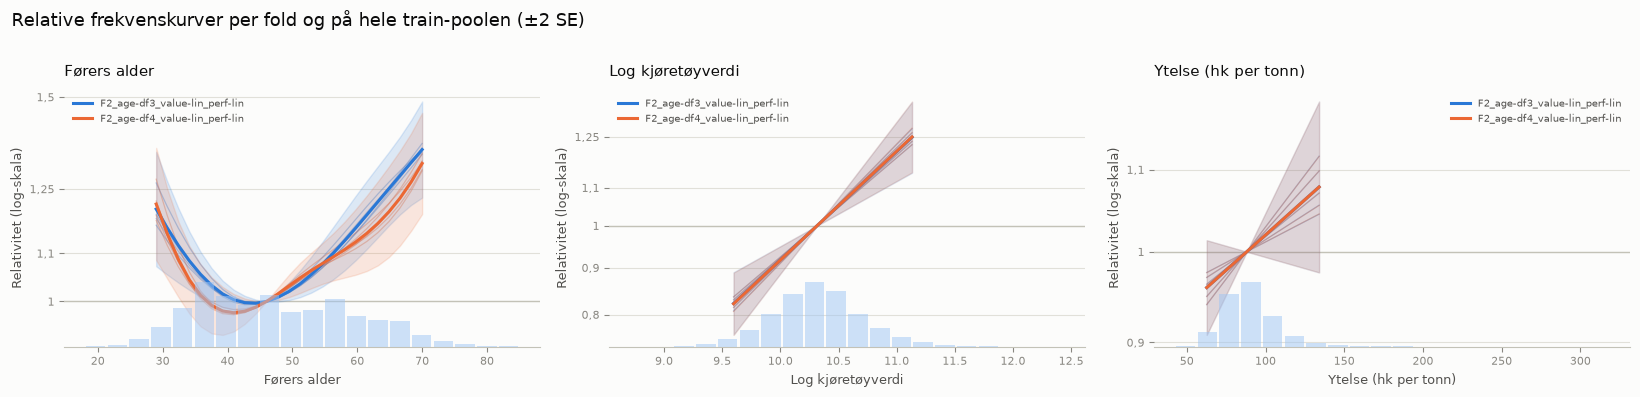

train_min  train_max  \
model_id                      feature                                          
F2_age-df3_value-lin_perf-lin driver_age                   18.000     85.000   
                              log_vehicle_value             8.706     12.442   
                              performance_hp_per_tonne     42.391    318.471   
F2_age-df4_value-lin_perf-lin driver_age                   18.000     85.000   
                              log_vehicle_value             8.706     12.442   
                              performance_hp_per_tonne     42.391    318.471   

                                                        relative_at_min  \
model_id                      feature                                     
F2_age-df3_value-lin_perf-lin driver_age                          1.607   
                              log_vehicle_value                   0.646   
                              performance_hp_per_tonne            0.928   
F2_age-df4_value-lin_perf-lin driver_age                          2.010   
                              log_vehicle_value                   0.644   
                              performance_hp_per_tonne            0.928   

                                                        relative_at_max  \
model_id                      feature                                     
F2_age-df3_value-lin_perf-lin driver_age                          1.693   
                              log_vehicle_value                   1.783   
                              performance_hp_per_tonne            1.458   
F2_age-df4_value-lin_perf-lin driver_age                          2.109   
                              log_vehicle_value                   1.787   
                              performance_hp_per_tonne            1.458   

                                                        fold_min_lav  \
model_id                      feature                                  
F2_age-df3_value-lin_perf-lin driver_age                       1.479   
                              log_vehicle_value                0.619   
                              performance_hp_per_tonne         0.899   
F2_age-df4_value-lin_perf-lin driver_age                       1.798   
                              log_vehicle_value                0.617   
                              performance_hp_per_tonne         0.899   

                                                        fold_min_høy  \
model_id                      feature                                  
F2_age-df3_value-lin_perf-lin driver_age                       1.812   
                              log_vehicle_value                0.683   
                              performance_hp_per_tonne         0.958   
F2_age-df4_value-lin_perf-lin driver_age                       2.360   
                              log_vehicle_value                0.683   
                              performance_hp_per_tonne         0.957   

                                                        fold_maks_lav  \
model_id                      feature                                   
F2_age-df3_value-lin_perf-lin driver_age                        1.575   
                              log_vehicle_value                 1.691   
                              performance_hp_per_tonne          1.244   
F2_age-df4_value-lin_perf-lin driver_age                        1.906   
                              log_vehicle_value                 1.694   
                              performance_hp_per_tonne          1.246   

                                                        fold_maks_høy  \
model_id                      feature                                   
F2_age-df3_value-lin_perf-lin driver_age                        1.789   
                              log_vehicle_value                 1.884   
                              performance_hp_per_tonne          1.745   
F2_age-df4_value-lin_perf-lin driver_age                        2.246   
                              log_ve

In [17]:
# Plott: valgt form, og beste kandidat når den er en annen (lineære ledd gir rette linjer)
curve_ids = list(dict.fromkeys([form_selection["selected"], form_selection["best"]]))
full_curves = {m: fit_full_curves(frequency_cv[m]["spec"]) for m in curve_ids}
display(
    plot_fold_curves(
        pd.concat(
            [frequency_cv[m]["curves"] for m in curve_ids]
            + [full_curves[m]["curves"] for m in curve_ids],
            ignore_index=True,
        ),
        features=CONTINUOUS_FEATURES,
        support_frame=model_frame,
        feature_labels={
            "driver_age": "Førers alder",
            "log_vehicle_value": "Log kjøretøyverdi",
            "performance_hp_per_tonne": "Ytelse (hk per tonn)",
        },
        title="Relative frekvenskurver per fold og på hele train-poolen (±2 SE)",
    )
)

# Tabell 2: haleprediksjoner, hele train-poolen og spennet over foldene
fold_tails = (
    pd.concat([frequency_cv[m]["tails"] for m in curve_ids])
    .groupby(["model_id", "feature"], sort=False)
    .agg(
        fold_min_lav=("relative_at_min", "min"),
        fold_min_høy=("relative_at_min", "max"),
        fold_maks_lav=("relative_at_max", "min"),
        fold_maks_høy=("relative_at_max", "max"),
        val_utenfor=("n_val_outside", "sum"),
    )
)
tail_table = (
    pd.concat([full_curves[m]["tails"] for m in curve_ids])
    .set_index(["model_id", "feature"])[
        ["train_min", "train_max", "relative_at_min", "relative_at_max"]
    ]
    .join(fold_tails)
)
display(tail_table.round(3))

**Merknad om ytelse:** valgt form har ytelse lineær. Ablasjonen i 3.4 viser at
ytelse ligger svært nær grensen for fjerning (0,1 SE) gitt den lineære formen.
Om ytelse som spline (df=3/4) ville gjort bidraget mer eller mindre tydelig er
ikke testet denne fasen — ablasjonen i 3.4 bruker formene fra 3.3 slik de er
valgt her, og går ikke tilbake og prøver alternative former på de leddene som
testes for fjerning.

### 3.4 Ablasjon (F3)

**Konklusjon og implikasjoner for neste steg**

- Bare to blokker kan fjernes innen 1 SE av F2: **kommunetype** (tap −1,5 SE,
  altså en forbedring; tap i 2/5 folder) og **ytelse** (0,1 SE). Begge testes
  i 3.6.
- Drivstoff ligger 2,2 SE unna (tap i 4/5 folder) og er ikke kandidat for
  sletting. Alder, forretningstype og verdi er tydelig nødvendige (3,4–7,8 SE);
  bruksmiljø (2,3 SE) og betalingsfrekvens (1,5 SE) er mindre sikre, men
  utenfor 1 SE.
- Å fjerne verdi og ytelse samlet koster 2,7 SE. Ytelse er overflødig *gitt*
  verdi, ikke uten informasjon i seg selv.
- Ablasjon er ikke seleksjon; slettingen skjer kontrollert i 3.6.

Ablasjonen svarer på hvor mye valgt F2 taper når én blokk tas ut og resten blir
stående. Hver av de åtte kjerneblokkene fjernes én om gangen. Formene fra 3.3
er låst, men knuter og koeffisienter læres på nytt i hver fold. I tillegg
fjernes verdi + ytelse og de to geografifeltene samlet. Det viser overlapp:
to korrelerte blokker kan hver for seg se overflødige ut og likevel bære
informasjon sammen.

Tapet per fold er $\text{loss}_k = D_{\text{ablasjon},k} - D_{\text{F2},k}$, der
positivt betyr at ablasjonen er dårligere. En blokk er *kandidat for
fjerning* når snittapet ≤ parvis SE (innen 1 SE). Tabellen viser betingede
bidrag, ikke kausale effekter. Ingenting slettes her; det skjer én blokk om
gangen i 3.6.

In [18]:
# Teståret 2024 skal aldri inn i seksjon 3 (B-05)
assert "test" not in frames and set(model_frame["year"]) == set(TRAIN_YEARS)

f2_id = form_selection["selected"]
f2_spec = frequency_cv[f2_id]["spec"]


def drop_blocks(spec, blocks, model_id, stage):
    """Kandidat uten ``blocks``; de gjenværende kontinuerlige leddene beholder formen."""
    columns = {FEATURE_BLOCKS[block]["column"] for block in blocks}
    return build_frequency_candidate(
        model_id,
        stage,
        [block for block in spec["feature_blocks"] if block not in blocks],
        forms={c: form for c, form in spec["forms"].items() if c not in columns},
        parent_id=spec["model_id"],
    )


ablations = {block: [block] for block in CORE_BLOCKS} | {
    "value+performance": ["value", "performance"],
    "circulation+municipality": ["circulation", "municipality"],
}
ablation_rows = []
for label, blocks in ablations.items():
    model_id = "F3_minus-" + "-".join(blocks)
    frequency_cv[model_id] = cross_validate_candidate(
        drop_blocks(f2_spec, blocks, model_id, "F3")
    )
    comparison = compare_models(frequency_cv, f2_id, model_id, "forenkling")
    ablation_rows.append(
        {
            "fjernet_blokk": label,
            "sparte_parametere": f2_spec["n_parameters"]
            - frequency_cv[model_id]["spec"]["n_parameters"],
            "oof_deviance": pooled_oof_deviance(frequency_cv[model_id]),
            # Tap = minus gevinst: positivt betyr at ablasjonen er dårligere enn F2
            "pooled_tap": -comparison["pooled_gain"],
            "snitt_tap": -comparison["mean_gain"],
            "SE_tap": comparison["se_gain"],
            "folder_med_tap": 5 - comparison["folds_improved"],
            "innen_1SE": comparison["passes_1se"],
            "stabilitet": assess_stability(frequency_cv[model_id])[0],
            "note": comparison["note"],
        }
    )
ablation_table = pd.DataFrame(ablation_rows).set_index("fjernet_blokk")
ablation_table.insert(
    6, "tap_per_SE", ablation_table["snitt_tap"] / ablation_table["SE_tap"]
)
removal_candidates = ablation_table.index[ablation_table["innen_1SE"]]
print(
    "Kandidater for fjerning (innen 1 SE av F2, slettes ikke her): "
    + (", ".join(removal_candidates) or "ingen")
)
display(ablation_table.sort_values("snitt_tap"))

Kandidater for fjerning (innen 1 SE av F2, slettes ikke her): performance, municipality


,sparte_parametere,oof_deviance,pooled_tap,snitt_tap,SE_tap,folder_med_tap,tap_per_SE,innen_1SE,stabilitet,note
fjernet_blokk,,,,,,,,,,
municipality,2,1.121648,-0.000159,-0.000160,0.000104,2,-1.539737,True,stabil,NaN
performance,1,1.121829,0.000021,0.000023,0.000189,3,0.119178,True,nær-null,nær-null: municipality_type=IS
fuel,2,1.122659,0.000851,0.000853,0.000392,4,2.174457,False,stabil,NaN
value,1,1.123060,0.001253,0.001254,0.000369,5,3.397043,False,nær-null,nær-null: municipality_type=IS
circulation+municipality,3,1.123161,0.001354,0.001353,0.000813,4,1.664008,False,stabil,NaN
circulation,1,1.123378,0.001571,0.001571,0.000686,4,2.290687,False,stabil,NaN
payment,2,1.123556,0.001748,0.001748,0.001133,4,1.542827,False,nær-null,nær-null: municipality_type=IS
driver,3,1.123872,0.002064,0.002066,0.000265,5,7.787274,False,stabil,NaN
value+performance,2,1.125430,0.003623,0.003635,0.001340,5,2.712865,False,stabil,NaN


### 3.5 Sekundære blokker (F4)

**Konklusjon og implikasjoner for neste steg**

- Ingen sekundær blokk kvalifiserer. Merke gir +0,00036 (SE 0,00046), bare
  3/5 folder og under 1 SE. Seter gir tap (1/5), og kombinasjonen består ikke.
- Merke ligger innen 1 SE av beste, men F2 er enklest og beholdes som fullmodell.
- Merkeinformasjonen er tynn per nivå. Den er bedre egnet for credibility-
  vekting senere enn som faste GLM-relativiteter.

**Modell.** Valgt F2 utvides med en eller to hele kategoriblokker:

$$
\log\lambda_i=\eta^{\text{F2}}_i+\beta_{\text{merke}(i)}+\beta_{\text{seter}(i)},
$$

der $\eta^{\text{F2}}_i$ er den lineære prediktoren fra F2 med låste former.
Merke har 17 beholdte merker pluss OTHER etter B-14 (≥500 eksponeringsår på
hele train-poolen, uten bruk av respons). Setegruppe har nivåene `<5`, `5` og
`>5`. Basisnivået er nivået med mest eksponering (B-24).

*Intuisjon:* merke fanger bilegenskaper som verdi og ytelse ikke dekker, for
eksempel typisk bruk og reparasjonsmønster. Mye av informasjonen kan likevel
overlappe med kjernen. De fire alternativene (ingen, merke, seter, begge)
velges med regelen fra 3.1, med F2 som anker. Tabellen viser også betinget
bidrag: merke gitt seter og seter gitt merke.

**Tabell 1** har én rad per sammenligning, med kandidatens score og valgflagg.
**Tabell 2** viser støtten per nivå: hele train-poolen og minste verdi over de
fem foldtreningene.

In [19]:
secondary_result = secondary_blocks.run_secondary_blocks(
    cross_validate_candidate, frequency_cv, f2_id, f2_spec, model_frame, cv_folds
)
f4_ids = secondary_result["f4_ids"]
display(secondary_result["comparison_table"])  # Tabell 1
display(secondary_result["support_table"])  # Tabell 2

Ingen nær-treff (3/5) i denne sammenligningen.
Beste: F4_brand. Innen 1 SE: F2_age-df3_value-lin_perf-lin, F4_brand.
Valgt: F2_age-df3_value-lin_perf-lin (ankeret er enklest innen 1 SE av beste kandidat)


Poolet_gevinst  Snitt_gevinst  \
Referanse                     Kandidat                                        
F2_age-df3_value-lin_perf-lin F4_brand              0.000358       0.000357   
                              F4_seats             -0.000158      -0.000159   
                              F4_brand-seats        0.000092       0.000090   
F4_seats                      F4_brand-seats        0.000250       0.000249   
F4_brand                      F4_brand-seats       -0.000266      -0.000267   

                                              SE_gevinst  Folder_forbedret  \
Referanse                     Kandidat                                       
F2_age-df3_value-lin_perf-lin F4_brand          0.000462                 3   
                              F4_seats          0.000164                 1   
                              F4_brand-seats    0.000503                 2   
F4_seats                      F4_brand-seats    0.000522                 3   
F4_brand                      F4_brand-seats    0.000126                 1   

                                              Innenfor_1SE  Bestar_B08  \
Referanse                     Kandidat                                   
F2_age-df3_value-lin_perf-lin F4_brand               False       False   
                              F4_seats               False       False   
                              F4_brand-seats         False       False   
F4_seats                      F4_brand-seats         False       False   
F4_brand                      F4_brand-seats         False       False   

                                             merknad  \
Referanse                     Kandidat                 
F2_age-df3_value-lin_perf-lin F4_brand                 
                              F4_seats                 
                              F4_brand-seats           
F4_seats                      F4_brand-seats           
F4_brand                      F4_brand-seats           

                                                                                           note  \
Referanse                     Kandidat                                                            
F2_age-df3_value-lin_perf-lin F4_brand        nær-null: municipality_type=IS, vehicle_brand_...   
                              F4_seats                           nær-null: municipality_type=IS   
                              F4_brand-seats  nær-null: performance_hp_per_tonne, municipali...   
F4_seats                      F4_brand-seats  nær-null: performance_hp_per_tonne, municipali...   
F4_brand                      F4_brand-seats  nær-null: performance_hp_per_tonne, municipali...   

                                              parametere  oof_deviance  \
Referanse                     Kandidat                                   
F2_age-df3_value-lin_perf-lin F4_brand                33      1.121449   
                              F4_seats                18      1.121965   
                              F4_brand-seats          35      1.121715   
F4_seats                      F4_brand-seats          35      1.121715   
F4_brand                      F4_brand-seats          35      1.121715   

                                                oof_d2 stabilitet  i_1SE_sett  \
Referanse                     Kandidat                                          
F2_age-df3_value-lin_perf-lin F4_brand        0.098055   nær-null        True   
                              F4_seats        0.097640   nær-null       False   
                              F4_brand-seats  0.097842   nær-null       False   
F4_seats                      F4_brand-seats  0.097842   nær-null       False   
F4_brand                      F4_brand-seats  0.097842   nær-null       False   

                                              valgt  
Referanse                     Kandidat               
F2_age-df3_value-lin_perf-lin F4_brand        False  
                              F4_seats        False  
                              F4_bra

total_exposure  property_claims  min_fold_total_exposure  \
blokk nivå                                                                   
brand OTHER               4261.1             1133                   3370.8   
      VOLKSWAGEN          3594.5              867                   2838.6   
      AUDI                2827.2              959                   2209.1   
      RENAULT             2631.6              591                   2066.1   
      BMW                 2503.3              843                   1971.3   
      CITROEN             2475.8              632                   1972.9   
      MERCEDES            2419.2              839                   1917.9   
      FORD                2410.3              665                   1904.5   
      PEUGEOT             2403.6              544                   1896.3   
      OPEL                2165.0              516                   1713.9   
      TOYOTA              2156.1              628                   1700.4   
      SEAT                2037.6              541                   1617.6   
      NISSAN              1479.3              277                   1175.7   
      HYUNDAI              937.1              238                    742.2   
      VOLVO                787.8              221                    597.9   
      KIA                  760.0              167                    589.2   
      HONDA                713.3              224                    553.3   
      CHEVROLET            563.3              104                    438.2   
seats 5                  30771.3             8304                  24588.1   
      >5                  4102.8             1060                   3190.7   
      <5                  2252.0              625                   1775.5   

                  min_fold_property_claims  
blokk nivå                                  
brand OTHER                            879  
      VOLKSWAGEN                       683  
      AUDI                             723  
      RENAULT                          457  
      BMW                              616  
      CITROEN                          501  
      MERCEDES                         642  
      FORD                             504  
      PEUGEOT                          426  
      OPEL                             398  
      TOYOTA                           493  
      SEAT                             419  
      NISSAN                           207  
      HYUNDAI                          178  
      VOLVO                            168  
      KIA                              120  
      HONDA                            168  
      CHEVROLET                         76  
seats 5                               6567  
      >5                               805  
      <5                               473

### 3.6 Kontrollert reduksjon (F5) og avsluttende formsjekk

**Konklusjon og implikasjoner for neste steg**

- Reduksjonen sletter **kommunetype** (steg 1) og **ytelse** (steg 2). I steg 3
  kvalifiserer ingen sletting.
- Forslaget **`F5_minus-municipality-performance`** har 13 parametere og OOF D²
  9,79 %. Det er marginalt *bedre* enn fullmodellen F2 (0,00013, SE 0,00021,
  3/5), bedre enn F1 (4/5) og klart bedre enn F0 (5/5).
- **Drivstoff beholdes, nær terskelen.** Slettingen koster 1,12 SE mot gjeldende
  modell, like over grensen. Uten drivstoff blir A/E for bensin 0,91 (støygrense
  ±0,06): modellen *overpredikerer* bensin. Begge kriteriene peker samme vei.
- **Geografi:** kommunetype fjernes fordi den ikke forbedrer OOF-deviance når
  bruksmiljø (urban/rural) er med (Cramér's V 0,11). Rå frekvensforskjeller
  mellom innland og kyst forklares i stor grad av de andre variablene. Dette er
  en prediktiv, ikke kausal, konklusjon.
- **Ytelse** fjernes fordi den overlapper med logverdi (korrelasjon 0,56). Den
  kan testes på nytt i severity-fasen, der kraftige biler kan gi dyrere skader.
- Formsjekk: alder df=4 er best, men innen 1 SE; df=3 beholdes.
- Brukeren godkjente forslaget 2026-09-16, og det bekreftes uendret etter B-29.
  Neste steg: 3.7 tester produktinteraksjoner oppå denne modellen.

Fullmodellen er valgt F4 og holdes **fast** gjennom hele reduksjonen.
Reduksjonen er en begrenset bakoverprosedyre. Produkt og år er beskyttet, og
formene er låst.

1. Fra gjeldende modell fjernes hver valgfri blokk én om gangen.
2. En sletting er *kvalifisert* når den reduserte modellen er gyldig og ligger
   innen parvis 1 SE av **både** gjeldende modell og fullmodellen. Den må også
   være uten `UAVKLART`-stabilitet og uten nytt A/E-flagg. A/E-flagget gjelder
   nivåer eller eksponeringskvintiler av den slettede variabelen med ≥500
   eksponeringsår der $|A/E-1| > 2\sqrt{\hat\phi/\text{forventet}}$ etter
   slettingen, men ikke før. OOF-prediksjoner brukes, og $\hat\phi$ er snittet
   av foldenes Pearson-dispersjon.
3. Blant kvalifiserte slettinger velges lavest pooled deviance. Ved lik score
   (toleranse $10^{-10}$) velges flest sparte parametere og deretter alfabetisk
   blokknavn. Én blokk slettes, og steg 1 gjentas.
4. Reduksjonen stopper når ingen sletting kvalifiserer.

Den doble 1 SE-kontrollen hindrer at mange små tap summeres til et stort tap.
Deretter følger **én** formsjekk med samme rutenett over de gjenværende
kontinuerlige leddene. Den reduserte modellen er anker: økt kompleksitet krever
B-08, og forenkling må ligge innen 1 SE. Resultatet må fortsatt ligge innen
1 SE av fullmodellen. En ytelse-spline markeres `UAVKLART` på grunn av halen
(3.3) og velges ikke automatisk.

**Tabell 1** logger alle forsøkte slettinger per steg. **Tabell 2**
sammenligner forslaget med fullmodellen, F2, F1 og F0. Siste kodecelle setter
`FREQUENCY_ADDITIVE_ID`, som 3.7–3.8 bygger på; frysing krever brukerens godkjenning.

In [20]:
def deletion_ae_flags(cv_results, current_id, reduced_id, block):
    """Nivåer av slettet blokk (≥500 eksponeringsår) utenfor støy etter, men ikke før, sletting."""
    column = FEATURE_BLOCKS[block]["column"]
    frame = model_frame
    if pd.api.types.is_numeric_dtype(frame[column]):
        # Kvintilbøttene tåler ikke manglende verdier; medianen følger imputasjonen (B-09)
        frame = frame.assign(**{column: frame[column].fillna(frame[column].median())})
    outside, tables = {}, {}
    for model_id in (current_id, reduced_id):
        result = cv_results[model_id]
        phi = result["scores"]["pearson_phi"].mean()
        table = build_actual_expected_table(frame, result["oof"], [column])
        table = table[table["exposure"] >= MIN_STABILITY_EXPOSURE].set_index("level")
        table["noise_limit"] = 2 * np.sqrt(phi / table["expected"])
        outside[model_id] = ae_outside_noise(table["claims"], table["expected"], phi)
        tables[model_id] = table
    new_flags = outside[reduced_id] & ~outside[current_id]
    # Tekst per flagg: A/E før → etter sletting, og støygrensen 2·SE etter
    return [
        f"{level}: {tables[current_id].loc[level, 'ae']:.3f}→"
        f"{tables[reduced_id].loc[level, 'ae']:.3f} (±{tables[reduced_id].loc[level, 'noise_limit']:.3f})"
        for level in new_flags.index[new_flags]
    ]


full_id = secondary_result["selection"]["selected"]
current_id, removed, reduction_rows = full_id, [], []
for step in itertools.count(1):
    current_spec = frequency_cv[current_id]["spec"]
    step_rows = []
    for block in current_spec["feature_blocks"]:
        if block in CONTROL_BLOCKS:
            continue
        model_id = "F5_minus-" + "-".join(sorted(removed + [block]))
        frequency_cv[model_id] = cross_validate_candidate(
            drop_blocks(current_spec, [block], model_id, "F5")
        )
        reduced = frequency_cv[model_id]
        vs_current = compare_models(frequency_cv, current_id, model_id, "forenkling")
        vs_full = compare_models(frequency_cv, full_id, model_id, "forenkling")
        stability = assess_stability(reduced)[0] if reduced["valid"] else "ugyldig"
        ae_flags = (
            deletion_ae_flags(frequency_cv, current_id, model_id, block)
            if reduced["valid"]
            else []
        )
        step_rows.append(
            {
                "steg": step,
                "slettet_blokk": block,
                "model_id": model_id,
                "sparte_parametere": current_spec["n_parameters"]
                - reduced["spec"]["n_parameters"],
                "oof_deviance": pooled_oof_deviance(reduced)
                if reduced["valid"]
                else np.nan,
                "snitt_tap_gjeldende": -vs_current["mean_gain"],
                "SE_gjeldende": vs_current["se_gain"],
                "innen_1SE_gjeldende": vs_current["passes_1se"],
                "snitt_tap_full": -vs_full["mean_gain"],
                "SE_full": vs_full["se_gain"],
                "innen_1SE_full": vs_full["passes_1se"],
                "nye_AE_flagg": ", ".join(ae_flags),
                "stabilitet": stability,
                "kvalifisert": bool(
                    reduced["valid"]
                    and vs_current["passes_1se"]
                    and vs_full["passes_1se"]
                    and not ae_flags
                    and not stability.startswith("UAVKLART")
                ),
                "slettet": False,
            }
        )
    step_table = pd.DataFrame(step_rows)
    qualified = step_table[step_table["kvalifisert"]]
    if qualified.empty:
        reduction_rows.append(step_table)
        break
    # Lavest deviance; ved lik score flest sparte parametere, deretter alfabetisk blokk
    ties = qualified[
        qualified["oof_deviance"] <= qualified["oof_deviance"].min() + SCORE_TOLERANCE
    ]
    chosen = ties.sort_values(
        ["sparte_parametere", "slettet_blokk"], ascending=[False, True]
    ).index[0]
    step_table.loc[chosen, "slettet"] = True
    reduction_rows.append(step_table)
    removed.append(step_table.loc[chosen, "slettet_blokk"])
    current_id = step_table.loc[chosen, "model_id"]
    print(f"Steg {step}: sletter {removed[-1]} → {current_id}")

reduced_id = current_id
print(
    f"Reduksjon ferdig: {reduced_id} (slettet: {', '.join(removed) or 'ingen'}; "
    f"fullmodell {full_id})"
)
display(pd.concat(reduction_rows).set_index(["steg", "slettet_blokk"]))

Steg 1: sletter municipality → F5_minus-municipality


Steg 2: sletter performance → F5_minus-municipality-performance


Reduksjon ferdig: F5_minus-municipality-performance (slettet: municipality, performance; fullmodell F2_age-df3_value-lin_perf-lin)


model_id  \
steg slettet_blokk                                                  
1    driver                                       F5_minus-driver   
     value                                         F5_minus-value   
     performance                             F5_minus-performance   
     fuel                                           F5_minus-fuel   
     circulation                             F5_minus-circulation   
     municipality                           F5_minus-municipality   
     payment                                     F5_minus-payment   
     business                                   F5_minus-business   
2    driver                          F5_minus-driver-municipality   
     value                            F5_minus-municipality-value   
     performance                F5_minus-municipality-performance   
     fuel                              F5_minus-fuel-municipality   
     circulation                F5_minus-circulation-municipality   
     payment                        F5_minus-municipality-payment   
     business                      F5_minus-business-municipality   
3    driver              F5_minus-driver-municipality-performance   
     value                F5_minus-municipality-performance-value   
     fuel                  F5_minus-fuel-municipality-performance   
     circulation    F5_minus-circulation-municipality-performance   
     payment            F5_minus-municipality-payment-performance   
     business          F5_minus-business-municipality-performance   

                    sparte_parametere  oof_deviance  snitt_tap_gjeldende  \
steg slettet_blokk                                                         
1    driver                         3      1.123872             0.002066   
     value                          1      1.123060             0.001254   
     performance                    1      1.121829             0.000023   
     fuel                           2      1.122659             0.000853   
     circulation                    1      1.123378             0.001571   
     municipality                   2      1.121648            -0.000160   
     payment                        2      1.123556             0.001748   
     business                       1      1.126456             0.004651   
2    driver                         3      1.123663             0.002017   
     value                          1      1.122911             0.001264   
     performance                    1      1.121675             0.000028   
     fuel                           2      1.122515             0.000869   
     circulation                    1      1.123161             0.001512   
     payment                        2      1.123387             0.001739   
     business                       1      1.126267             0.004621   
3    driver                         3      1.123761             0.002087   
     value                          1      1.125283             0.003619   
     fuel                           2      1.122303             0.000628   
     circulation                    1      1.123193             0.001517   
     payment                        2      1.123400             0.001725   
     business                       1      1.126322             0.004649   

                    SE_gjeldende  innen_1SE_gjeldende  snitt_tap_full  \
steg slettet_blokk                                                      
1    driver             0.000265                False        0.002066   
     value              0.000369                False        0.001254   
     performance        0.000189                 True        0.000023   
     fuel               0.000392                False        0.000853   
     circulation        0.000686                False        0.001571   
     municipality       0.000104                 True       -0.000160   
     payment            0.001133                False        0.001748   
     business           0.000771                False        0.

In [21]:
# Avsluttende formsjekk: samme formrutenett over de gjenværende kontinuerlige leddene
reduced_spec = frequency_cv[reduced_id]["spec"]
check_features = [f for f in CONTINUOUS_FEATURES if f in reduced_spec["forms"]]
form_check_ids = []
for combination in itertools.product(CONTINUOUS_FORMS, repeat=len(check_features)):
    forms = dict(zip(check_features, combination))
    if forms == reduced_spec["forms"]:
        form_check_ids.append(reduced_id)  # formen fra F5 er ankeret
        continue
    model_id = form_model_id("F5form", forms)
    frequency_cv[model_id] = cross_validate_candidate(
        build_frequency_candidate(
            model_id,
            "F5",
            reduced_spec["feature_blocks"],
            forms=forms,
            parent_id=reduced_id,
        )
    )
    form_check_ids.append(model_id)

form_check = select_from_candidate_set(frequency_cv, form_check_ids, reduced_id)
report_near_misses(form_check["anchor_comparisons"])
print(
    f"Formsjekk – beste: {form_check['best']}. "
    f"Innen 1 SE: {', '.join(form_check['within_1se'])}."
)
print(f"Formsjekk – valg: {form_check['selected']} ({form_check['reason']})")

proposal_id = reduced_id
form_choice = form_check["selected"]
if form_choice not in (None, reduced_id):
    choice_forms = frequency_cv[form_choice]["spec"]["forms"]
    if choice_forms.get("performance_hp_per_tonne", "linear") != "linear":
        print(
            f"UAVKLART: formsjekken peker på ytelse-spline ({form_choice}). Halen (3.3) "
            f"må vurderes manuelt; forslaget beholder {reduced_id}."
        )
    elif not compare_models(frequency_cv, full_id, form_choice, "forenkling")[
        "passes_1se"
    ]:
        print(
            f"{form_choice} ligger ikke innen 1 SE av fullmodellen; {reduced_id} beholdes."
        )
    else:
        proposal_id = form_choice
print(f"Forslag til additiv frekvensmodell (ikke frosset): {proposal_id}")

# Tabell 2: forslaget mot fullmodellen, F2, F1 og F0 (og F5 før formsjekk hvis ulik)
reference_ids = [
    m
    for m in dict.fromkeys([full_id, f2_id, "F1", "F0", reduced_id])
    if m != proposal_id
]
proposal_parameters = frequency_cv[proposal_id]["spec"]["n_parameters"]
final_comparisons = pd.DataFrame(
    [
        compare_models(
            frequency_cv,
            m,
            proposal_id,
            "oppgradering"
            if proposal_parameters > frequency_cv[m]["spec"]["n_parameters"]
            else "forenkling",
        )
        for m in reference_ids
    ]
)
display(
    build_candidate_table(frequency_cv, [proposal_id] + reference_ids)[
        ["stage", "former", "parametere", "oof_deviance", "oof_d2", "oof_balanse"]
    ].join(
        format_comparison_table(final_comparisons)
        .drop(columns=["Kandidat", "near_miss_3of5", "stability"])
        .set_index("Referanse")
    )
)

Ingen nær-treff (3/5) i denne sammenligningen.
Formsjekk – beste: F5form_age-df4_value-lin. Innen 1 SE: F5_minus-municipality-performance, F5form_age-df4_value-lin.
Formsjekk – valg: F5_minus-municipality-performance (ankeret er enklest innen 1 SE av beste kandidat)
Forslag til additiv frekvensmodell (ikke frosset): F5_minus-municipality-performance


,stage,former,parametere,oof_deviance,oof_d2,oof_balanse,Retning,Poolet_gevinst,Snitt_gevinst,SE_gevinst,Folder_forbedret,Innenfor_1SE,Bestar_B08,merknad,note
model_id,,,,,,,,,,,,,,,
F5_minus-municipality-performance,F5,"alder=df3, verdi=lineær",13,1.121675,0.097874,0.999642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F2_age-df3_value-lin_perf-lin,F2,"alder=df3, verdi=lineær, ytelse=lineær",16,1.121807,0.097767,0.999654,forenkling,0.000132,0.000131,0.000213,3.0,True,None,,None
F1,F1,"alder=lineær, verdi=lineær, ytelse=lineær",14,1.123230,0.096624,0.999704,forenkling,0.001554,0.001556,0.000536,4.0,True,None,,None
F0,F0,,3,1.137254,0.085344,0.999856,oppgradering,0.015579,0.015594,0.002658,5.0,True,True,,None


In [22]:
# Additiv frekvensmodell etter 3.6, frosset etter brukerens godkjenning 2026-09-16
# (bekreftet uendret etter B-29). Alt etter 3.6 bygger på denne variabelen.
FREQUENCY_ADDITIVE_ID = proposal_id
assert FREQUENCY_ADDITIVE_ID == "F5_minus-municipality-performance"
print(f"Frosset additiv frekvensmodell: {FREQUENCY_ADDITIVE_ID}")

Frosset additiv frekvensmodell: F5_minus-municipality-performance


### 3.7 To avgrensede interaksjoner (F6, B-28)

**Konklusjon og implikasjoner for neste steg**

- Støtteporten består med god margin: svakeste COMP_N-celle har 1 442
  eksponeringsår og 927 skader.
- **I1, COMP_N × alder, kvalifiserer:** gevinst 0,00034 (SE 0,00012, 2,8 SE),
  bedre i 5/5 folder, stabil. COMP_N-helningen er −0,006 per år (SE 0,003):
  alderskurven er flatere for COMP_N enn for COMP_E. Fra 30 til 70 år utgjør
  det ca. 20 % relativ forskjell mellom produktene.
- I2, COMP_N × logverdi, kvalifiserer ikke (3/5 folder, gevinst ≈ 0).
  Kombinasjonen estimeres derfor ikke.
- **Valgt etter B-08: `F6_I1_product-x-age`** (14 parametere, OOF D² 9,81 %).
  Valget ble senere **overstyrt i 3.9 (B-30)**: gevinsten er bare 1,1
  cluster-SE, og modellen taper i tidsfolden.
- **Endret etter B-29:** med CC i populasjonen ble I1 forkastet. CC-helningen
  hadde svært lite data (SE 0,011) og druknet gevinsten. COMP_N-helningen er
  praktisk talt den samme i begge kjøringene.
- **Manuell tolkning:** den absolutte gevinsten er liten. Flatere alderskurve for
  COMP_N (uten egenandel) kan skyldes meldemønster (små skader meldes uavhengig
  av alder) eller hvem som velger COMP_N. Effekten er prediktiv, ikke kausal.

To utfordrere legges oppå den additive modellen fra 3.6. Etter B-29 er COMP_N
eneste produktkontrast, så hver utfordrer gir én **lineær kontrasthelning** for
COMP_N, mens hovedkurvene er uendret:

$$
\log \lambda_i = \eta^{\text{add}}_i
+ \gamma_{\text{N}}\,\mathbb{1}\{\text{COMP\_N}\}_i\,(x_i - c),
$$

der $x$ er førers alder (I1) eller logverdi (I2), og $c$ er det
eksponeringsvektede snittet av $x$ i treningsfolden. COMP_E er basis og følger
den felles kurven. COMP_N får kurven vippet med $\gamma_{\text{N}}$ per enhet $x$.
Hver interaksjon gir altså én parameter.

*Intuisjon:* egenandel og meldemønster er ulikt mellom produktene. Hvor mye
alder eller bilverdi betyr for skadefrekvensen, kan derfor avhenge av produkt.
Bare en lineær helning er tillatt; ingen produktspesifikke splines og ingen søk.

**Støtteport, før fitting.** Grensene er felles eksponeringsvektede tredeler
av $x$ i hver foldtrening. I alle fem foldtreningene kreves ≥50 eksponeringsår
per produkt × tredel og ≥20 skader per produkt; i praksis er COMP_N bindende. Skader per celle rapporteres
uten terskel. Svikter porten, utgår interaksjonen.

**Valg.**

1. I1 og I2 sammenlignes hver for seg med den additive modellen etter B-08,
   med stabilitet på de nye leddene.
2. Bare hvis begge består, estimeres kombinasjonen. Den må bestå B-08 mot
   begge enkeltmodellene.
3. Ellers velges enkeltmodellen med lavest pooled deviance. Ligger de to innen
   parvis 1 SE av hverandre, foretrekkes I1.

**Tabell 1** viser støtten per celle. **Tabell 2** sammenligner modellene.
**Plottet** viser de produktvise kurvene på området begge produkter støtter.

In [23]:
# Teståret 2024 skal aldri inn i seksjon 3 (B-05)
assert "test" not in frames and set(model_frame["year"]) == set(TRAIN_YEARS)
additive_spec = frequency_cv[FREQUENCY_ADDITIVE_ID]["spec"]

support_table, support_passes = interactions.test_interaction_support(
    model_frame, cv_folds, prepare_design_frame, additive_spec
)
display(support_table)  # Tabell 1

I1 (driver_age): tredelgrenser q1 41.000–41.000, q2 53.000–53.000 over foldene; støtteport bestått


I2 (log_vehicle_value): tredelgrenser q1 10.160–10.163, q2 10.457–10.464 over foldene; støtteport bestått


min_fold_eksponering  min_fold_skader  \
interaksjon produkt tredel                                          
I1          COMP_E  T1                    8991.4             1489   
                    T2                    7555.1             1293   
                    T3                    7968.9             1628   
            COMP_N  T1                    1790.4             1207   
                    T2                    1442.2              927   
                    T3                    1730.7             1247   
I2          COMP_E  T1                    8259.4             1240   
                    T2                    8239.1             1419   
                    T3                    8054.2             1722   
            COMP_N  T1                    1587.4              970   
                    T2                    1614.3             1110   
                    T3                    1742.4             1279   

                            maks_fold_skader  min_fold_skader_produkt  
interaksjon produkt tredel                                             
I1          COMP_E  T1                  1595                     4456  
                    T2                  1336                     4456  
                    T3                  1651                     4456  
            COMP_N  T1                  1336                     3409  
                    T2                   992                     3409  
                    T3                  1291                     3409  
I2          COMP_E  T1                  1320                     4456  
                    T2                  1481                     4456  
                    T3                  1794                     4456  
            COMP_N  T1                  1052                     3409  
                    T2                  1179                     3409  
                    T3                  1404                     3409

In [24]:
f6_result = interactions.select_interactions(
    cross_validate_candidate,
    frequency_cv,
    FREQUENCY_ADDITIVE_ID,
    additive_spec,
    support_passes,
    pooled_oof_deviance,
)
f6_ids, f6_id = f6_result["f6_ids"], f6_result["selected_id"]
display(f6_result["comparison_table"])  # Tabell 2

Ingen nær-treff (3/5) i denne sammenligningen.
Valgt etter 3.7: F6_I1_product-x-age (eneste interaksjon som består B-08)


Poolet_gevinst  \
Referanse                         Kandidat                                
F5_minus-municipality-performance F6_I1_product-x-age          0.000336   
                                  F6_I2_product-x-value        0.000002   

                                                         Snitt_gevinst  \
Referanse                         Kandidat                               
F5_minus-municipality-performance F6_I1_product-x-age         0.000335   
                                  F6_I2_product-x-value       0.000002   

                                                         SE_gevinst  \
Referanse                         Kandidat                            
F5_minus-municipality-performance F6_I1_product-x-age      0.000119   
                                  F6_I2_product-x-value    0.000105   

                                                         Folder_forbedret  \
Referanse                         Kandidat                                  
F5_minus-municipality-performance F6_I1_product-x-age                   5   
                                  F6_I2_product-x-value                 3   

                                                         Innenfor_1SE  \
Referanse                         Kandidat                              
F5_minus-municipality-performance F6_I1_product-x-age            True   
                                  F6_I2_product-x-value         False   

                                                         Bestar_B08 merknad  \
Referanse                         Kandidat                                    
F5_minus-municipality-performance F6_I1_product-x-age          True           
                                  F6_I2_product-x-value       False           

                                                        stability  note  \
Referanse                         Kandidat                                
F5_minus-municipality-performance F6_I1_product-x-age      stabil  None   
                                  F6_I2_product-x-value    stabil  None   

                                                         parametere  \
Referanse                         Kandidat                            
F5_minus-municipality-performance F6_I1_product-x-age            14   
                                  F6_I2_product-x-value          14   

                                                         oof_deviance  \
Referanse                         Kandidat                              
F5_minus-municipality-performance F6_I1_product-x-age        1.121339   
                                  F6_I2_product-x-value      1.121673   

                                                           oof_d2  \
Referanse                         Kandidat                          
F5_minus-municipality-performance F6_I1_product-x-age    0.098144   
                                  F6_I2_product-x-value  0.097875   

                                                                                        kontrasthelninger  
Referanse                         Kandidat                                                                 
F5_minus-municipality-performance F6_I1_product-x-age           comp_n_slope_driver_age: -0.0059 (0.0026)  
                                  F6_I2_product-x-value  comp_n_slope_log_vehicle_value: -0.0893 (0.0826)

driver_age: felles støttet område 30.00–70.00


log_vehicle_value: felles støttet område 9.60–11.12


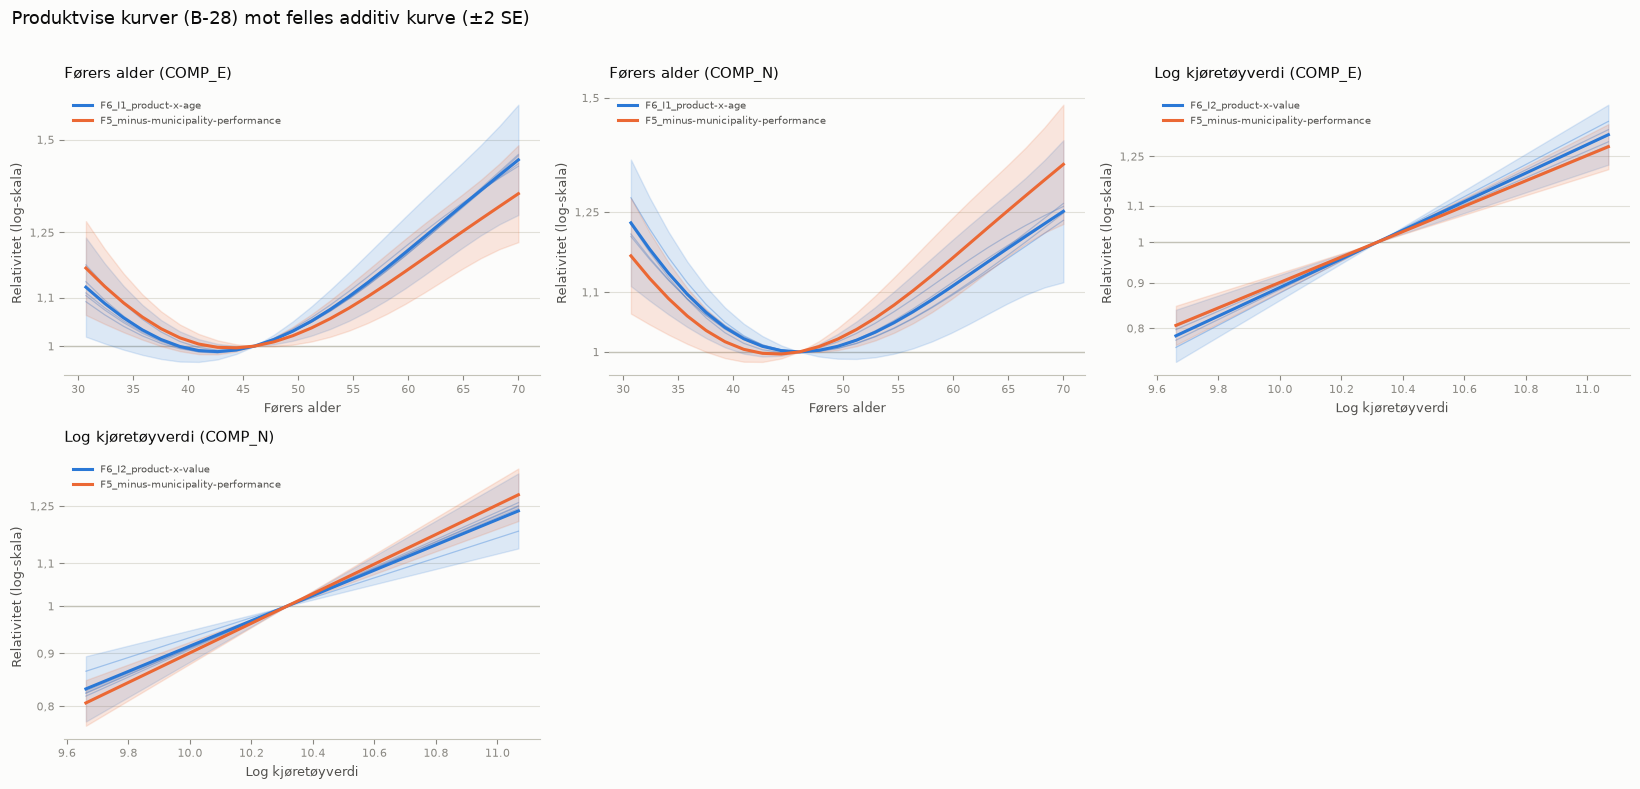

In [25]:
figure = interactions.plot_interaction_curves(
    frequency_cv, f6_ids, additive_spec, model_frame
)
if figure is not None:
    display(figure)

### 3.8 Fordelingsutfordrer: negativ binomisk NB2 (F7)

**Konklusjon og implikasjoner for neste steg**

- Tydelig overspredning: $\hat\alpha$ ≈ 4,8–5,0 i alle folder (ca. 34 SE fra
  randen), og Pearson $\hat\phi$ ≈ 2,0 under Poisson mot ≈ 1,2 under NB2.
- NB2 forbedrer likevel ikke prediktiv deviance: −0,00022 (SE 0,00038), bedre i
  bare 2/5 folder. **Poisson beholdes** (B-23); ingen beslutning endres.
- Relativitetene endres ikke materielt. Største utslag er COMP_N-nivået
  (3,67 → 3,50, 1,5 SE).
- NB2 har OOF-balanse 0,987 mot 1,000 for Poisson (ca. 1,3 % for lavt nivå).
  Det er et argument mot NB2 som middelverdimodell her.
- **Implikasjon:** overspredningen håndteres i inferensen, med cluster-robuste
  standardfeil på `insured_id` (B-21) og Pearson-dispersjon rapportert separat.
  Den håndteres ikke i middelverdimodellen. B-08-valget etter 3.8 er
  `F6_I1_product-x-age`; endelig frekvensmodell settes i 3.9 (B-30).

NB2 beholder middelverdistrukturen fra 3.7, men tillater mer varians enn
Poisson:

$$
E[N_i \mid x_i, e_i] = m_i = e_i \exp(\eta_i), \qquad
\operatorname{Var}(N_i \mid x_i, e_i) = m_i + \alpha\, m_i^2 .
$$

Med $\alpha = 0$ er modellen Poisson. NB2 estimeres som en egen **antallsgren**
med `smf.negativebinomial(..., loglike_method='nb2', exposure=...)` på heltallet
`property_claims`. Den bruker samme formel, samme folder og samme imputasjon og
avledede kolonner som Poisson (B-26-unntaket). Startverdiene er Poisson-fitten
i samme fold med $\alpha = 0{,}1$. Optimeringen er låst til BFGS med maks 1000
iterasjoner.

Predikert antall deles på eksponeringen og scores som rate med samme
eksponeringsvektede Poisson-deviance. Da er scoren direkte sammenlignbar med
Poisson.

*Intuisjon:* estimeringsligningen er
$\sum_i \frac{N_i - m_i}{1 + \alpha m_i}\, x_i = 0$. Rader med høyt forventet
antall får mindre vekt enn i Poisson. NB2 endrer derfor først og fremst
variansen, standardfeilene og vektingen. Middelverdien endres bare gjennom den
nye vektingen, og det er ikke gitt at den blir bedre.

**Forhåndslåste regler.**

- $\alpha$ er på randen i en fold når $\hat\alpha < 2\cdot SE(\hat\alpha)$. Er
  flertallet av foldene på randen, beholdes Poisson.
- Ved konvergenssvikt beholdes Poisson.
- Ellers må NB2 slå Poisson etter B-08 på OOF-deviance (B-23).

**Tabell 1** viser $\hat\alpha$ ± SE, Pearson-$\hat\phi$ og deviance per fold.
**Tabell 2** viser om relativitetene og standardfeilene endres. En endring
regnes som materiell når $|\Delta \log \text{relativitet}| > 2\cdot SE$
(Poisson, φ̂-skalert).

In [26]:
def nb2_fit_view(result):
    """NB2-fitten med Poisson-grensesnittet som foldkontrollene og kurvene bruker (uten alpha).

    Kovariansen er NB2-modellens egen: variansen er allerede modellert, så den
    skaleres ikke med Pearson-φ̂ (``pearson_chi2 = df_resid`` gir φ̂ = 1).
    """
    beta = result.params.index.drop("alpha")
    return SimpleNamespace(
        model=result.model,
        params=result.params[beta],
        converged=bool(result.mle_retvals["converged"]),
        cov_params=lambda: result.cov_params().loc[beta, beta],
        pearson_chi2=1.0,
        df_resid=1.0,
        scale=1.0,
    )


def cross_validate_nb2(poisson_spec, model_id, folds=None, data=model_frame):
    """NB2 som antallsmodell på samme folder, scoret som rate (samme format som Poisson-CV)."""
    folds = cv_folds if folds is None else folds
    spec = poisson_spec | {
        "model_id": model_id,
        "name": model_id,
        "stage": "F7",
        "parent_id": poisson_spec["model_id"],
        "family": "nb2",
        "n_parameters": poisson_spec["n_parameters"] + 1,  # + alpha
    }
    count_formula = "property_claims ~" + spec["formula"].split("~", 1)[1]
    response, weight = spec["y"], spec["weight"]
    oof = pd.Series(np.nan, index=data.index, name=model_id)
    rows, params, standard_errors, errors, extras = [], [], [], [], {}

    def score(part, prediction):
        return mean_tweedie_deviance(
            part[response], prediction, sample_weight=part[weight], power=1
        )

    for fold in folds:
        # Samme radutvalg og rekkefølge som cross_validate_glm, så parvise sammenligninger går opp
        train = data.loc[data.index.intersection(fold["train_index"])]
        val = data.loc[data.index.intersection(fold["val_index"])]
        try:
            (train_design, val_design), derived_state = prepare_fold_frames(
                spec, train, [train, val], prepare_design_frame
            )
            poisson_fit = fit_glm(spec, train_design)  # startverdier fra samme fold
            result = smf.negativebinomial(
                count_formula,
                data=train_design,
                exposure=train_design[weight].to_numpy(),
                loglike_method="nb2",
            ).fit(
                start_params=np.append(poisson_fit.params, 0.1),
                method="bfgs",
                maxiter=1000,
                disp=0,
            )
        except (ValueError, np.linalg.LinAlgError, PatsyError, RuntimeError) as error:
            errors.append(f"{fold['fold']}: {error}")
            continue

        def predict_rate(frame):
            counts = np.asarray(
                result.predict(frame, exposure=frame[weight].to_numpy())
            )
            rate = np.asarray(result.predict(frame, exposure=np.ones(len(frame))))
            # Forventet antall = eksponering × predikert rate, også på nye rader
            assert np.allclose(counts, frame[weight].to_numpy() * rate, rtol=1e-10)
            return pd.Series(rate, index=frame.index)

        train_prediction, val_prediction = (
            predict_rate(train_design),
            predict_rate(val_design),
        )
        view = nb2_fit_view(result)
        problems, rank = check_fold_fit(
            spec, view, train_design, val_design, train_prediction, val_prediction
        )
        alpha, alpha_se = result.params["alpha"], result.bse["alpha"]
        if not (np.isfinite(alpha) and np.isfinite(alpha_se)):
            problems.append("ikke-endelig alpha")
        errors.extend(f"{fold['fold']}: {problem}" for problem in problems)
        if not problems:
            oof.loc[val.index] = val_prediction
        # Pearson-φ̂ med NB2-variansen på antallsskala (≈ 1 når variansformen passer)
        expected = train_design[weight] * train_prediction
        pearson_phi = (
            (train_design["property_claims"] - expected) ** 2
            / (expected + alpha * expected**2)
        ).sum() / (len(train_design) - len(result.params))
        rows.append(
            {
                "model": model_id,
                "fold": fold["fold"],
                "n_train": len(train),
                "n_val": len(val),
                "train_weight": train[weight].sum(),
                "val_weight": val[weight].sum(),
                "train_deviance": score(train, train_prediction),
                "val_deviance": score(val, val_prediction),
                "val_null_deviance": score(
                    val,
                    np.full(
                        len(val), np.average(train[response], weights=train[weight])
                    ),
                ),
                "val_actual": (val[response] * val[weight]).sum(),
                "val_predicted": (val_prediction * val[weight]).sum(),
                "val_balance": (val_prediction * val[weight]).sum()
                / (val[response] * val[weight]).sum(),
                "rank": rank,
                "n_params": len(result.params),
                "converged": view.converged,
                "pearson_phi": pearson_phi,
                "alpha": alpha,
                "alpha_se": alpha_se,
            }
        )
        params.append(result.params.rename(fold["fold"]))
        standard_errors.append(result.bse.rename(fold["fold"]))
        if not problems:
            hook_output = frequency_curve_hook(
                spec, fold["fold"], view, train_design, val_design, derived_state
            )
            for key, frame in hook_output.items():
                extras.setdefault(key, []).append(frame)

    scores = pd.DataFrame(rows)
    if len(scores):
        scores["val_d2"] = 1 - scores["val_deviance"] / scores["val_null_deviance"]
    return {
        "spec": spec,
        "oof": oof,
        "scores": scores,
        "params": pd.concat(params, axis=1) if params else pd.DataFrame(),
        "param_se": pd.concat(standard_errors, axis=1)
        if standard_errors
        else pd.DataFrame(),
        "support": pd.DataFrame(),
        **{key: pd.concat(frames, ignore_index=True) for key, frames in extras.items()},
        "valid": not errors and len(rows) == len(folds),
        "error": "; ".join(errors) or None,
    }


poisson_id = f6_id
nb2_id = "F7_nb2_" + poisson_id
frequency_cv[nb2_id] = cross_validate_nb2(frequency_cv[poisson_id]["spec"], nb2_id)
poisson_result, nb2_result = frequency_cv[poisson_id], frequency_cv[nb2_id]

# Tabell 1: alpha, dispersjon og deviance per fold
poisson_scores = poisson_result["scores"].set_index("fold")
nb2_scores = nb2_result["scores"].set_index("fold")
alpha_table = pd.DataFrame(
    {
        "alpha": nb2_scores["alpha"],
        "SE_alpha": nb2_scores["alpha_se"],
        "alpha_per_SE": nb2_scores["alpha"] / nb2_scores["alpha_se"],
        "på_randen": nb2_scores["alpha"] < 2 * nb2_scores["alpha_se"],
        "konvergert": nb2_scores["converged"],
        "phi_poisson": poisson_scores["pearson_phi"],
        "phi_nb2": nb2_scores["pearson_phi"],
        "deviance_poisson": poisson_scores["val_deviance"],
        "deviance_nb2": nb2_scores["val_deviance"],
    }
).assign(gevinst_nb2=lambda t: t["deviance_poisson"] - t["deviance_nb2"])
display(alpha_table)

nb2_comparison = compare_models(frequency_cv, poisson_id, nb2_id)
report_near_misses(pd.DataFrame([nb2_comparison]))
boundary_folds = int(alpha_table["på_randen"].sum())
if not nb2_result["valid"]:
    f7_id, f7_reason = (
        poisson_id,
        f"NB2 er ugyldig ({nb2_result['error']}); Poisson beholdes",
    )
elif boundary_folds > len(cv_folds) / 2:
    f7_id, f7_reason = (
        poisson_id,
        f"alpha på randen i {boundary_folds}/5 folder; Poisson beholdes",
    )
elif not nb2_comparison["passes_b08"]:
    f7_id, f7_reason = poisson_id, "NB2 slår ikke Poisson etter B-08; Poisson beholdes"
else:
    f7_id, f7_reason = (
        nb2_id,
        "NB2 slår Poisson etter B-08 (forslag, krever godkjenning)",
    )
print(
    build_candidate_table(frequency_cv, [poisson_id, nb2_id])[
        ["parametere", "oof_deviance", "oof_d2", "oof_balanse"]
    ].to_string()
)
print(
    f"NB2 mot Poisson: poolet gevinst {nb2_comparison['pooled_gain']:.6f}, "
    f"snitt {nb2_comparison['mean_gain']:.6f}, SE {nb2_comparison['se_gain']:.6f}, "
    f"bedre i {nb2_comparison['folds_improved']}/5 folder, B-08 {nb2_comparison['passes_b08']}"
)
print(f"Stabilitet NB2 (alle blokker): {assess_stability(nb2_result)[0]}")
print(f"Valgt etter 3.8: {f7_id} ({f7_reason})")

# Tabell 2: relativiteter og SE, snitt over foldene; splinekurver som største avvik på gridet
effects = [
    p
    for p in poisson_result["params"].index
    if p != "Intercept" and not p.startswith("cr(")
]
poisson_log = poisson_result["params"].loc[effects].mean(axis=1)
nb2_log = nb2_result["params"].loc[effects].mean(axis=1)
relativity_table = pd.DataFrame(
    {
        "relativitet_poisson": np.exp(poisson_log),
        "relativitet_nb2": np.exp(nb2_log),
        "endring_log": nb2_log - poisson_log,
        "SE_poisson": poisson_result["param_se"].loc[effects].mean(axis=1),
        "SE_nb2": nb2_result["param_se"].loc[effects].mean(axis=1),
    }
)
for feature, form in poisson_result["spec"]["forms"].items():
    if form == "linear":
        continue
    # Fold-snittkurver per produkt/gridpunkt; største avvik i log-relativitet
    curves = {
        name: result["curves"]
        .query("feature == @feature")
        .assign(log_relative=lambda c: np.log(c["relative"]))
        .groupby(["product", "x"])[["log_relative", "se_log"]]
        .mean()
        for name, result in (("poisson", poisson_result), ("nb2", nb2_result))
    }
    difference = curves["nb2"]["log_relative"] - curves["poisson"]["log_relative"]
    worst = difference.abs().idxmax()
    relativity_table.loc[
        f"{feature} (kurve {worst[0]}, største avvik ved x={worst[1]:.2f})"
    ] = {
        "relativitet_poisson": np.exp(curves["poisson"].loc[worst, "log_relative"]),
        "relativitet_nb2": np.exp(curves["nb2"].loc[worst, "log_relative"]),
        "endring_log": difference.loc[worst],
        "SE_poisson": curves["poisson"].loc[worst, "se_log"],
        "SE_nb2": curves["nb2"].loc[worst, "se_log"],
    }
relativity_table = relativity_table.assign(
    endring_per_SE=lambda t: t["endring_log"].abs() / t["SE_poisson"],
    materiell=lambda t: t["endring_log"].abs() > 2 * t["SE_poisson"],
    SE_forhold=lambda t: t["SE_nb2"] / t["SE_poisson"],
)
display(relativity_table.round(4))

,alpha,SE_alpha,alpha_per_SE,på_randen,konvergert,phi_poisson,phi_nb2,deviance_poisson,deviance_nb2,gevinst_nb2
fold,,,,,,,,,,
gruppe_1,4.924980,0.146035,33.724736,False,True,2.075588,1.242554,1.109253,1.108984,0.000269
gruppe_2,5.023410,0.148313,33.870300,False,True,2.027270,1.187064,1.099216,1.098217,0.000999
gruppe_3,4.832407,0.143806,33.603647,False,True,2.064561,1.243282,1.123987,1.125116,-0.001129
gruppe_4,4.999538,0.148529,33.660405,False,True,2.083246,1.246985,1.132192,1.132888,-0.000696
gruppe_5,4.824723,0.144065,33.489957,False,True,1.953265,1.142327,1.142007,1.142565,-0.000558


Ingen nær-treff (3/5) i denne sammenligningen.
                            parametere  oof_deviance    oof_d2  oof_balanse
model_id                                                                   
F6_I1_product-x-age                 14      1.121339  0.098144     0.999632
F7_nb2_F6_I1_product-x-age          15      1.121561  0.097966     0.986486
NB2 mot Poisson: poolet gevinst -0.000222, snitt -0.000223, SE 0.000380, bedre i 2/5 folder, B-08 False
Stabilitet NB2 (alle blokker): stabil
Valgt etter 3.8: F6_I1_product-x-age (NB2 slår ikke Poisson etter B-08; Poisson beholdes)


,relativitet_poisson,relativitet_nb2,endring_log,SE_poisson,SE_nb2,endring_per_SE,materiell,SE_forhold
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",3.6734,3.4984,-0.0488,0.0326,0.0381,1.4993,False,1.1711
"C(year, Treatment(2023))[T.2022]",0.9206,0.9133,-0.0079,0.0389,0.0393,0.2040,False,1.0094
"C(fuel_type, Treatment('D'))[T.G]",0.8643,0.8627,-0.0018,0.0413,0.0426,0.0441,False,1.0321
"C(fuel_type, Treatment('D'))[T.MISSING]",1.0256,1.0176,-0.0078,0.1707,0.1864,0.0457,False,1.0921
"C(circulation_area, Treatment('U'))[T.R]",0.8439,0.8329,-0.0131,0.0346,0.0355,0.3775,False,1.0261
"C(payment_frequency, Treatment('A'))[T.Q]",1.4443,1.4430,-0.0009,0.0638,0.0732,0.0139,False,1.1466
"C(payment_frequency, Treatment('A'))[T.S]",1.1016,1.0721,-0.0272,0.0488,0.0516,0.5566,False,1.0559
"C(business_type, Treatment('NB'))[T.P]",1.3555,1.3706,0.0111,0.0368,0.0409,0.3014,False,1.1120
log_vehicle_value,1.3898,1.4060,0.0116,0.0435,0.0467,0.2663,False,1.0742
comp_n_slope_driver_age,0.9941,0.9936,-0.0005,0.0026,0.0032,0.1987,False,1.1942


In [27]:
# Valget etter B-08 i 3.7–3.8 (brukergodkjent 2026-09-16), beholdt som dokumentasjon.
# Endelig frekvensmodell fryses i 3.9 etter B-07-vurderingen (B-30).
B08_SELECTED_ID = f7_id
assert B08_SELECTED_ID == "F6_I1_product-x-age"
print(f"Valgt etter B-08 (3.7–3.8): {B08_SELECTED_ID}")

Valgt etter B-08 (3.7–3.8): F6_I1_product-x-age


### 3.9 Diagnostikk, tidsrobusthet og endelig modellvalg (B-30)

**Konklusjon og implikasjoner for neste steg**

- **Endelig modell er F5 (B-30).** F6_I1 slår F5 med 0,00034 i gruppe-CV, men det
  er bare 1,1 cluster-SE; fold-SE ga 2,8 SE og var for optimistisk. Fra 2022 til
  2023 er F6_I1 *dårligere* (−0,0022, cluster-SE 0,0010, z −2,2).
- Tapet sitter i COMP_N over 53 år (A/E 1,49 med F6_I1 mot 1,30 med F5). Aldersfallet
  i COMP_N er ×0,86 per 10 år i 2022, men bare ×0,97 i 2023, så samspillet fanger et
  årsspesifikt mønster.
- Resten av stigen holder fremover i tid: F1 slår F0 og F5 slår F1, både i
  gruppe-CV og i tidsfolden (z 2,2–6,8 med cluster-SE).
- **Kontroll med cluster-SE:** ingen beslutning i 3.3–3.7 snur. Drivstoff er
  nærmest terskelen: å fjerne den koster 1,1 fold-SE og 1,3 cluster-SE mot
  gjeldende modell.
- **NB2 på F5** forbedrer ikke deviance (2/5 folder) og gir dårligere
  OOF-balanse (0,987). Poisson beholdes med cluster-robust inferens (B-23).
- **Kalibrering:** A/E er 1,00 totalt og innen støy på alle modellvariablene og
  prediksjonsdesilene. Kommunetype (fjernet) er også innen støy.
  - Avvik finnes bare utenfor modellen: bonus B/N (A/E ≈ 1,2; ikke kvalifisert,
    B-13) og fem merker (A/E 0,73–1,22).
  - Dette endrer ingen modell. Merkesignalet sendes videre (3.12).
- **Nivådrift:** tidsbalansen er ca. 0,86 for alle finalister. Det observerte
  nivået i 2023 er høyere enn 2022 gir, særlig i COMP_N (A/E 1,16–1,33 med F5).
  Driften er felles for modellene og ikke et argument for andre variabler, men den
  er et åpent punkt for nivåsetting.
- **UAVKLART, skadetellingen (B-03):**
  - Overspredningen er tydelig (Pearson-φ̂ ≈ 2,0; Cameron–Trivedi z 15–29).
  - Rootogrammet viser pukkelen ved N = 4–5: 418 og 335 poliseår mot forventet
    33 og 6.
  - I COMP_N er det i tillegg 25 % for mange nuller og bare 35 % av forventede
    poliseår med én skade.
  - En jevn risikoblanding gir ikke dette mønsteret. Registrering der én hendelse
    blir flere skader er en *hypotese*.
  - Datakilden (artikkelen bak datasettet) er sjekket manuelt. `property_claims`
    teller skader «related to material and personal damages» for COMP_E/COMP_N.
    Artikkelen sier ikke om skader telles per hendelse, per skadelinje eller per
    utbetaling, og nevner ingen avkapping eller støy. Årsaken er derfor
    fortsatt ukjent.
  - Konsekvensen er kvantifisert i 3.11, sensitivitet (5).

Diagnostikken gjelder finalistene F0, F1, additiv F5 og F6_I1 (valgt etter
B-08 i 3.7–3.8). Tidsfolden og kontrollen med cluster-SE er grunnlaget for
B-07-vurderingen (B-30), som fryser endelig frekvensmodell midt i seksjonen.
Kalibrering og fordeling vises deretter for den frosne modellen. Ser noe
systematisk og materielt ut, rapporteres det til manuell vurdering etter B-07.

**Tidsfold (B-06, B-25).** Hver finalist estimeres på 2022 og predikerer 2023,
uten årsledd:

$$
\log\lambda_i=\beta_0+\beta_{p(i)}+\sum_j f_j(x_{ij})
\;\big[+\gamma_{\text{N}}\,\mathbb{1}\{\text{COMP\_N}\}_i(x_{i,\text{alder}}-c)\big],
\qquad i\in 2022 .
$$

Imputasjon, splineknuter og senteret $c$ læres på 2022. Tidsbasisen er F0 uten
år, altså bare produkt (samme modell som i 2.9). *Intuisjon:* 2023 har høyere
frekvens enn 2022, og det nivåskiftet kan ingen modell uten år treffe. Balansen
viser skiftet, mens gevinsten mot tidsbasisen viser om segmenteringen holder
seg fremover i tid.

**Parvis usikkerhet med cluster-SE.** Mot forelderen i kjeden
F0 → F1 → F5 → F6_I1 er gevinsten

$$
\Delta=\frac{\sum_i e_i\,(d_i^{\text{forelder}}-d_i^{\text{barn}})}{\sum_i e_i},
\qquad
\widehat{\text{SE}}(\Delta)=\frac{\sqrt{\tfrac{C}{C-1}\sum_g (G_g-\Delta W_g)^2}}{\sum_g W_g},
$$

der $d_i$ er Poisson-enhetsdeviance på raten, og $G_g$ og $W_g$ er summen av
$e_i(d_i^{\text{forelder}}-d_i^{\text{barn}})$ og $e_i$ i cluster $g$ (`insured_id`, $C$ clustere).
$\Delta$ er nøyaktig differansen mellom scorene. Formelen brukes både i
tidsfolden (rader i 2023) og på OOF-prediksjonene fra gruppe-CV (alle rader),
der den tar med at samme polise kan ha to år. Fold-SE (sd av fem
foldgevinster/$\sqrt5$) ser ikke denne korrelasjonen direkte. SE-en behandler
de estimerte modellene som faste og fanger bare radstøyen. Tapet eller
gevinsten for F6_I1 mot F5 i tid dekomponeres per produkt × alderstredel
(grenser lært på 2022, som støtteporten i 3.7), og COMP_N-helningen estimeres
per år med cluster-SE. Til slutt kontrolleres beslutningene nær terskel i
3.3–3.7 med cluster-SE i stedet for fold-SE. Kontrollen er dokumentasjon;
reglene endres ikke i ettertid.

**Kalibrering.** $A/E=\sum N_i/\sum e_i\hat\lambda_i$ på OOF-prediksjonene til
den frosne modellen, per forhåndsdefinert segment. Merk at `oof_balanse`/`tid_balanse` i
tabell 1 er motsatt brøk (predikert/observert). Et nivå flagges når
$|A/E-1|>2\sqrt{\hat\phi/\text{forventet}}$, med $\hat\phi$ som foldsnittet av
Pearson-dispersjonen. Grensen ignorerer korrelasjon innen `insured_id` og er
derfor noe for trang. Bonus er bare diagnostisk segment (B-13); kommunetype,
ytelse, merke og seter er fjernet eller ikke kvalifisert.

**Fordeling.** Pearson-dispersjon på antall,
$\hat\phi=\sum_i (N_i-\hat m_i)^2/\hat m_i\,/\,(n-p)$ med $\hat m_i=e_i\hat\lambda_i$.
Cameron–Trivedi bruker hjelperegresjonen

$$
\frac{(N_i-\hat m_i)^2-N_i}{\hat m_i}=\alpha\,\hat m_i+u_i ,
$$

der $\alpha=0$ er Poisson og $\alpha>0$ er NB2-lignende overspredning.
Regresjonen får cluster-robust SE på `insured_id`, fordi samme polise kan
ha to år. Konstantleddversjonen ($\alpha$ alene) tester NB1-formen. Rootogrammet
viser forventet antall poliseår med $N=k$ som $\sum_i P(N_i=k\mid \hat m_i)$ med
radens egen eksponering og OOF-prediksjon, for 0–9 og samlet 10+.

**Utfallskondisjonert diagnostikk** (A/E per observert skadeantall, status og
eksponeringsbøtte) utelates. Den er ikke ordinær kalibrering på informasjon
kjent ved prising og får ikke plass innenfor to tabeller og to plott.
Kanselleringsmønsteret belyses i stedet av sensitiviteten uten kansellerte i 3.11.

**Tabell 1:** score, foldscorer og tidsfold per finalist, med parvis gevinst
mot forelder i gruppe-CV og tid, begge med cluster-SE. **Tabell 2 og
plott 1:** A/E per segment for den frosne modellen. **Plott 2:** rootogram.

In [28]:
# Teståret 2024 skal aldri inn i seksjon 3 (B-05)
assert "test" not in frames and set(model_frame["year"]) == set(TRAIN_YEARS)
FINALIST_IDS = ["F0", "F1", FREQUENCY_ADDITIVE_ID, B08_SELECTED_ID]

# 3.12: pooled score fra samlede OOF-prediksjoner = eksponeringsvektet snitt av
# foldscorene, og én OOF-prediksjon per rad, for hver finalist
for model_id in FINALIST_IDS:
    result = frequency_cv[model_id]
    assert result["valid"] and result["oof"].notna().all()
    assert np.isclose(
        pooled_oof_deviance(result),
        np.average(
            result["scores"]["val_deviance"], weights=result["scores"]["val_weight"]
        ),
        rtol=1e-12,
    )


def without_year(model_id):
    """Finalisten uten C(year) til tidsfolden (B-25); blokker, former og avledede ledd beholdes."""
    spec = frequency_cv[model_id]["spec"]
    return build_frequency_candidate(
        f"{model_id}_uten_år",
        "tid",
        [block for block in spec["feature_blocks"] if block != "year"],
        forms=spec["forms"],
        parent_id=model_id,
        derived=spec["derived"],
    )


def oof_cluster_gain(baseline_id, candidate_id):
    """Pooled OOF-gevinst i gruppe-CV (basis − kandidat) med cluster-robust SE på insured_id."""
    return paired_deviance_gain(
        model_frame["claim_frequency"],
        model_frame["total_exposure"],
        frequency_cv[baseline_id]["oof"].loc[model_frame.index],
        frequency_cv[candidate_id]["oof"].loc[model_frame.index],
        model_frame["insured_id"],
    )


# Tidsfolden 2022 → 2023: alt læres på 2022 inne i cross_validate_glm
time_results = {
    model_id: cross_validate_glm(without_year(model_id), model_frame, time_fold)
    for model_id in FINALIST_IDS
}
for model_id, result in time_results.items():
    if not result["valid"]:
        print(f"UAVKLART: tidsfolden er ugyldig for {model_id}: {result['error']}")
# F0 uten år er samme modell som tidsbasisen i 2.9 og skal gi samme score
assert np.isclose(
    time_results["F0"]["scores"]["val_deviance"].iloc[0],
    time_fold_scores.set_index("model").loc["frequency_policy_type", "val_deviance"],
    rtol=1e-10,
)

finalist_comparisons = pd.DataFrame(
    [compare_models(frequency_cv, "F0", model_id) for model_id in FINALIST_IDS[1:]]
)
report_near_misses(finalist_comparisons)

# Parvis gevinst mot forelderen i kjeden, cluster-robust SE på insured_id:
# i gruppe-CV (OOF, alle rader, med fold-SE ved siden av) og i tidsfolden (2023)
FINALIST_PARENTS = dict(zip(FINALIST_IDS[1:], FINALIST_IDS[:-1]))
time_val = model_frame.loc[time_fold[0]["val_index"]]
time_predictions = {m: r["oof"].loc[time_val.index] for m, r in time_results.items()}


def parent_gain_row(parent, child):
    """Gevinst mot forelder: OOF med fold- og cluster-SE, tidsfolden med cluster-SE."""
    oof = oof_cluster_gain(parent, child)
    in_time = paired_deviance_gain(
        time_val["claim_frequency"],
        time_val["total_exposure"],
        time_predictions[parent],
        time_predictions[child],
        time_val["insured_id"],
    )
    return {
        "oof_gevinst_mot_forelder": oof["gevinst"],
        "SE_fold_forelder": compare_models(frequency_cv, parent, child)["se_gain"],
        "SE_cluster_oof": oof["SE_cluster"],
        "tid_gevinst_mot_forelder": in_time["gevinst"],
        "SE_cluster_tid": in_time["SE_cluster"],
        "z_tid": in_time["z"],
    }


parent_gains = pd.DataFrame(
    {
        child: parent_gain_row(parent, child)
        for child, parent in FINALIST_PARENTS.items()
    }
).T
finalist_table = build_finalist_table(
    frequency_cv, FINALIST_IDS, finalist_comparisons, time_results, "F0"
).join(parent_gains.drop(columns="z_tid"))
# Kontroll: parvise gevinster er nøyaktig differansen mellom scorene (OOF og tid)
for child, parent in FINALIST_PARENTS.items():
    for gain_column, score_column in [
        ("oof_gevinst_mot_forelder", "oof_deviance"),
        ("tid_gevinst_mot_forelder", "tid_deviance"),
    ]:
        assert np.isclose(
            finalist_table.loc[child, gain_column],
            finalist_table.loc[parent, score_column]
            - finalist_table.loc[child, score_column],
            rtol=1e-6,
        )
display(finalist_table)

Ingen nær-treff (3/5) i denne sammenligningen.


,parametere,oof_deviance,oof_d2,oof_balanse,train_oof_gap,gevinst_mot_basis,SE_gevinst,folder_bedre,dev_gruppe_1,dev_gruppe_2,dev_gruppe_3,dev_gruppe_4,dev_gruppe_5,pearson_phi,tid_deviance,tid_d2,tid_balanse,tid_gevinst_mot_tidsbasis,tid_gevinst_andel_av_oof,oof_gevinst_mot_forelder,SE_fold_forelder,SE_cluster_oof,tid_gevinst_mot_forelder,SE_cluster_tid
model_id,,,,,,,,,,,,,,,,,,,,,,,,
F0,3,1.137254,0.085344,0.999856,-0.000615,NaN,NaN,NaN,1.117353,1.116194,1.136822,1.156419,1.159508,2.048922,1.188702,0.089295,0.821898,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
F1,14,1.123230,0.096624,0.999704,-0.002349,0.014024,0.002480,5.0,1.109432,1.102252,1.126289,1.133910,1.144226,2.043255,1.172960,0.101355,0.856178,0.015741,1.122439,0.014024,0.002480,0.002053,0.015741,0.002574
F5_minus-municipality-performance,13,1.121675,0.097874,0.999642,-0.002092,0.015579,0.002658,5.0,1.109686,1.099318,1.124023,1.132607,1.142696,2.042577,1.170223,0.103452,0.856789,0.018479,1.186167,0.001554,0.000536,0.000706,0.002738,0.001012
F6_I1_product-x-age,14,1.121339,0.098144,0.999632,-0.002099,0.015914,0.002677,5.0,1.109253,1.099216,1.123987,1.132192,1.142007,2.040786,1.172421,0.101768,0.854910,0.016280,1.022982,0.000336,0.000119,0.000307,-0.002199,0.001003


In [29]:
# Dekomponering av tidsgevinsten F6_I1 − F5 per produkt × alderstredel.
# Tredelsgrensene læres på 2022 med samme regel som støtteporten i 3.7.
train_2022 = model_frame.loc[time_fold[0]["train_index"]]
age_2022 = prepare_design_frame(train_2022, train_2022, ["driver_age"])
order = np.argsort(age_2022["driver_age"].to_numpy(), kind="stable")
cumulative = np.cumsum(age_2022["total_exposure"].to_numpy()[order])
q1, q2 = age_2022["driver_age"].to_numpy()[order][
    np.searchsorted(cumulative / cumulative[-1], [1 / 3, 2 / 3])
]
age_tertile = pd.cut(
    prepare_design_frame(train_2022, time_val, ["driver_age"])["driver_age"],
    [-np.inf, q1, q2, np.inf],
    labels=[f"≤{q1:.0f} år", f"{q1:.0f}–{q2:.0f} år", f">{q2:.0f} år"],
)
time_cells = decompose_paired_gain(
    time_val,
    [time_val["policy_type"], age_tertile],
    "claim_frequency",
    "total_exposure",
    {
        "F5": time_predictions[FREQUENCY_ADDITIVE_ID],
        "F6_I1": time_predictions[B08_SELECTED_ID],
    },
)
gain = parent_gains.loc[B08_SELECTED_ID]
print(
    f"Tid 2023, F6_I1 mot F5: gevinst {gain['tid_gevinst_mot_forelder']:.5f} (cluster-SE "
    f"{gain['SE_cluster_tid']:.5f}, z {gain['z_tid']:.2f}). Bidrag per produkt × "
    "alderstredel (summerer til gevinsten; A/E = observert/forventet):"
)
for (product, tertile), row in time_cells.iterrows():
    print(
        f"  {product} {tertile}: bidrag {row['bidrag']:+.5f}, {row['eksponering']:.0f} "
        f"eksp.-år, {row['skader']:.0f} skader, A/E F5 {row['AE_F5']:.3f}, "
        f"F6_I1 {row['AE_F6_I1']:.3f}"
    )

# COMP_N-helningen (uten år) estimert per år og på hele poolen, cluster-SE (ikke φ-skalert)
time_spec = without_year(B08_SELECTED_ID)
slope_name = time_spec["derived"][0]["terms"][0]
for label, rows in [
    ("2022", model_frame["year"].eq(2022)),
    ("2023", model_frame["year"].eq(2023)),
    ("hele poolen", model_frame["year"].notna()),
]:
    subset = model_frame.loc[rows]
    (design,), state = prepare_fold_frames(
        time_spec, subset, [subset], prepare_design_frame
    )
    fit = fit_glm(
        time_spec, design, cluster_groups=pd.factorize(design["insured_id"])[0]
    )
    print(
        f"COMP_N-helning {label}: {fit.params[slope_name]:.4f} (SE "
        f"{fit.bse[slope_name]:.4f}), ×{np.exp(10 * fit.params[slope_name]):.3f} per "
        f"+10 år, senter c {state[time_spec['derived'][0]['name']]:.1f} år"
    )
del design, fit, subset

Tid 2023, F6_I1 mot F5: gevinst -0.00220 (cluster-SE 0.00100, z -2.19). Bidrag per produkt × alderstredel (summerer til gevinsten; A/E = observert/forventet):
  COMP_E ≤40 år: bidrag -0.00037, 6780 eksp.-år, 1212 skader, A/E F5 1.006, F6_I1 1.089
  COMP_E 40–53 år: bidrag -0.00009, 7162 eksp.-år, 1265 skader, A/E F5 1.084, F6_I1 1.091
  COMP_E >53 år: bidrag +0.00108, 6919 eksp.-år, 1492 skader, A/E F5 1.202, F6_I1 1.099
  COMP_N ≤40 år: bidrag +0.00097, 1317 eksp.-år, 921 skader, A/E F5 1.161, F6_I1 1.051
  COMP_N 40–53 år: bidrag -0.00009, 1425 eksp.-år, 1059 skader, A/E F5 1.325, F6_I1 1.319
  COMP_N >53 år: bidrag -0.00370, 1510 eksp.-år, 1214 skader, A/E F5 1.304, F6_I1 1.494


COMP_N-helning 2022: -0.0149 (SE 0.0048), ×0.862 per +10 år, senter c 47.0 år


COMP_N-helning 2023: -0.0029 (SE 0.0031), ×0.972 per +10 år, senter c 48.0 år


COMP_N-helning hele poolen: -0.0059 (SE 0.0027), ×0.943 per +10 år, senter c 47.7 år


In [30]:
# Kontroll (B-30): beslutninger nær terskel i 3.3–3.7 med cluster-SE i stedet for
# fold-SE, på de samme OOF-prediksjonene. Dokumentasjon; reglene endres ikke i ettertid.
def within_cluster_se(baseline_id, candidate_id):
    """Forenklingsregelen med cluster-SE: pooled tap ≤ cluster-SE av tapet."""
    gain = oof_cluster_gain(baseline_id, candidate_id)
    return bool(-gain["gevinst"] <= gain["SE_cluster"])


def check_rule(label, baseline_id, candidate_id, direction):
    """Skriver fold- og cluster-versjonen av regelen for ett par; True når de er enige."""
    fold = compare_models(frequency_cv, baseline_id, candidate_id, direction)
    cluster = oof_cluster_gain(baseline_id, candidate_id)
    if direction == "forenkling":
        rule, passes_fold = "innen 1 SE", fold["passes_1se"]
        passes_cluster = bool(-cluster["gevinst"] <= cluster["SE_cluster"])
    else:
        rule, passes_fold = "B-08", fold["passes_b08"]
        passes_cluster = bool(
            cluster["gevinst"] > cluster["SE_cluster"]
            and fold["folds_improved"] >= 4
            and stability_passes(fold["stability"])
        )
    print(
        f"{label}: gevinst {cluster['gevinst']:+.6f}, fold-SE {fold['se_gain']:.6f}, "
        f"cluster-SE {cluster['SE_cluster']:.6f} ({cluster['gevinst'] / cluster['SE_cluster']:+.2f} SE), "
        f"{fold['folds_improved']}/5 folder; {rule}: fold {passes_fold}, cluster {passes_cluster}"
        + ("" if passes_fold == passes_cluster else "  <- SNUR")
    )
    return passes_fold == passes_cluster


agreements = []
# 3.3 og 3.6: enkleste modell innen 1 cluster-SE av beste (samme tie-break som i regelen)
for label, selection in [
    ("3.3 formvalg", form_selection),
    ("3.6 formsjekk", form_check),
]:
    usable = selection["table"].loc[selection["table"]["usable"]]
    within = [
        m
        for m in usable.index
        if m == selection["best"] or within_cluster_se(selection["best"], m)
    ]
    simplest = min(
        within,
        key=lambda m: (usable.loc[m, "n_parameters"], usable.loc[m, "df_order"], m),
    )
    agreements.append(
        set(within) == set(selection["within_1se"])
        and simplest == selection["selected"]
    )
    print(
        f"{label}: innen 1 SE av {selection['best']}: fold {len(selection['within_1se'])}, "
        f"cluster {len(within)} modeller; enklest med cluster-SE {simplest}, valgt "
        f"{selection['selected']}" + ("" if agreements[-1] else "  <- SNUR")
    )
# Formsjekkens beste må være en annen modell enn F5, ellers er det ingen oppgradering å kontrollere
assert form_check["best"] != reduced_id
agreements += [
    check_rule("3.3 valgt form mot beste", form_selection["best"], f2_id, "forenkling"),
    check_rule("3.3 F2 mot F1", "F1", f2_id, "oppgradering"),
    check_rule("3.5 F4_brand mot F2", f2_id, f4_ids["brand"], "oppgradering"),
    check_rule(
        "3.6 formsjekk beste (alder df4) mot F5",
        reduced_id,
        form_check["best"],
        "oppgradering",
    ),
]

# 3.6 reduksjon: samme kvalifisering og slettingsrekkefølge, 1 cluster-SE mot gjeldende og full
step_current = full_id
for step, part in pd.concat(reduction_rows, ignore_index=True).groupby("steg"):
    qualified_cluster = part[
        [
            frequency_cv[r.model_id]["valid"]
            and not r.nye_AE_flagg
            and not r.stabilitet.startswith("UAVKLART")
            and within_cluster_se(step_current, r.model_id)
            and within_cluster_se(full_id, r.model_id)
            for r in part.itertuples()
        ]
    ].sort_values(
        ["oof_deviance", "sparte_parametere", "slettet_blokk"],
        ascending=[True, False, True],
    )
    deleted_fold = part.loc[part["slettet"], "slettet_blokk"].tolist()
    deleted_cluster = qualified_cluster["slettet_blokk"].tolist()[:1]
    agreements.append(deleted_fold == deleted_cluster)
    print(
        f"3.6 reduksjon steg {step}: kvalifisert fold {part.loc[part['kvalifisert'], 'slettet_blokk'].tolist()}, "
        f"cluster {qualified_cluster['slettet_blokk'].tolist()}; sletter fold {deleted_fold}, "
        f"cluster {deleted_cluster}" + ("" if agreements[-1] else "  <- SNUR")
    )
    if (
        not deleted_fold
    ):  # siste steg: tap for gjenværende blokker mot gjeldende og full
        for r in part.sort_values("oof_deviance").itertuples():
            current_gain = oof_cluster_gain(step_current, r.model_id)
            full_gain = oof_cluster_gain(full_id, r.model_id)
            print(
                f"  uten {r.slettet_blokk}: tap mot gjeldende {-current_gain['gevinst']:.6f} "
                f"(fold-SE {r.SE_gjeldende:.6f}, cluster-SE {current_gain['SE_cluster']:.6f}), "
                f"mot full {-full_gain['gevinst']:.6f} (fold-SE {r.SE_full:.6f}, "
                f"cluster-SE {full_gain['SE_cluster']:.6f})"
            )
    else:
        step_current = part.loc[part["slettet"], "model_id"].iloc[0]
agreements.append(
    check_rule(
        "3.7 F6_I1 mot F5", FREQUENCY_ADDITIVE_ID, B08_SELECTED_ID, "oppgradering"
    )
)
print(
    "Ingen beslutning i 3.3–3.7 snur med cluster-SE."
    if all(agreements)
    else "UAVKLART: minst én beslutning snur med cluster-SE; vurderes manuelt (reglene endres ikke)."
)

3.3 formvalg: innen 1 SE av F2_age-df4_value-lin_perf-lin: fold 6, cluster 6 modeller; enklest med cluster-SE F2_age-df3_value-lin_perf-lin, valgt F2_age-df3_value-lin_perf-lin


3.6 formsjekk: innen 1 SE av F5form_age-df4_value-lin: fold 2, cluster 2 modeller; enklest med cluster-SE F5_minus-municipality-performance, valgt F5_minus-municipality-performance
3.3 valgt form mot beste: gevinst -0.000101, fold-SE 0.000115, cluster-SE 0.000203 (-0.50 SE), 2/5 folder; innen 1 SE: fold True, cluster True
3.3 F2 mot F1: gevinst +0.001422, fold-SE 0.000434, cluster-SE 0.000653 (+2.18 SE), 4/5 folder; B-08: fold True, cluster True
3.5 F4_brand mot F2: gevinst +0.000358, fold-SE 0.000462, cluster-SE 0.000824 (+0.43 SE), 3/5 folder; B-08: fold False, cluster False


3.6 formsjekk beste (alder df4) mot F5: gevinst +0.000101, fold-SE 0.000114, cluster-SE 0.000203 (+0.50 SE), 3/5 folder; B-08: fold False, cluster False


3.6 reduksjon steg 1: kvalifisert fold ['performance', 'municipality'], cluster ['municipality', 'performance']; sletter fold ['municipality'], cluster ['municipality']
3.6 reduksjon steg 2: kvalifisert fold ['performance'], cluster ['performance']; sletter fold ['performance'], cluster ['performance']
3.6 reduksjon steg 3: kvalifisert fold [], cluster []; sletter fold [], cluster []
  uten fuel: tap mot gjeldende 0.000628 (fold-SE 0.000560, cluster-SE 0.000487), mot full 0.000496 (fold-SE 0.000444, cluster-SE 0.000549)
  uten circulation: tap mot gjeldende 0.001518 (fold-SE 0.000718, cluster-SE 0.000667), mot full 0.001386 (fold-SE 0.000811, cluster-SE 0.000705)
  uten payment: tap mot gjeldende 0.001725 (fold-SE 0.001135, cluster-SE 0.000796), mot full 0.001593 (fold-SE 0.001130, cluster-SE 0.000835)
  uten driver: tap mot gjeldende 0.002086 (fold-SE 0.000257, cluster-SE 0.000786), mot full 0.001953 (fold-SE 0.000272, cluster-SE 0.000824)
  uten value: tap mot gjeldende 0.003608 (fol

#### B-07-vurdering (B-30)

B-08 valgte F6_I1 i 3.7. B-07 tillater overstyring når forhåndsdefinert tids-
eller stabilitetsdiagnostikk viser en dokumentert, materiell og systematisk
svakhet som konkurrenten tydelig reduserer. Brukeren besluttet 2026-09-16 å
overstyre til additiv F5 på dette grunnlaget (tallene er skrevet ut over):

- **Liten gevinst i gruppe-CV.** F6_I1 mot F5 gir +0,00034 i OOF-deviance,
  2,8 fold-SE og bedre i 5/5 folder. Med cluster-SE på `insured_id` er
  gevinsten bare 1,1 SE, så B-08 passeres med knapp margin.
- **Tap fremover i tid.** Trent på 2022 og validert på 2023 taper F6_I1 mot F5
  med −0,00220 (cluster-SE 0,00100, −2,2 SE). Mot F1 beholder F6_I1 bare
  +0,00054 av F5s +0,00274.
- **Helningen er ikke stabil over år.** COMP_N-helningen er −0,0149
  (SE 0,0048, ×0,86 per +10 år) på 2022 og −0,0029 (SE 0,0031, ×0,97) på 2023.
- **Tapet er konsentrert.** Dekomponeringen legger tapet i COMP_N over øvre
  alderstredel (−0,0037), der A/E i 2023 går fra 1,30 (F5) til 1,49 (F6_I1).
- **Diagnostikk med forbehold (N ≥ 4).** Uten de 622 poliseårene med minst fire
  skader i 2023 (2,2 % av eksponeringen) er F6_I1 mot F5 +0,00045 (SE 0,00056)
  i tid. Utvalget er betinget på utfallet (F1 mot F0 blir da også negativ i
  tid), så dette er bare en indikasjon på at helningen påvirkes av pukkelen
  ved N = 4–5 (B-03). Det er ikke bevis og inngår ikke i notebookens beregninger.

**Beslutning:** F5 er frekvensmodellen, og F6_I1 forkastes som instabil
utfordrer. Kontrollen over viser at ingen annen beslutning i 3.3–3.7 snur med
cluster-SE. Reglene endres ikke i ettertid, og B-08-valget står som
dokumentasjon i 3.7–3.8. Fordelingsvalget (B-23) prøves på nytt med F5 som
middelverdistruktur, med de samme forhåndslåste reglene som i 3.8.

In [31]:
# B-30: endelig frekvensmodell, overstyrer B-08-valget etter B-07 (brukerbesluttet 2026-09-16).
# Resten av 3.9 og 3.10–3.12 bygger på denne variabelen.
FREQUENCY_MODEL_ID = FREQUENCY_ADDITIVE_ID
assert FREQUENCY_MODEL_ID == "F5_minus-municipality-performance"
print(
    f"Frosset frekvensmodell (B-30): {FREQUENCY_MODEL_ID}. Overstyrer B-08-valget "
    f"{B08_SELECTED_ID} etter B-07."
)
final_result = frequency_cv[FREQUENCY_MODEL_ID]

# B-23 på F5: NB2 med F5s middelverdistruktur og samme regler som i 3.8
nb2_final_id = "F7_nb2_" + FREQUENCY_MODEL_ID
frequency_cv[nb2_final_id] = cross_validate_nb2(final_result["spec"], nb2_final_id)
nb2_final = frequency_cv[nb2_final_id]
nb2_alpha = nb2_final["scores"]["alpha"]
nb2_boundary_folds = int((nb2_alpha < 2 * nb2_final["scores"]["alpha_se"]).sum())
nb2_final_comparison = compare_models(frequency_cv, FREQUENCY_MODEL_ID, nb2_final_id)
nb2_final_cluster = oof_cluster_gain(FREQUENCY_MODEL_ID, nb2_final_id)
nb2_balance = build_candidate_table(frequency_cv, [FREQUENCY_MODEL_ID, nb2_final_id])[
    "oof_balanse"
]
nb2_passes = bool(
    nb2_final["valid"]
    and nb2_boundary_folds <= len(cv_folds) / 2
    and nb2_final_comparison["passes_b08"]
)
print(
    f"NB2 mot Poisson på F5: α̂ {nb2_alpha.min():.2f}–{nb2_alpha.max():.2f} "
    f"(på randen i {nb2_boundary_folds}/5 folder), poolet gevinst "
    f"{nb2_final_comparison['pooled_gain']:+.6f}, fold-SE {nb2_final_comparison['se_gain']:.6f}, "
    f"cluster-SE {nb2_final_cluster['SE_cluster']:.6f}, bedre i "
    f"{nb2_final_comparison['folds_improved']}/5 folder, B-08 {nb2_final_comparison['passes_b08']}. "
    f"OOF-balanse NB2 {nb2_balance[nb2_final_id]:.4f}, Poisson {nb2_balance[FREQUENCY_MODEL_ID]:.4f}. "
    f"Stabilitet NB2: {assess_stability(nb2_final)[0]}."
)
assert not nb2_passes, "NB2 slår Poisson på F5: B-23-valget må vurderes manuelt"
print("B-23 på F5: Poisson beholdes med cluster-robust inferens og separat Pearson-φ̂.")

Frosset frekvensmodell (B-30): F5_minus-municipality-performance. Overstyrer B-08-valget F6_I1_product-x-age etter B-07.


NB2 mot Poisson på F5: α̂ 4.83–5.03 (på randen i 0/5 folder), poolet gevinst -0.000203, fold-SE 0.000396, cluster-SE 0.000300, bedre i 2/5 folder, B-08 False. OOF-balanse NB2 0.9870, Poisson 0.9996. Stabilitet NB2: stabil.
B-23 på F5: Poisson beholdes med cluster-robust inferens og separat Pearson-φ̂.


A/E totalt 1.0004; φ̂ (foldsnitt) 2.043. Nivåer utenfor støygrensen med ≥500 eksponeringsår: 7
  bonus_score=B: A/E 1.225 (±0.177), 608 eksponeringsår
  bonus_score=N: A/E 1.195 (±0.181), 745 eksponeringsår
  vehicle_brand_pooled=AUDI: A/E 1.115 (±0.097), 2827 eksponeringsår
  vehicle_brand_pooled=CHEVROLET: A/E 0.735 (±0.240), 563 eksponeringsår
  vehicle_brand_pooled=HONDA: A/E 1.217 (±0.211), 713 eksponeringsår
  vehicle_brand_pooled=NISSAN: A/E 0.762 (±0.150), 1479 eksponeringsår
  vehicle_brand_pooled=PEUGEOT: A/E 0.878 (±0.115), 2404 eksponeringsår
Ingen modell endres her; systematiske avvik vurderes manuelt (B-07).


exposure  claims   expected  \
segment                  level                                            
portefølje               alle             37126.0137    9989  9985.4254   
prediksjonsdesil         (0.0657, 0.131]   3713.1370     453   436.8904   
                         (0.131, 0.146]    3712.7342     562   515.6186   
                         (0.146, 0.159]    3711.9479     556   566.0332   
                         (0.159, 0.171]    3713.5151     586   612.2233   
                         (0.171, 0.185]    3712.4055     714   660.7602   
                         (0.185, 0.204]    3712.2027     681   721.3272   
                         (0.204, 0.231]    3712.6658     801   805.3513   
                         (0.231, 0.289]    3712.5123     947   940.9893   
                         (0.289, 0.619]    3712.9671    1712  1730.4019   
                         (0.619, 1.75]     3711.9260    2977  2995.8299   
policy_type              COMP_E           30816.9096    5625  5623.7725   
                         COMP_N            6309.1041    4364  4361.6529   
year                     2022             12013.0575    2826  2824.5041   
                         2023             25112.9562    7163  7160.9213   
business_type            NB               26954.0630    6507  6505.9232   
                         P                10171.9507    3482  3479.5022   
payment_frequency        A                30722.3616    8061  8057.8937   
                         Q                 1817.3014     684   685.2473   
                         S                 4586.3507    1244  1242.2844   
circulation_area         R                14640.9370    3224  3221.2180   
                         U                22485.0767    6765  6764.2074   
municipality_type        C                10254.8493    2503  2581.7896   
                         I                25511.8959    7184  7099.7264   
                         IS                1359.2685     302   303.9093   
fuel_type                D                27359.1534    7737  7736.2339   
                         G                 9482.1315    2163  2160.2640   
                         MISSING            284.7288      89    88.9275   
bonus_score              B                  607.6822     318   259.6750   
                         G                35772.8521    9374  9477.2152   
                         N                  745.4795     297   248.5352   
driver_age               (18, 37]          8594.8630    2300  2278.2455   
                         (37, 43]          7069.2740    1707  1777.6108   
                         (43, 50]          6627.5397    1727  1652.4693   
                         (50, 59]          7902.4192    2079  2069.4674   
                         (59, 85]          6931.9178    2176  2207.6324   
log_vehicle_value        (8.71, 10]        7442.9096    1669  1596.3957   
                         (10, 10.2]        7399.9863    1768  1801.4980   
                         (10.2, 10.4]      7419.8630    1950  1991.5980   
                         (10.4, 10.6]      7423.8959    2053  2146.0904   
                         (10.6, 12.4]      7417.7589    2536  2442.3094   
                         MISSING             21.6000      13     7.5339   
performance_hp_per_tonne (42.4, 76.9]      7458.8603    1800  1825.0387   
                         (76.9, 84.3]      7394.4466    1918  1901.4124   
                         (84.3, 91.5]      7485.0274    1878  1963.6589   
                         (91.5, 102]       7412.3123    2051  2036.6348   
                         (102, 318]        7375.3671    2342  2258.6806   
vehicle_brand_pooled     AUDI              2827.2192     959   859.8240   
                         BMW               2503.2658     843   795.0597   
                         CHEVROLET          563.2685     104   141.4608   
                         CITROEN           2475.8356     632   644.6402   
                         FORD              2410.3342     665   614.61

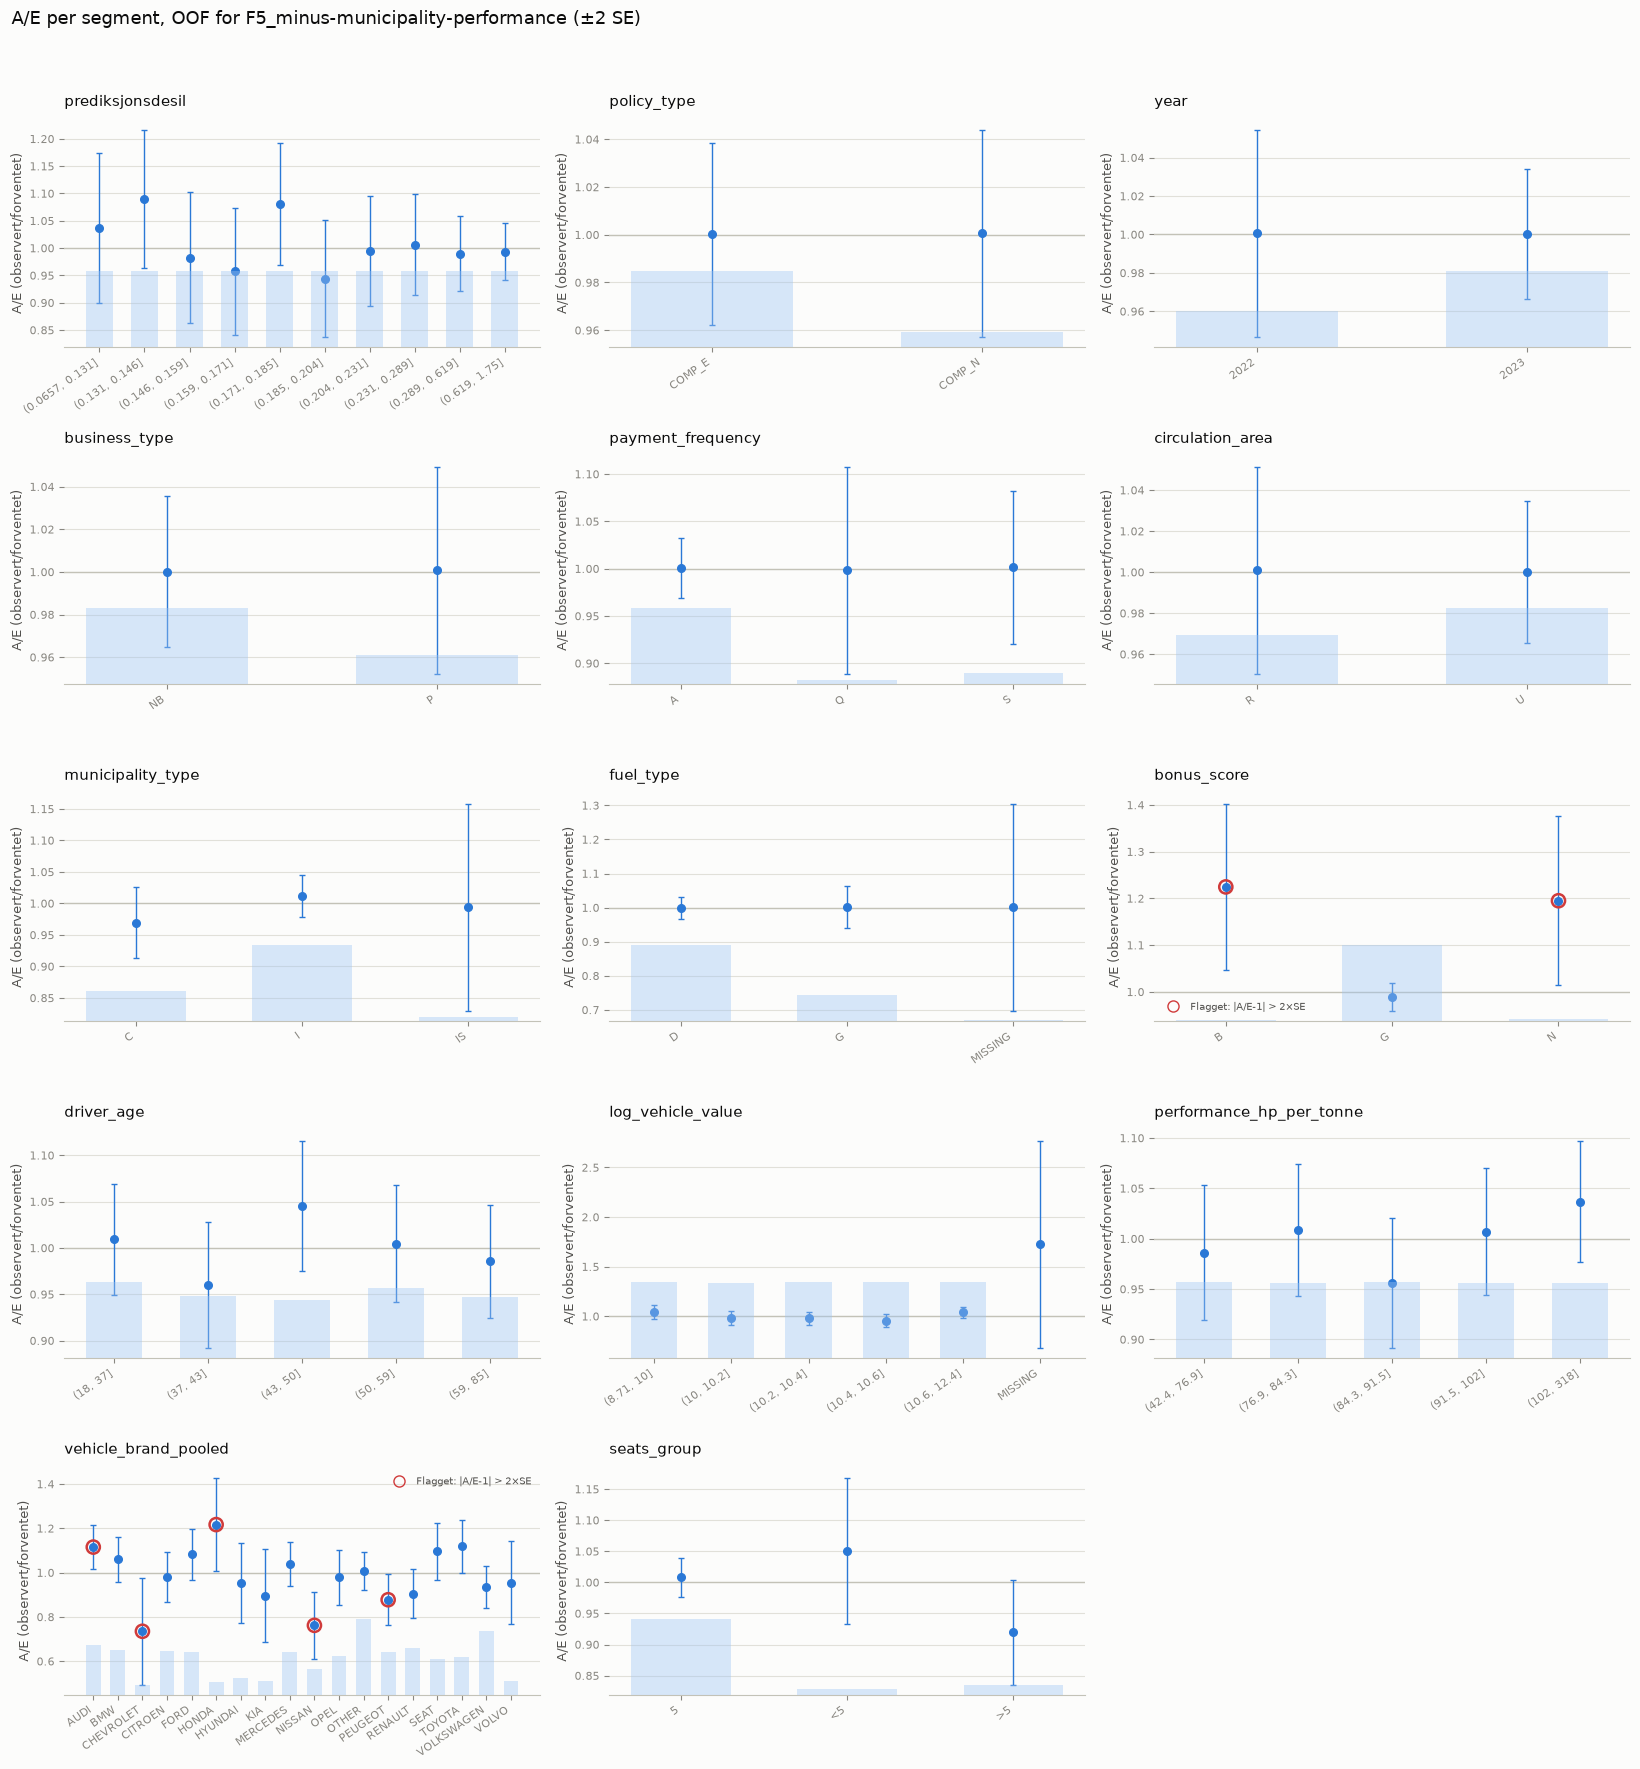

In [32]:
# A/E på OOF-prediksjonene til den frosne modellen (B-30), per forhåndsdefinert segment
final_oof = final_result["oof"]
oof_phi = final_result["scores"]["pearson_phi"].mean()
ae_segments = [
    "portefølje",
    "prediksjonsdesil",
    "policy_type",
    "year",
    "business_type",
    "payment_frequency",
    "circulation_area",
    "municipality_type",
    "fuel_type",
    "bonus_score",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "vehicle_brand_pooled",
    "seats_group",
]
ae_table = build_actual_expected_table(
    model_frame.assign(portefølje="alle"),
    final_oof,
    ae_segments,
    categorical=("year", "bonus_score"),
    dispersion=oof_phi,
).assign(støygrense=lambda t: 2 * t["ae_se"])
material = ae_table[ae_table["flag"] & ae_table["exposure"].ge(MIN_STABILITY_EXPOSURE)]
print(
    f"A/E totalt {ae_table.loc[0, 'ae']:.4f}; φ̂ (foldsnitt) {oof_phi:.3f}. "
    f"Nivåer utenfor støygrensen med ≥{MIN_STABILITY_EXPOSURE} eksponeringsår: {len(material)}"
)
for _, row in material.iterrows():
    print(
        f"  {row['segment']}={row['level']}: A/E {row['ae']:.3f} "
        f"(±{row['støygrense']:.3f}), {row['exposure']:.0f} eksponeringsår"
    )
print("Ingen modell endres her; systematiske avvik vurderes manuelt (B-07).")
with pd.option_context("display.max_rows", 200):
    display(ae_table.set_index(["segment", "level"]).round(4))
display(
    plot_actual_expected(
        ae_table[ae_table["segment"].ne("portefølje")],
        title=f"A/E per segment, OOF for {FREQUENCY_MODEL_ID} (±2 SE)",
    )
)

Pearson-φ̂ på antall: in-sample 2.043, OOF 2.054, foldsnitt 2.043
Cameron–Trivedi NB2-form (α·m): α̂ 3.656, cluster-SE 0.126, z 29.0
Cameron–Trivedi NB1-form (α): α̂ 1.003, cluster-SE 0.066, z 15.2
Alle: observert/forventet k=0 1.058, k=1 0.539, k=3 1.3 (245 mot 182.8), k=4 12.8 (418 mot 32.8), k=5 59.6 (335 mot 5.6), k=6 54.7 (49 mot 0.9), k=10+ 14785.7 (5 mot 0.0)
COMP_E: observert/forventet k=0 1.030, k=1 0.636, k=3 5.4 (137 mot 25.6), k=4 114.5 (164 mot 1.4), k=5 852.8 (61 mot 0.1), k=6 2725.0 (9 mot 0.0), k=10+ 0.0 (0 mot 0.0)
COMP_N: observert/forventet k=0 1.249, k=1 0.345, k=3 0.7 (108 mot 157.2), k=4 8.1 (254 mot 31.3), k=5 49.4 (274 mot 5.5), k=6 44.8 (40 mot 0.9), k=10+ 14786.3 (5 mot 0.0)


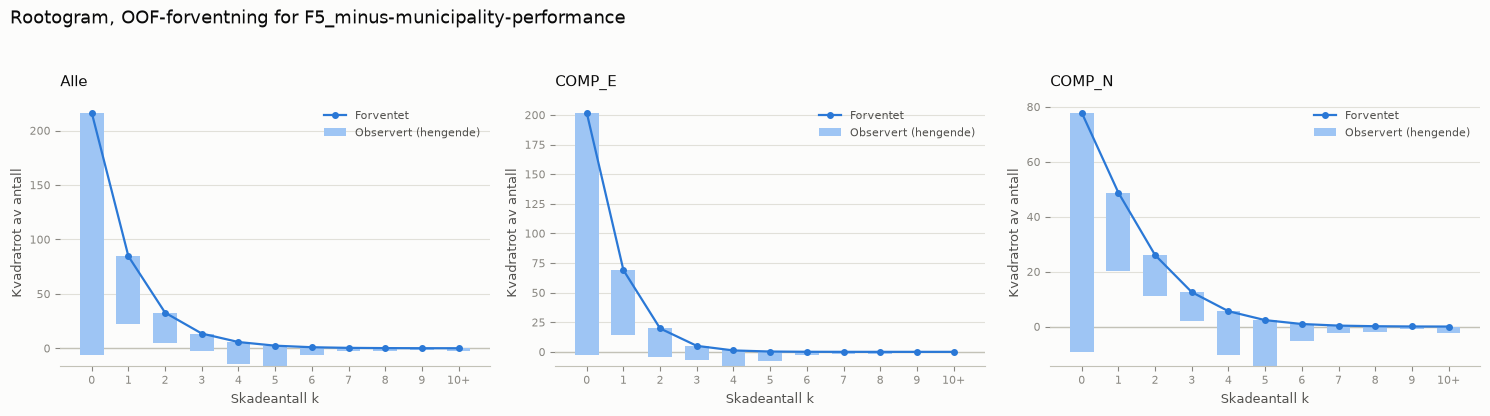

In [33]:
# Fit på hele train-poolen med cluster-kovarians på insured_id (B-21); gjenbrukes i 3.10
final_spec = final_result["spec"]
(final_design,), final_state = prepare_fold_frames(
    final_spec, model_frame, [model_frame], prepare_design_frame
)
assert final_design.index.equals(model_frame.index)
cluster_groups = pd.factorize(final_design["insured_id"])[0]
final_fit = fit_glm(final_spec, final_design, cluster_groups=cluster_groups)

claims = final_design["property_claims"]
fitted_counts = final_design["total_exposure"] * final_fit.predict(final_design)
oof_counts = model_frame["total_exposure"] * final_oof

# Pearson-dispersjon på antallsskala, in-sample og OOF
n_parameters = np.linalg.matrix_rank(final_fit.model.exog)
pearson_in_sample = ((claims - fitted_counts) ** 2 / fitted_counts).sum() / (
    len(claims) - n_parameters
)
assert np.isclose(pearson_in_sample, final_fit.pearson_chi2 / final_fit.df_resid)
pearson_oof = ((claims - oof_counts) ** 2 / oof_counts).sum() / len(claims)

# Cameron–Trivedi: hjelperegresjon med cluster-robust inferens på insured_id
ct_response = ((claims - fitted_counts) ** 2 - claims) / fitted_counts
ct_fits = {
    "NB2-form (α·m)": sm.OLS(ct_response, fitted_counts),
    "NB1-form (α)": sm.OLS(ct_response, np.ones(len(claims))),
}
print(
    f"Pearson-φ̂ på antall: in-sample {pearson_in_sample:.3f}, OOF {pearson_oof:.3f}, "
    f"foldsnitt {oof_phi:.3f}"
)
for label, model in ct_fits.items():
    fit = model.fit(cov_type="cluster", cov_kwds={"groups": cluster_groups})
    print(
        f"Cameron–Trivedi {label}: α̂ {fit.params.iloc[0]:.3f}, cluster-SE "
        f"{fit.bse.iloc[0]:.3f}, z {fit.tvalues.iloc[0]:.1f}"
    )

# Rootogram med OOF-forventning per rad: alle, og per produkt for pukkelen ved 4–5
rootogram = pd.concat(
    [build_rootogram_table(claims, oof_counts, label="Alle")]
    + [
        build_rootogram_table(
            claims[final_design["policy_type"].eq(product)],
            oof_counts[final_design["policy_type"].eq(product)],
            label=product,
        )
        for product in interactions.INTERACTION_PRODUCTS
    ],
    ignore_index=True,
)
for label, part in rootogram.groupby("label", sort=False):
    ratios = part.set_index("k").eval("observed / expected")
    counts = part.set_index("k")
    print(
        f"{label}: observert/forventet k=0 {ratios['0']:.3f}, k=1 {ratios['1']:.3f}, "
        + ", ".join(
            f"k={k} {ratios[k]:.1f} ({counts.loc[k, 'observed']:.0f} mot "
            f"{counts.loc[k, 'expected']:.1f})"
            for k in ["3", "4", "5", "6", "10+"]
        )
    )
display(
    plot_rootogram(
        rootogram, title=f"Rootogram, OOF-forventning for {FREQUENCY_MODEL_ID}"
    )
)

### 3.10 Valgt frekvensmodell: effekter

**Konklusjon og implikasjoner for neste steg**

- Alle effekter har 95 % cluster-KI utenfor 1, bortsett fra halvårlig betaling
  (1,10; KI 1,00–1,21) og manglende drivstoff (285 eksponeringsår).
- Største relativiteter:
  - COMP_N ×3,66.
  - Kvartalsbetaling ×1,44.
  - Forretningstype P mot NB ×1,36.
  - Bruksmiljø R mot U ×0,84.
  - Drivstoff G mot D ×0,87.
  - +10 % kjøretøyverdi ×1,03.
- Alderseffekten er U-formet og felles for begge produkter: ×1,21 ved 29 år og
  ×1,35 ved 70 år, relativt til 46 år. Halene har bredere KI.
- Balansen in-sample er 1. Antall med offset gir samme fit som rate med vekt.
- **Tolkning:** effektene er prediktive, ikke kausale.
  - Betalingsfrekvens og forretningstype fanger trolig kundeatferd og seleksjon.
  - COMP_N-relativiteten avhenger av hvordan skadene telles: ×3,66 med fullt antall,
    ×2,98 med antall kappet ved 3 (3.11, sensitivitet 5).
  - Timingforbeholdet (B-27) gjelder alle risikofelt.

F5 (B-30) estimeres på hele train-poolen (fitten fra 3.9):

$$
\log\lambda_i=\beta_0+\beta_{p(i)}+\beta_{\text{år}(i)}+f(\text{alder}_i)
+\beta_v\log(\text{verdi}_i)+\sum_k \beta_{k,\text{nivå}(i)} ,
$$

der $k$ er drivstoff, sirkulasjonsområde, betalingsfrekvens og forretningstype.

Modellen er additiv på logskala: produktet flytter bare nivået, og alle
relativiteter er felles for COMP_E og COMP_N. Konfidensintervallene bruker
cluster-robust sandwich-kovarians på `insured_id` (B-21) og skaleres **ikke**
i tillegg med Pearson-$\hat\phi$ (B-23).

- **Kategorier:** $\exp(\hat\beta)$ mot basisnivået med 95 %-KI.
- **Logverdi:** vist per +10 % kjøretøyverdi, $\exp(\hat\beta\log 1{,}1)$.
  Det er en realistisk endring, mens én logenhet er nesten en tredobling.
- **Alderskurven** er en spline og vises som én felles relativ kurve,
  $\exp\{f(x)-f(x_{\text{ref}})\}$, med deltametode-KI fra cluster-kovariansen,
  $SE=\sqrt{d^\top\hat\Sigma_{\text{cluster}}d}$, på gridet p2,5–p97,5 for hele
  poolen. Kurven gjelder begge produkter; produktet ganger bare med
  produktrelativiteten i tabellen.

Kontroller: in-sample-balansen er numerisk 1 (Poisson med intercept og
log-link), og antall + offset gir samme koeffisienter og cluster-SE som rate
+ vekt for den valgte modellen (B-26, 3.12).

In [34]:
# 3.12: in-sample-balanse ≈ 1 og B-26 for den valgte modellen, inkl. cluster-SE
assert final_spec["model_id"] == FREQUENCY_MODEL_ID and not final_spec["derived"]
in_sample = build_glm_summary(final_spec, final_fit, final_design)
assert abs(in_sample["balanse"] - 1) < 1e-6, in_sample["balanse"]
count_fit = smf.glm(
    "property_claims ~" + final_spec["formula"].split("~")[1],
    data=final_design,
    family=sm.families.Poisson(link=LOG_LINK),
    offset=np.log(final_design["total_exposure"]),
).fit(cov_type="cluster", cov_kwds={"groups": cluster_groups})
assert np.allclose(count_fit.params, final_fit.params, rtol=1e-6, atol=1e-8)
assert np.allclose(count_fit.bse, final_fit.bse, rtol=1e-4)
del count_fit

print(
    f"In-sample: deviance {in_sample['deviance']:.5f}, D² {in_sample['d2']:.4f}, "
    f"balanse {in_sample['balanse']:.8f}."
)
effect_table = build_effect_table(
    build_relativity_table(final_spec, final_fit),
    linear_scales={"log_vehicle_value": (np.log(1.1), "+10 % kjøretøyverdi")},
    exposure_by_variable={
        column: model_frame.groupby(column)["total_exposure"].sum()
        for column in final_spec["base_levels"]
    },
)
display(effect_table.round(4))

In-sample: deviance 1.11979, D² 0.0993, balanse 1.00000000.


koeffisient  standardfeil  relativitet  \
variabel          nivå                                                     
policy_type       COMP_E (basis)          NaN           NaN       1.0000   
                  COMP_N               1.2965        0.0331       3.6564   
year              2023 (basis)            NaN           NaN       1.0000   
                  2022                -0.0820        0.0365       0.9213   
log_vehicle_value                      0.3299        0.0440       1.0319   
fuel_type         D (basis)               NaN           NaN       1.0000   
                  G                   -0.1444        0.0404       0.8655   
                  MISSING              0.0288        0.1383       1.0292   
circulation_area  U (basis)               NaN           NaN       1.0000   
                  R                   -0.1704        0.0336       0.8433   
payment_frequency A (basis)               NaN           NaN       1.0000   
                  Q                    0.3661        0.0630       1.4421   
                  S                    0.0964        0.0496       1.1012   
business_type     NB (basis)              NaN           NaN       1.0000   
                  P                    0.3047        0.0359       1.3563   

                                  ki_lav  ki_høy              endring  \
variabel          nivå                                                  
policy_type       COMP_E (basis)     NaN     NaN            mot basis   
                  COMP_N          3.4268  3.9014            mot basis   
year              2023 (basis)       NaN     NaN            mot basis   
                  2022            0.8577  0.9896            mot basis   
log_vehicle_value                 1.0235  1.0405  +10 % kjøretøyverdi   
fuel_type         D (basis)          NaN     NaN            mot basis   
                  G               0.7997  0.9367            mot basis   
                  MISSING         0.7848  1.3496            mot basis   
circulation_area  U (basis)          NaN     NaN            mot basis   
                  R               0.7896  0.9007            mot basis   
payment_frequency A (basis)          NaN     NaN            mot basis   
                  Q               1.2746  1.6318            mot basis   
                  S               0.9992  1.2136            mot basis   
business_type     NB (basis)         NaN     NaN            mot basis   
                  P               1.2641  1.4551            mot basis   

                                  eksponering  ki_utenfor_1  
variabel          nivå                                       
policy_type       COMP_E (basis)   30816.9096         False  
                  COMP_N            6309.1041          True  
year              2023 (basis)     25112.9562         False  
                  2022             12013.0575          True  
log_vehicle_value                         NaN          True  
fuel_type         D (basis)        27359.1534         False  
                  G                 9482.1315          True  
                  MISSING                 NaN         False  
circulation_area  U (basis)        22485.0767         False  
                  R                14640.9370          True  
payment_frequency A (basis)        30722.3616         False  
                  Q                 1817.3014          True  
                  S                 4586.3507         False  
business_type     NB (basis)       26954.0630         False  
                  P                10171.9507          True

Alder relativ mot 46 år (begge produkter): 29 år 1.212 (KI 1.072–1.372); 70 år 1.349 (KI 1.218–1.494)


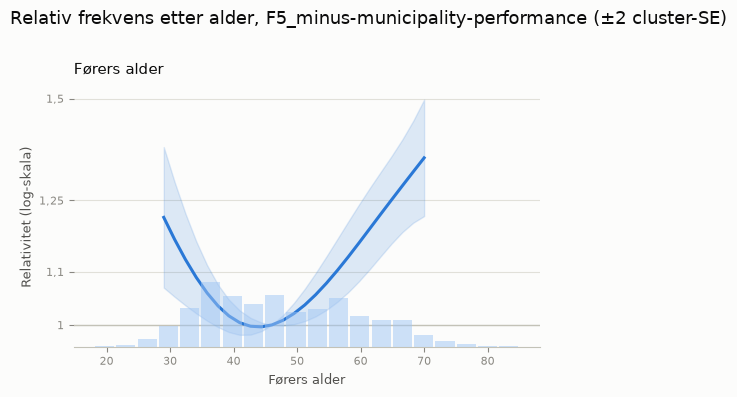

In [35]:
# Felles relativ alderskurve med deltametode-KI fra cluster-kovariansen.
# Visningen gir kurvefunksjonen φ̂ = 1, så kovariansen brukes uskalert (B-23).
cluster_view = SimpleNamespace(
    model=final_fit.model,
    params=final_fit.params,
    cov_params=final_fit.cov_params,
    pearson_chi2=1.0,
    df_resid=1.0,
    scale=1.0,
)
final_curves = frequency_curve_hook(
    final_spec, "full", cluster_view, final_design, final_design, final_state
)["curves"].query("feature == 'driver_age'")
assert set(final_curves["product"]) == {"ALLE"}  # additiv: én kurve for begge produkter
ends = final_curves.sort_values("x").iloc[[0, -1]]
print(
    f"Alder relativ mot {CURVE_GRIDS['driver_age']['reference']:.0f} år (begge produkter): "
    + "; ".join(
        f"{r.x:.0f} år {r.relative:.3f} (KI {r.relative * np.exp(-1.96 * r.se_log):.3f}–"
        f"{r.relative * np.exp(1.96 * r.se_log):.3f})"
        for r in ends.itertuples()
    )
)
display(
    plot_fold_curves(
        final_curves,
        support_frame=model_frame,
        feature_labels={"driver_age": "Førers alder"},
        title=f"Relativ frekvens etter alder, {FREQUENCY_MODEL_ID} (±2 cluster-SE)",
    )
)

### 3.11 Sensitiviteter

**Konklusjon og implikasjoner for neste steg**

- **Uten kansellerte (B-01):**
  - Nivået faller til ×0,91, men ingen relativitet flytter seg mer enn 1,3
    cluster-SE (COMP_N ×0,96).
  - Kansellerte poliseår har 5 % av eksponeringen og 13 % av skadene (A/E 2,7).
    Derfor overpredikerer hovedmodellen aktive poliser med ca. 9 %, og modellen
    uten kansellerte er bedre på aktive rader (+0,0023, 4/5 folder).
  - Dette er forventet: en tariff må prise poliser som senere kanselleres.
    B-01 står, men nivået er følsomt for kanselleringsandelen (fase 3).
- **Fri eksponeringskoeffisient:** δ = 0,10 (95 % KI 0,01–0,19), altså
  antall ∝ e^1,10.
  - Kort eksponering gir litt *lavere* årsfrekvens, ca. ×0,93 ved e = 0,5.
  - Mulige årsaker er sesong, meldeforsinkelse eller hvordan poliseår er delt
    opp; det er ikke undersøkt.
  - Relativitetene endres høyst 3 %. Fast offset beholdes; forutsetningen
    noteres til fase 3.
- **Kjøreerfaring** i stedet for alder er dårligere i alle former (lineær 0/5,
  df3 og df4 2/5 folder). Alder beholdes (B-11).
- **Skadetelling og pukkelen (B-03):**
  - **Nesten bare produktnivået påvirkes.** COMP_N-relativiteten flytter seg
    mye med tellemåten:
    - ×3,66 med fullt antall.
    - ×2,98 med antall kappet ved 3 (−6,2 SE).
    - ×2,07 med skade ja/nei.
  - Forretningstype P går fra ×1,36 til ×1,29 (−1,5 SE). Alle andre effekter
    flytter seg ≤1 SE ved kapping. Skiftene er målt i hovedmodellens SE og er
    ikke en formell test.
  - **De høye antallene ligger systematisk, ikke tilfeldig.** Scoret på fullt
    antall taper modellen med kappet antall både i gruppe-CV (−0,0028, z −2,9,
    2/5 folder) og i tidsfolden (−0,0057, z −5,1).
    - De høye antallene er altså forutsigbare på segmentnivå, særlig COMP_N og
      forretningstype P.
    - Om de er reell risiko eller registreringspraksis, kan dataene ikke avgjøre.
  - **Hovedmodellen på vanlige skader:** scoret på kappet antall taper
    hovedmodellen innen samme periode (z −3,9, 0/5 folder), men ikke fremover i
    tid (z −0,3). Pukkelen kan altså gi for høye prediksjoner på vanlige skader i
    COMP_N. *Usikkert.*
  - **B-03 står.** Fullt antall beholdes som frekvensrespons.
    - COMP_N-nivået oppgis som usikkert: ca. ×3,0–3,7 per skade og ×2,1 per
      poliseår med skade.
    - En engangssjekk utenfor notebooken viser at poliseår med 4 skader koster
      ca. 3 ganger så mye som poliseår med 1. Pukkelen er derfor reell kostnad
      og skal med i nivået for ren premie.
    - Usikkerheten gjelder først og fremst fordelingen mellom frekvens og
      snittskade.
- Merkegrense 250/1 000 kjøres ikke fordi merke ikke kvalifiserte (3.5).
  Bonus kjøres ikke fordi as-of-porten ikke er bestått (B-13).

Sensitivitetene holder den frosne frekvensmodellen F5 fast (B-30) og endrer
aldri hovedmodellen (planens 3.10).

**(1) Uten kansellerte (B-01).** Samme spesifikasjon estimeres bare på aktive
rader i hver treningsfold:

$$
\hat\beta^{\text{aktiv}}=\arg\max_\beta \sum_{i\in\text{trening},\ \text{status}_i\neq C}
\ell_i(\beta),
$$

og begge modellene predikerer hele valideringsfolden. Scorene sammenlignes på
de samme aktive valideringsradene (parvis per fold), og i tillegg vises
kansellerte og alle rader. Treningspopulasjonen er endret, så dette er ikke en
kandidat. *Intuisjon:* kansellerte poliser har kort eksponering og mange skader.
Tabellen viser om de trekker nivået og relativitetene.

**(2) Fri eksponeringskoeffisient.** Antallsmodell med offset og et ekstra ledd:

$$
\log E[N_i]=\log e_i+\delta\log e_i+\eta_i ,
$$

der $\delta=0$ er proporsjonalitet og $1+\delta$ er total
eksponeringskoeffisient. $\delta<0$ betyr at korte perioder har høyere frekvens
per eksponeringsår. Estimeres på hele train-poolen med cluster-KI. Dette er
diagnostikk av eksponering og seleksjon, ikke en tariffmodell: faktisk varighet
er ikke kjent ved prising.

**(4) Kjøreerfaring i stedet for alder (B-11).** I F5 erstattes hele førerleddet:

$$
\log\lambda_i=\eta^{\text{F5}\setminus\text{alder}}_i+g(\text{erfaring}_i),\qquad
g\in\{\text{lineær},\ \text{df}=3,\ \text{df}=4\}.
$$

Øvrige ledd er faste, foldene er de samme, og den ene manglende verdien får
foldmedianen. Ingen produkthelning tas med (B-28, B-30). Definisjonen av
erfaring er uavklart (B-11), så ingen erfaringsmodell kan rykke opp.

**(5) Skadetelling / pukkelen (B-03)** beskrives i egen celle rett før
beregningen.

**Utgår eller utsettes.**

- **(3) Merkegrense 250/1 000** utgår: merke kvalifiserte ikke ved 500 (3.5)
  og er ikke i finalisten.
- **(6) Bonus** (planens pkt. 5) kjøres ikke. As-of-porten er ikke bestått
  (B-13), og bonus er ikke nødvendig for å ferdigstille fase 1. A/E per
  bonusnivå står i 3.9.
- **(7) Lagget skadehistorikk og (8) ridge** (planens pkt. 6–7) er utsatt etter
  planens 3.10: historikk krever egen populasjon og tidsdesign, og ingen
  nær-kollinearitet eller ustabile kurver tilsier regularisering.

**Tabell 1:** uten kansellerte. **Tabell 2 og plott 1:** erfaring mot alder.
**Plott 2:** relativiteter med tre skadetellinger (5).

In [36]:
# (1) Uten kansellerte: tren bare på aktive rader i hver eksisterende fold
# Sensitivitetene gjelder den frosne modellen F5 (B-30)
display(
    sensitivities.test_without_cancelled(
        frequency_cv,
        FREQUENCY_MODEL_ID,
        final_spec,
        model_frame,
        cv_folds,
        final_design,
        final_fit,
        final_oof,
        cross_validate_glm,
        fit_glm,
        paired_improvement,
    )
)

Status i train-poolen: A 51908, C 3338


Aktive valideringsrader, uten kansellerte mot hovedmodell: poolet gevinst 0.002302, snitt 0.002298, SE 0.000801, bedre i 4/5 folder


Nivå uten kansellerte (in-sample, alle rader): ×0.912. Største relativitetsendringer: C(fuel_type, Treatment('D'))[T.MISSING] ×1.117 (0.8 cluster-SE); C(payment_frequency, Treatment('A'))[T.S] ×1.045 (0.9 cluster-SE); C(policy_type, Treatment('COMP_E'))[T.COMP_N] ×0.959 (1.3 cluster-SE)


,rader,eksponering,skader,deviance_hovedmodell,AE_hovedmodell,deviance_uten_kansellerte,AE_uten_kansellerte,prediksjon_ratio
delmengde,,,,,,,,
aktive,51908,35257.7342,8658,1.0338,0.9124,1.0315,1.0005,0.9119
kansellerte,3338,1868.2795,1331,2.7802,2.6843,2.8773,2.9540,0.9087
alle,55246,37126.0137,9989,1.1217,1.0004,1.1244,1.0972,0.9118


In [37]:
# (2) Fri eksponeringskoeffisient: antall med offset log(e) + δ·log(e), cluster-KI
sensitivities.test_free_exposure_coefficient(
    final_spec, final_design, final_fit, cluster_groups
)

δ = 0.103 (95 % cluster-KI 0.012 til 0.193); total eksponeringskoeffisient 1+δ = 1.103. Andel poliseår med e < 1: 66.5%. In-sample deviance-endring (antallsskala) 14.6. Største relativitetsendring: C(business_type, Treatment('NB'))[T.P] ×0.970


Ingen nær-treff (3/5) i denne sammenligningen.


Poolet_gevinst  Snitt_gevinst  \
Referanse                         Kandidat                                    
F5_minus-municipality-performance S4_exp-lin       -0.002117      -0.002119   
                                  S4_exp-df3       -0.000676      -0.000673   
                                  S4_exp-df4       -0.000539      -0.000534   

                                              SE_gevinst  Folder_forbedret  \
Referanse                         Kandidat                                   
F5_minus-municipality-performance S4_exp-lin    0.000260                 0   
                                  S4_exp-df3    0.000428                 2   
                                  S4_exp-df4    0.000668                 2   

                                             merknad stability  note  \
Referanse                         Kandidat                             
F5_minus-municipality-performance S4_exp-lin            stabil  None   
                                  S4_exp-df3            stabil  None   
                                  S4_exp-df4            stabil  None   

                                                                                     former  \
Referanse                         Kandidat                                                    
F5_minus-municipality-performance S4_exp-lin  driving_experience_years=lineær, verdi=lineær   
                                  S4_exp-df3     driving_experience_years=df3, verdi=lineær   
                                  S4_exp-df4     driving_experience_years=df4, verdi=lineær   

                                              parametere  oof_deviance  \
Referanse                         Kandidat                               
F5_minus-municipality-performance S4_exp-lin          11      1.123792   
                                  S4_exp-df3          13      1.122351   
                                  S4_exp-df4          14      1.122215   

                                                oof_d2  
Referanse                         Kandidat              
F5_minus-municipality-performance S4_exp-lin  0.096171  
                                  S4_exp-df3  0.097330  
                                  S4_exp-df4  0.097440

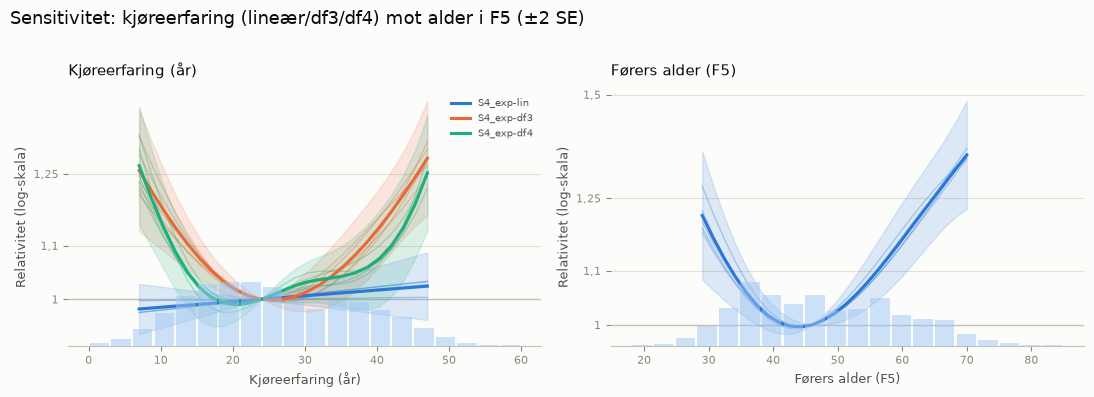

In [38]:
# (4) Kjøreerfaring i stedet for alder i den frosne modellen F5
experience_table, experience_figure = sensitivities.test_experience_vs_age(
    frequency_cv, FREQUENCY_MODEL_ID, final_spec, model_frame, cross_validate_candidate
)
display(experience_table)
# Plott: erfaringskurver (folder og hele train-poolen) ved siden av alderskurven i F5
display(experience_figure)

**(5) Skadetelling / pukkelen (B-03).** 1,5 % av poliseårene har minst fire
skader og står for 38 % av skadene, mest i COMP_N (rootogrammet i 3.9). Hvis
pukkelen er registreringspraksis (én hendelse blir flere skader), kan den trekke
relativitetene. Samme F5-spesifikasjon, offset og folder estimeres med tre
responser:

$$
\log E[Y_i]=\log e_i+\eta_i^{\text{F5}},\qquad
Y_i\in\bigl\{\underbrace{N_i}_{\text{a) fullt antall}},\;
\underbrace{\min(N_i,3)}_{\text{b) kappet ved 3}},\;
\underbrace{\mathbf 1\{N_i>0\}}_{\text{c) skade ja/nei}}\bigr\}.
$$

c) er standardtilnærmingen for skadeteller-frekvens:
$P(N_i>0)=1-e^{-\lambda_i e_i}\approx\lambda_i e_i$ når $\lambda_i e_i$ er
liten. *Intuisjon:* b) og c) gir en polise med fem skader samme vekt som én med
tre eller én skade. En relativitet som flytter seg, bæres delvis av pukkelen.

- **Relativiteter:** in-sample på hele train-poolen med cluster-KI (plott 2).
- **Rangering:** deviance på ulike responser er ikke sammenlignbar, og b) og c)
  predikerer et lavere nivå. Nivået rekalibreres derfor med én faktor lært i
  treningsfolden $T_k$:

$$
c_k=\frac{\sum_{i\in T_k}N_i}{\sum_{i\in T_k}e_i\,\hat\lambda_i^{(\mathrm{b/c})}} ,
$$

og alle modellene scores med Poisson-deviance på *fullt* antall i
valideringsfolden, som i hovedstigen. Én konstant endrer ikke rekkefølgen, så
sammenligningen måler rangering og relativiteter, ikke nivå. Motsatt retning:
a) rekalibreres til $\sum\min(N_i,3)$ og scores mot b) på kappet antall. Det
viser om hovedmodellen rangerer «vanlige» skader dårligere. Samme sammenligning
kjøres i tidsfolden 2022 → 2023 uten årsledd (B-25).

Dette er en sensitivitet: ingen modell endres, og b) og c) er ikke kandidater.

In-sample relativiteter, fullt antall: COMP_N ×3.656, P ×1.356; kappet ved 3: COMP_N ×2.981, P ×1.286; skade ja/nei: COMP_N ×2.072, P ×1.169
kappet ved 3 mot fullt antall: største skift policy_type COMP_N ×2.981 (-6.2 SE); business_type P ×1.286 (-1.5 SE); payment_frequency S ×1.051 (-0.9 SE). Største endring i cluster-SE: alder 29 mot 46 år ×0.88; payment_frequency Q ×0.89; +10 % kjøretøyverdi ×0.89
skade ja/nei mot fullt antall: største skift policy_type COMP_N ×2.072 (-17.2 SE); business_type P ×1.169 (-4.2 SE); payment_frequency S ×0.986 (-2.2 SE). Største endring i cluster-SE: +10 % kjøretøyverdi ×0.78; alder 29 mot 46 år ×0.78; fuel_type G ×0.79


Rekalibreringsfaktor til fullt antall (gruppefolder; tidsfold): kappet ved 3 1.152–1.161; 1.131; skade ja/nei 1.731–1.774; 1.637
Ingen nær-treff (3/5) i denne sammenligningen.
kappet ved 3 mot fullt antall, scoret på fullt antall (gevinst > 0: kandidat bedre). Gruppe-CV: poolet -0.002809, snitt -0.002812, fold-SE 0.001292, cluster-SE 0.000955 (z -2.9), bedre i 2/5 folder. Tidsfold 2022→2023: -0.005747, cluster-SE 0.001132 (z -5.1)
skade ja/nei mot fullt antall, scoret på fullt antall (gevinst > 0: kandidat bedre). Gruppe-CV: poolet -0.022608, snitt -0.022618, fold-SE 0.003671, cluster-SE 0.002730 (z -8.3), bedre i 0/5 folder. Tidsfold 2022→2023: -0.042216, cluster-SE 0.003909 (z -10.8)
fullt antall mot kappet ved 3, scoret på kappet ved 3 (gevinst > 0: kandidat bedre). Gruppe-CV: poolet -0.002752, snitt -0.002749, fold-SE 0.001046, cluster-SE 0.000706 (z -3.9), bedre i 0/5 folder. Tidsfold 2022→2023: -0.000223, cluster-SE 0.000808 (z -0.3)


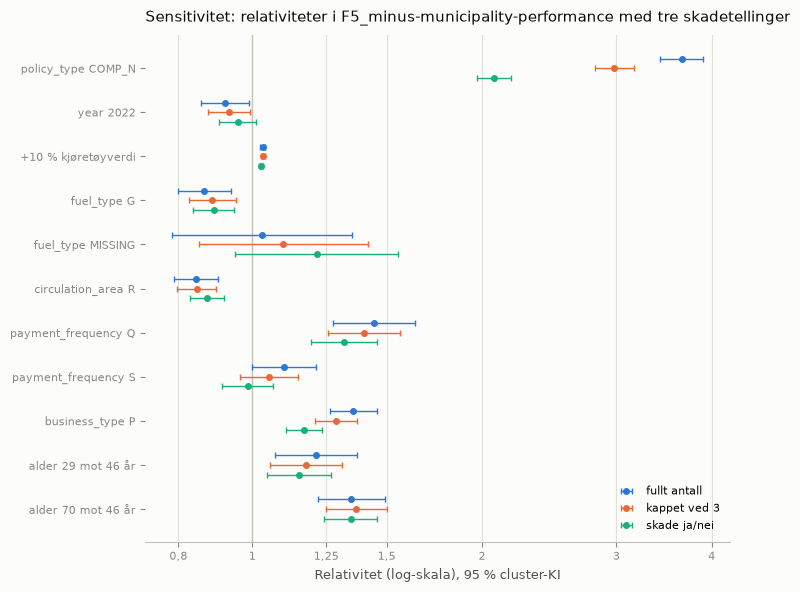

In [39]:
# (5) Skadetelling / pukkelen (B-03). SENSITIVITET: F5 holdes fast (B-30);
# bare responsen byttes i kopier av spesifikasjonen, og ingen modell endres.
display(
    sensitivities.test_claim_count_sensitivity(
        FREQUENCY_MODEL_ID,
        model_frame,
        final_spec,
        final_design,
        final_fit,
        final_oof,
        fit_glm,
        cluster_groups,
        cross_validate_glm,
        cv_folds,
        time_fold,
        time_val,
        time_predictions,
        without_year,
        effect_table,
        final_state,
        paired_improvement,
    )
)

### 3.11A Separat ABESS-diagnostikk for frekvens

**Konklusjon:** ABESS gir ikke grunnlag for å endre den låste GLM-en
`F5_minus-municipality-performance` (B-30). Begge forhåndslåste ABESS-oppsett
har laveste pooled OOF-deviance ved ni grupper og velger samme subset:
produkt, år, føreralder, log(bilverdi), drivstoff, urban/rural,
betalingsfrekvens, NB/P og poolingsdefinert merke. Ytelse, kommune og seter
velges ikke. ABESS taper 0,000531 i pooled OOF Poisson-deviance mot F5
(cluster-SE 0,000840). Dette er dermed ikke engang en bedre utviklingsscore,
langt mindre dokumentasjon på generaliseringsgevinst.

For poliseår $i$ med skadeantall $N_i$, eksponering $e_i$ og et helt sett av
valgte variabelblokker $S$ brukes

$$
N_i \sim \operatorname{Poisson}(e_i\lambda_i),
\qquad
\log(\lambda_i)=\beta_0+X_{i,S}\beta_S.
$$

ABESS søker over hele blokker $S$: alle dummyer for én kategori og alle
basiskolonner i én spline hører sammen. Produkt og år er obligatoriske;
interseptet inngår alltid, men er ikke en selekterbar gruppe. I ABESS 0.4.11
fittes frekvensen som $N_i/e_i$ med `sample_weight=e_i`, som er ekvivalent med
Poisson for antall med $\log e_i$ som offset når `alpha=0`.

Kandidatrommet er låst til A (lineær ytelse) og B (sentrert naturlig spline,
df=3, for ytelse). Begge har sentrert naturlig spline df=3 for føreralder og
lineær log(bilverdi). Alle størrelser 2–12 kjøres eksplisitt i hver
treningsfold; ABESS-EBIC og intern tilfeldig CV brukes ikke. Imputering og
Patsy-basis læres på trening og anvendes på validering.

**Forbehold:** Funksjonsformene bygger delvis på tidligere resultater fra de
samme fem foldene, og ABESS-størrelsen velges også på dem. OOF-scorene er
derfor en utviklingssammenligning med seleksjonsoptimisme, ikke uavhengig
evaluering av seleksjonsprosedyren. Foldvis preprocessing fjerner ikke dette
forbeholdet. Seleksjonsfrekvens over fem overlappende treningssett er
beskrivende stabilitet, ikke sannsynligheten for at en blokk er «riktig».
Timingforbeholdet i B-27 gjelder fortsatt: feltene er ikke dokumenterte
startverdier for polisene.

In [40]:
# Separat resultatobjekt: ABESS endrer aldri frequency_cv eller hovedmodellens ID.
assert "test" not in frames and set(model_frame["year"]) == set(TRAIN_YEARS)
frequency_ids_before_abess = tuple(frequency_cv)
frequency_model_before_abess = FREQUENCY_MODEL_ID
abess_frequency = abess_diagnostics.run_frequency_abess_diagnostic(
    frame=model_frame,
    folds=cv_folds,
    glm_spec=glm_spec,
    prepare_design_frame=prepare_design_frame,
    frequency_target=TARGETS["frequency"],
    locked_glm_oof=final_oof,
    locked_glm_name=FREQUENCY_MODEL_ID,
)
assert tuple(frequency_cv) == frequency_ids_before_abess
assert FREQUENCY_MODEL_ID == frequency_model_before_abess
assert final_oof.equals(frequency_cv[FREQUENCY_MODEL_ID]["oof"])
assert abess_frequency["oof_predictions"].notna().all().all()
assert set(abess_frequency["score_curve"]["gruppestørrelse"]) == set(range(2, 13))
print(
    "Syntetisk ABESS-kontroll: "
    f"versjon {abess_frequency['verification']['abess_version']}; "
    f"maks parameteravvik {abess_frequency['verification']['max_parameter_difference']:.2e}; "
    f"maks rateprediksjonsavvik {abess_frequency['verification']['max_prediction_difference']:.2e}."
)

Syntetisk ABESS-kontroll: versjon 0.4.11; maks parameteravvik 1.98e-08; maks rateprediksjonsavvik 3.74e-08.


**Topp 3 featurekombinasjoner.** CV velger kun to representanter per
oppsett (minimum og enklest-1SE), og disse faller ofte sammen på nøyaktig
samme subset (se konklusjonen i 3.11A). For å vise de faktisk distinkte
kombinasjonene er hele candidate-rutenettet (begge oppsett, alle
gruppestørrelser) fittet på hele utviklingssettet, deduplisert på faktisk
valgt kombinasjon og rangert på pooled OOF-deviance fra CV-scorekurven.
`valgte_blokker` lister eksplisitt hvilke featureblokker som inngår i hver
kombinasjon. Positiv `gevinst_mot_låst_glm` betyr at ABESS er bedre enn F5.
Cluster-SE er beregnet på `insured_id`, men dekker ikke usikkerheten fra
subset- og størrelsesvalget.

In [41]:
abess_top_combinations = (
    abess_frequency["full_development_grid"]
    .merge(
        abess_frequency["score_curve"][
            [
                "oppsett",
                "gruppestørrelse",
                "oof_deviance",
                "gevinst_mot_låst_glm",
                "SE_cluster_mot_låst_glm",
                "z_cluster_mot_låst_glm",
            ]
        ],
        on=["oppsett", "gruppestørrelse"],
    )
    .drop_duplicates(subset=["valgte_blokker_rå"])
    .sort_values("oof_deviance")
    .head(3)
    .reset_index(drop=True)
)
abess_top_combinations.index = abess_top_combinations.index + 1
abess_top_combinations.index.name = "rangering"
display(
    abess_top_combinations[
        [
            "oppsett",
            "gruppestørrelse",
            "antall_parametere",
            "valgte_blokker",
            "oof_deviance",
            "gevinst_mot_låst_glm",
            "SE_cluster_mot_låst_glm",
            "z_cluster_mot_låst_glm",
        ]
    ].round(6)
)

,oppsett,gruppestørrelse,antall_parametere,valgte_blokker,oof_deviance,gevinst_mot_låst_glm,SE_cluster_mot_låst_glm,z_cluster_mot_låst_glm
rangering,,,,,,,,
1,A,9,30,"produkt, år, føreralder, log(bilverdi), drivst...",1.121144,0.000531,0.000840,0.632215
2,A,11,33,"produkt, år, føreralder, log(bilverdi), ytelse...",1.121449,0.000226,0.000860,0.262544
3,A,12,35,"produkt, år, føreralder, log(bilverdi), ytelse...",1.121715,-0.000040,0.000875,-0.045545


**Koeffisienter for beste ABESS-kombinasjon** (rangering 1 over), fittet på
hele utviklingssettet med den valgte gruppestørrelsen. ABESS er en
rendyrket seleksjonsprosedyre uten standardfeil eller konfidensintervaller,
så tabellen viser bare punktestimater på log-skala — i motsetning til F5s
cluster-robuste koeffisienttabell til slutt i notebooken.

In [42]:
abess_best_combination = abess_top_combinations.iloc[0]
display(abess_best_combination["koeffisienter"].round(4).to_frame())

,koeffisient
Intercept,-4.2803
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",1.2945
"C(year, Treatment(2023))[T.2022]",-0.0834
"cr(driver_age, df=3, constraints='center')[0]",-0.3770
"cr(driver_age, df=3, constraints='center')[1]",-0.0753
"cr(driver_age, df=3, constraints='center')[2]",0.4041
log_vehicle_value,0.2505
"C(fuel_type, Treatment('D'))[T.G]",-0.1594
"C(fuel_type, Treatment('D'))[T.MISSING]",-0.0117
"C(circulation_area, Treatment('U'))[T.R]",-0.1676


### 3.12 Oppsummering fase 1

**Leveranse fra fase 1**

- **Frekvensmodell:** Poisson-GLM `F5_minus-municipality-performance` med
  log-link, eksponering som offset/vekt og cluster-robust inferens på
  `insured_id` (B-21, B-23, B-30).
  - Ledd: produkt, år, alder (naturlig spline df=3), log kjøretøyverdi (lineær),
    drivstoff, bruksmiljø, betalingsfrekvens og forretningstype. 13 parametere.
  - OOF D² 9,8 % mot 8,5 % for F0. I tidsfolden har F5 høyest D² av finalistene
    (10,3 %).
- **Valgt bort:**
  - Merke og seter (3.5).
  - Kommunetype og ytelse (3.6).
  - Produktinteraksjonen COMP_N × alder (3.7, overstyrt i 3.9 etter B-30).
  - NB2 (3.8–3.9).
  - Kjøreerfaring (3.11).

**Forbehold**

- Dette er en metodebenchmark med timingforbehold. Risikofeltene er siste
  registrering, ikke dokumenterte startverdier (B-27).
- **Seleksjonsoptimisme:** 77 spesifikasjoner er kryssvalidert på de samme foldene
  (74 i valgstigen og 3 sensitiviteter). De fleste er mellomregning.
  - Det er 16 datadrevne valg: 3 formvalg, 2 sekundære blokker, 8 kjerneblokker,
    2 interaksjoner og fordelingen. Bare 3 av valgene endret modellen:
    alder som df3, uten kommunetype og uten ytelse.
  - F5 er altså den forhåndsdefinerte kjernen F1 med tre endringer.
  - Ca. 90 % av gevinsten over F0 kommer fra den forhåndslåste kjernen:
    0,0140 (6,8 cluster-SE; D² 8,5 → 9,7 %).
  - Datastyrte valg står for ca. 10 %: 0,0016 (2,2 cluster-SE; D² 9,7 → 9,8 %).
    Bare denne delen kan være optimistisk, og den er av samme størrelse som
    støyen i valgene.
  - Regelen «enkleste innen 1 SE» trekker mot underoptimisme. Tidsfolden
    bekrefter F5 over F1 (z 2,7), men er ikke helt uavhengig av CV-dataene.
- Fold-SE i B-08 var optimistisk for små gevinster (ca. 2,6× lavere enn cluster-SE
  for F6_I1). Cluster-SE snudde ingen beslutning, men avdekket at F6_I1 var svak.
  Det ga B-30.
- 2024 er ikke brukt (B-05).

**Åpne punkter til planrevisjonen før fase 2**

1. **Skadetellingen (UAVKLART, B-03):** hvordan skadene telles i pukkelen
   (N = 4–5), er ikke dokumentert i datakilden.
   - COMP_N-nivået i frekvens avhenger av tellemåten (3.11, sensitivitet 5).
   - Vurder i planrevisjonen å endre den todelte modellen til andel poliseår med
     skade × kostnad per skadepoliseår. Den er uavhengig av hvordan skadene
     telles.
   - Tweedie beholdes som kontroll for nivået i ren premie.
   - Datakilden opplyser også at skadebeløp gjøres opp etter CICOS-avtalen med
     forhåndsavtalte beløp, så beløpene kan klumpe seg. Det må sjekkes i
     severity.
2. **B-08:** vurder parvis cluster-SE på `insured_id` i stedet for fold-SE.
3. **Nivådrift 2022→2023,** særlig i COMP_N. Det påvirker nivåsetting og
   tidsfolden i fase 2–3.
4. **Merke:** fem merker har A/E utenfor støy uten å kvalifisere som GLM-blokk.
   Merke er en kandidat for credibility- eller ML-fasen.
5. **Eksponering:** δ ≈ 0,10 og kanselleringsnivået noteres som forutsetninger
   for ren premie i fase 3.
6. **Drivstoff** er den mest usikre beholdte blokken (1,1–1,3 SE). Følg den i
   senere faser.
7. **Mindre kandidatrom i fase 2:**
   - Fase 1 kjørte langt flere modeller enn valgene krevde (formrutenett 26
     mot ca. 6 ved én variabel om gangen; reduksjonen i 3.6 overlapper
     ablasjonen i 3.4).
   - Severity har de samme skadene, men mer støy per observasjon, så samme
     stige gir mer optimisme.
   - Forslag: formvalg per variabel eller fast df, én reduksjonsrunde og et
     tak på antall datadrevne valg som låses på forhånd.

### 3.13 Endelig modell: spesifikasjon og koeffisienter

Den låste frekvensmodellen er `F5_minus-municipality-performance` (B-30),
fittet på hele train-poolen (fitten `final_fit` fra 3.9). For poliseår $i$
med skadeantall $N_i$ og eksponering $e_i$:

$$
N_i \sim \operatorname{Poisson}(e_i \lambda_i),
$$

$$
\log(\lambda_i) = \beta_0
+ \beta_{\text{produkt}(i)}
+ \beta_{\text{år}(i)}
+ f_{\text{alder}}(\text{alder}_i)
+ \beta_v \log(\text{verdi}_i)
+ \beta_{\text{drivstoff}(i)}
+ \beta_{\text{sirkulasjon}(i)}
+ \beta_{\text{betaling}(i)}
+ \beta_{\text{forretning}(i)}.
$$

$f_{\text{alder}}$ er en sentrert naturlig spline med df=3 for føreralder.
`produkt`, `år`, `drivstoff`, `sirkulasjon` (urban/rural), `betaling`
(betalingsfrekvens) og `forretning` (forretningstype) er kategoriske
blokker med referansenivå fanget i interseptet; log(verdi) er lineær.
Modellen har log-link, eksponering som vekt/offset og cluster-robust
(sandwich) inferens på `insured_id` — dette dekker gruppert
overdispersjon fra flere polisår per kunde, men ikke feilspesifisert
funksjonsform. Tabellen under viser statsmodels' fulle `summary()`
(koeffisienter, cluster-robuste standardfeil, z/p-verdier og
modellmetadata som deviance og frihetsgrader).

In [43]:
print(final_fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        claim_frequency   No. Observations:                55246
Model:                            GLM   Df Residuals:                    55233
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26680.
Date:                Thu, 17 Sep 2026   Deviance:                       41573.
Time:                        17:43:35   Pearson chi2:                 1.13e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07963
Covariance Type:              cluster                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

## 7. Beslutningsregister

Registeret oppdateres ved slutten av hver fase. «Seksjon» viser hvor
beslutningen brukes eller avgjøres.

| ID | Beslutning | Begrunnelse | Status | Seksjon |
|---|---|---|---|---|
| B-01 | Alle egen-skade-poliseår inkluderes, også kansellerte, med fast $\log e$-offset. Sensitivitet uten kansellerte. | Kansellerte står for 13 % av skadene på 5 % av eksponeringen. Å fjerne dem senker nivået med ca. 9 % og demper relativitetene for bonus N, kvartalsbetaling og portefølje. En tariff må prise poliser som senere kanselleres. | Brukerbesluttet | 1, 3 |
| B-02 | Periodestart/fornyelse er kravet til en prospektiv tariff. Metodebenchmarken tillater plausible, uverifiserte risikofelt med timingforbehold etter B-27. `policy_status` brukes aldri som prediktor. | Kilden beholder siste årsregistrering. OOF-CV beskytter ikke mot endringer etter prisingsdato; status kan påvirkes av skaden selv. | Brukerbesluttet, presisert 2026-09-16 | 0, 1, 2.10, 3 |
| B-03 | Frekvensresponsen er skadeantall. Pukkelen ved N = 4–5 dokumenteres med rootogram. Tweedie er en robust kontroll. | Antall er standard tariffstruktur. Pukkelen kan være registreringspraksis, og Tweedie på kostnad påvirkes ikke av den. | Brukerbesluttet | 3, 5 |
| B-04 | Datagrunnlaget ligger i `src/model_data.py` og dokumenteres i begge notebooks. | Én sannhet for populasjon, splitt og prediktorer. | Brukerbesluttet | 1 |
| B-05 | 2024 brukes ikke i GLM-fasen og åpnes én gang for felles sluttevaluering etter at GLM og ML er frosset. | Aggregerte 2024-tall er allerede sett. Flere titt svekker testen ytterligere. | Brukerbesluttet | 0, 1, 2.10 |
| B-06 | `GroupKFold(5, shuffle=True, random_state=100)` på `insured_id` velger modell. Tidsfold 2022 → 2023 er obligatorisk robusthetskontroll, ikke et nytt optimaliseringssett. | Gruppe-CV gir stabil sammenligning uten id-lekkasje; tidsfolden skiller fremoverskuende svikt fra generell kalenderdrift. | Brukerbesluttet | 2.5, 2.10 |
| B-07 | Pooled vektet OOF Poisson-, Gamma- eller Tweedie-deviance er primær. Overstyring krever en dokumentert, materiell og systematisk svakhet i forhåndsdefinert A/E-, hale-, tids- eller stabilitetsdiagnostikk som en konkurrent tydelig reduserer. Gini, p-verdi, AIC eller BIC er aldri nok alene. | Deviance er konsistent for middelverdien, men en tariff skal ikke tvinges gjennom når hovedscoren skjuler en vesentlig og dokumentert praktisk svikt. | Brukerbesluttet | 2.1–2.3, 2.10 |
| B-08 | Samlet forhåndsdefinert kjerne, formvalg før ablasjon, sekundære tester og kontrollert reduksjon. Oppgradering krever positiv pooled gevinst, parvis gevinst > 1 SE, minst 4/5 folder og stabilitet. Forenkling kontrolleres mot gjeldende og fast fullmodell; bare B-28-interaksjoner. | Begrenset kandidatrom og betingede bidrag reduserer rekkefølgeavhengighet. Femfoldsregelen er en heuristikk; seleksjonsoptimisme består. | Revidert faseplan på brukerens oppdrag; terskler beholdt | 2.8, 2.10, 3 |
| B-09 | Manglende kategorier blir `MISSING`. Numeriske variabler imputeres med median lært i treningsfolden. | Få manglende verdier. Enkelt, transparent og uten lekkasje. | Foreslått | 2.6 |
| B-10 | Lineær mot naturlige splines df=3/4 med `constraints='center'`. Fast rutenett for alder, logverdi og ytelse før endelig ablasjon; enkleste form innen parvis 1 SE. | Ikke-linearitet prøves før variabelen forkastes. Sentrering fjerner overlapp med intercept. | Brukerbesluttet regel / Datadrevet resultat; implementering presisert | 2.10, 3 |
| B-11 | `driver_age` er førerkandidaten i hovedstigen. `driving_experience_years` er bare sensitivitet inntil definisjonen er avklart. Aldri begge samtidig. | Erfaring bygger på en uverifisert tolkning og observerte inkonsistenser i førerkortalder. God CV kan ikke avklare semantikken. | Brukerbesluttet 2026-09-16 | 2.10, 3 |
| B-12 | `year` er kategorisk kontroll i gruppe-CV, ikke offset eller trend, og utelates i tidsfolden. Prediksjon på 2023-nivå er benchmarknivå, ikke et estimert fremtidig trendnivå. | To år gir ingen trend å estimere, og et ukjent årsnivå kan ikke predikeres direkte. | Brukerbesluttet | 2.5, 2.9–2.10, 3 |
| B-13 | `bonus_score` er bare kvalifisert for hovedmodellen dersom `bonus_score_analysis` dokumenterer at verdien var kjent før skadeperioden. Deretter kreves vanlig OOF-gevinst og sensitivitet uten bonus. Uten dokumentert as-of-dato vises bonus bare som potensielt lekkende sensitivitet. | Prediksjonsstyrke kan ikke oppveie target leakage. | Brukerbesluttet adgangsregel / Datadrevet resultat | 2.10, 3 |
| B-14 | Merke-pooling ved ≥ 500 eksponeringsår, lært på hele train-poolen fra eksponering alene i gruppe-CV; 2022 alene i tidsfolden. Sensitivitet med 250 og 1 000. | Regelen bruker ikke responsen. Tidskontrollen skal heller ikke lære merkelisten fra fremtidig porteføljesammensetning. | Brukerbesluttet hovedregel; tidskontroll presisert | 1, 2.10, 3 |
| B-15 | Poliseår uten skade inngår i frekvens, ikke severity. De 9 skadeårene med incurred ≤ 0,01 beholdes i frekvens og ren premie, men utelates fra Gamma-severity; utslaget på todelt ren premie kvantifiseres. | Frekvens krever både nuller og skader; Gamma krever positiv respons. | Brukerbesluttet | 1.1, 2.10, 4–5 |
| B-16 | Gamma med log-link og vekt $N$. Lognormal med Duan-smearing som utfordrer. | Standard multiplikativ severity. Lognormal kontrollerer halen. | Foreslått / Datadrevet | 4 |
| B-17 | Storskadetersklene 5 000, 7 500 og 10 000 EUR er satt på forhånd. Kapping skjer på snittskaden. | Terskler valgt etter responsen ville gitt lekkasje i seleksjonen. | Foreslått | 4 |
| B-18 | Separat storskadebehandling bare hvis overskridelsen er > 5 % av kostnaden **og** kapping + tillegg forbedrer OOF-score og A/E i øverste desil, eller tydelig stabiliserer relativitetene. | Halen er moderat. Kompleksitet må forsvares av data. | Foreslått / Datadrevet | 4 |
| B-19 | Tweedie-$p$ estimeres med EQL-profil i treningsfolden. $p = 1{,}5$ er bare plassholder i referansemodellene. | $p$ styrer både estimat og score og må læres uten lekkasje. | Foreslått | 2.9, 5 |
| B-20 | `property_damage_premium` brukes bare som benchmark i fase 4, aldri som prediktor. | Premien er dagens tariff og ville lekke eksisterende prisstruktur inn i modellen. | Brukerbesluttet | 2.10, 6 |
| B-21 | Cluster-robuste standardfeil på `insured_id`. | Samme polise i to år gir korrelerte observasjoner. | Foreslått | 3–6 |
| B-22 | Prediksjon ved $e = 1$ og årsnivå 2023. Dette er benchmarkens siste observerte kalendernivå, ikke et estimert fremtidig nivå. | Gir en sammenlignbar årspremie uten å late som to år identifiserer en trend. | Brukerbesluttet | 2.10, 6 |
| B-23 | NB2 med antall og eksponering må slå Poisson etter B-08 på samme OOF Poisson-deviance. Ellers Poisson med cluster-robust inferens; Pearson-dispersjon separat, ingen dobbel SE-skalering. | Overspredning alene begrunner ikke bytte av middelverdimodell. Sandwich-KI skal ikke skaleres med Pearson-faktoren en gang til. | Fase-1-presisering av foreslått fordelingsvalg | 3 |
| B-24 | Basisnivå for kategoriske variabler er nivået med størst eksponering, f.eks. `COMP_E` for `policy_type`. | Relativiteter mot kjernen av porteføljen blir stabile og lette å lese. Påvirker ikke prediksjonene. | Foreslått | 2.9 |
| B-25 | I tidsfolden brukes spesifikasjonene uten `C(year)`. Nivåskiftet vises som global balanse. | Årsledd kan ikke predikere et år som ikke finnes i treningsdata. | Foreslått | 2.5, 2.9 |
| B-26 | Poisson bruker rate + eksponeringsvekt, ekvivalent med antall + offset. NB2 er et eksplisitt unntak: antallsfit med exposure, deretter rate til felles scoring. | Poisson-ekvivalensen er kontrollert numerisk; den gjelder ikke generelt NB2-variansen. | Implementert Poisson-konvensjon; NB2 presisert | 1.1, 2.9, 3 |
| B-27 | Prosjektet fortsetter som metodebenchmark med timingforbehold. Siste registrering per polise/år er ikke dokumenterte startverdier; ingen garanti om fravær av tidslekkasje eller prospektiv tariffytelse. | Brukeren har akseptert denne avgrensningen etter kildegjennomgangen. Bonus, status, premie og samtidige utfall er fortsatt utenfor hovedmodellens prediktorer. | Brukerbesluttet 2026-09-16 | 0, 2.10, 3 |
| B-28 | Bare produkt × alder og produkt × logverdi kan kvalifisere, med én ekstra kontrasthelning (COMP_N) hver etter B-29, støtteport og B-08. Hovedleddene beholdes; ingen automatisert interaksjonsjakt. | Produktets egenandel/meldemønster kan avhenge av fører og verdi; lineære helninger holder kompleksiteten nede. | Brukerbesluttet adgang; teknisk avgrensning i faseplan. Resultat: produkt × alder kvalifiserte (2,8 SE, 5/5), produkt × logverdi ikke; `F6_I1_product-x-age` passerte B-08 og ble brukergodkjent 2026-09-16, men er overstyrt av B-30 | 2.8, 2.10, 3.7, 3.9 |
| B-29 | Modellpopulasjonen er kaskoproduktene COMP_E og COMP_N. CC holdes utenfor i train og test. | Bare 0,8 % av CC-poliseårene har egen-skadepremie (0,47 % i 2022, 0,95 % i 2023), 54 % av disse polisene er kasko i det andre året (trolig produktbyttere under siste-registrering-regelen), og egen-skadepremien per verdi er omtrent halvparten av COMP_E. | Brukerbesluttet 2026-09-16 | 0, 1, 3 |
| B-30 | Frekvensmodellen er additiv `F5_minus-municipality-performance` via B-07-overstyring av B-08-valget. `F6_I1_product-x-age` forkastes som instabil utfordrer. NB2 på F5 slår ikke Poisson (B-23). | I gruppe-CV er F6_I1 mot F5 +0,00034 (2,8 fold-SE, 5/5), men bare 1,1 cluster-SE på `insured_id`. I tidsfolden 2022 → 2023 taper F6_I1 −0,00220 (−2,2 cluster-SE). COMP_N-helningen er −0,0149 (SE 0,0048) på 2022 og −0,0029 (SE 0,0031) på 2023. Tapet ligger i COMP_N over øvre alderstredel (A/E 1,30 → 1,49). Uten poliseår med N ≥ 4 forsvinner tapet, men det utvalget er betinget på utfallet og bare diagnostisk. Ingen annen beslutning i 3.3–3.7 snur med cluster-SE. | Brukerbesluttet 2026-09-16 | 3.7–3.10 |